#Import Libraries & Data

In [41]:
#import libraries
import pandas as pd
import pandas_gbq
import pydata_google_auth
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

import matplotlib.style as style
style.available
style.use('fivethirtyeight')

##Authenticate

In [42]:
import pandas_gbq
import pydata_google_auth

SCOPES = [
    'https://www.googleapis.com/auth/cloud-platform',
    'https://www.googleapis.com/auth/drive',
]

# get credentials
credentials = pydata_google_auth.get_user_credentials(
    SCOPES,
    auth_local_webserver=False)

# Part B — Vintage month FPD monitoring (monthly run)

Industry-standard **vintage-month first-pay-default (FPD)** monitoring for the current model era. **Monthly run order:** configuration (below) → BigQuery pull → optional EDA → **Part B analytics** (after null-counts / data QA). `RUN_SEGMENTATION` defaults to **True** (K-means / PCA in Part A); set **False** for a faster vintage-only monthly run.

**FPD observability (maturity):** FPD is defined as failure to pay `loan_origination_payment_amount` in full within **30 days after** `loan_origination_first_payment_date` (30 DPD on the first principal payment). A loan is **mature** for monitoring when either (a) `AS_OF_DATE` is on/after that 30-day window, or (b) `loan_total_overall_payment_amount` exceeds `loan_origination_payment_amount` before the window ends (first payment satisfied early).

**Sections:** Run configuration → cohort table → **business guides** → → tier mix & within-tier FPD → mix/rate decomposition → PSI → emerging risks → optional multivariate logistic → **executive visuals (G)** → **seasonality YoY (H)**.


In [ ]:
# --- Part B run configuration (monthly vintage FPD monitoring) ---
RUN_VINTAGE_MONITORING = True   # main monthly workflow
RUN_SEGMENTATION = True         # K-means / PCA / cluster section; set False to skip Part A

MODEL_ERA_START = '2026-01-01'  # loan_vintage_month filter (current model era)
FPD_DAYS_AFTER_FIRST_PRINCIPAL_DUE = 30  # days after loan_origination_first_payment_date
FIRST_PRINCIPAL_PAYMENT_DATE_COL = 'loan_origination_first_payment_date'
ORIGINATION_PAYMENT_AMOUNT_COL = 'loan_origination_payment_amount'
TOTAL_OVERALL_PAYMENT_COL = 'loan_total_overall_payment_amount'
TIER_COL = 'borrower_origination_risk_group'
VINTAGE_COL = 'loan_vintage_month'
TARGET = 'flag_1st_pay_default'
PSI_REFERENCE_VINTAGE = '2026-01'  # baseline month for PSI; None → first full mature vintage
MONITORING_TRAILING_VINTAGES = 3  # emerging risks + scorecard: last N origination months
RUN_MOB_CURVES = False  # True only when a MOB performance dataset is available
MIN_PCT_MATURE_FOR_CI = 0.80  # hide wide CIs on immature vintages (e.g. Sep 2026)
PSI_MIN_PCT_MATURE = 0.80  # exclude immature vintages from PSI heatmap/table
RUN_SEASONALITY_BENCHMARK = True  # pull df_seasonal for YoY same-month benchmarks
SEASONALITY_COMPARISON_START = '2025-01-01'  # 2025 + 2026 YTD
SEASONALITY_COMPARISON_END = None  # None -> AS_OF_DATE
CREDIT_MODEL_ID_COL = 'credit_model_id'
CREDIT_MODEL_DOMINANCE_MIN_SHARE = 0.90  # min share for a single model in a month

# --- Policy RAG thresholds (tune to risk policy) ---
POLICY_FPD_MOM_BPS_GREEN = 15
POLICY_FPD_MOM_BPS_RED = 30
POLICY_FPD_VS_REF_BPS_GREEN = 20
POLICY_FPD_VS_REF_BPS_RED = 40
POLICY_PSI_GREEN = 0.10
POLICY_PSI_RED = 0.25
POLICY_PCT_MATURE_GREEN = 0.95
POLICY_PCT_MATURE_AMBER = 0.80

# --- MOB curves ---
DAYS_ON_BOOK_COL_CANDIDATES = ['days_since_origination', 'days_elapsed_since_origination']
MOB_DAYS_PER_MONTH = 30
MOB_CURVE_MAX = 6
AS_OF_DATE = pd.Timestamp.today().normalize()  # set explicitly for reproducible monthly reruns

PART_B_NOTEBOOK_REV = "2026-09-trailing-monitoring-v2"
print(
    f"Config: RUN_VINTAGE_MONITORING={RUN_VINTAGE_MONITORING}, "
    f"RUN_SEGMENTATION={RUN_SEGMENTATION}, MODEL_ERA_START={MODEL_ERA_START}, "
    f"FPD_DAYS_AFTER_FIRST_PRINCIPAL_DUE={FPD_DAYS_AFTER_FIRST_PRINCIPAL_DUE}, "
    f"RUN_SEASONALITY_BENCHMARK={RUN_SEASONALITY_BENCHMARK}, "
    f"AS_OF_DATE={AS_OF_DATE.date()}, PART_B_NOTEBOOK_REV={PART_B_NOTEBOOK_REV}, "
    f"MONITORING_TRAILING_VINTAGES={MONITORING_TRAILING_VINTAGES}, RUN_MOB_CURVES={RUN_MOB_CURVES}"
)


In [ ]:
# Master post-origination / leakage blocklist (shared by Part B PSI + Part A segmentation)
post_origination_cols = [
    'days_elapsed_origination_to_dq',
    'days_elapsed_origination_to_dq_30',
    'count_dpd_30',
    'count_dpd_1_to_10',
    'flag_dq',
    'loan_prepaid_flag',
    'loan_1st_pay_default_return_code',
    'count_dpd_cured',
    'loan_no_payment_straight_to_chargeoff_flag',
    'loan_chargeoff_flag',
    'loan_contractual_chargeoff_flag',
    'flag_never_pay',
    'principal_default_percent',
    'loan_only_one_transaction_day_of_week',
    'loan_in_debt_settlement_flag',
    'loan_deceased_flag',
    'loan_total_overall_payment_amount',
]


In [43]:
# GBQ (filtered by MODEL_ERA_START from Part B config above)
sql = f"""
select *
from `ffam-data-platform-loan-ops.report_views.v_aal_early_pay_default`
where DATE(loan_vintage_month) >= DATE('{MODEL_ERA_START}')
"""

# run query
df = pandas_gbq.read_gbq(sql
                         ,project_id='ffn-dw-bigquery-prd'
                         ,credentials=credentials
                         ,dialect='standard'
                        )


Downloading: 100%|██████████|


In [ ]:
# Seasonality benchmark pull (2025 + 2026 YTD) — separate from current-era df
if RUN_SEASONALITY_BENCHMARK:
    _seasonal_end = SEASONALITY_COMPARISON_END or AS_OF_DATE
    sql_seasonal = f"""
    select *
    from `ffam-data-platform-loan-ops.report_views.v_aal_early_pay_default`
    where DATE(loan_vintage_month) >= DATE('{SEASONALITY_COMPARISON_START}')
      and DATE(loan_vintage_month) <= DATE('{_seasonal_end}')
    """
    df_seasonal = pandas_gbq.read_gbq(
        sql_seasonal,
        project_id='ffn-dw-bigquery-prd',
        credentials=credentials,
        dialect='standard',
    )
    print(
        f"Seasonal benchmark: {len(df_seasonal):,} rows | "
        f"{SEASONALITY_COMPARISON_START} to {pd.Timestamp(_seasonal_end).date()}"
    )
else:
    df_seasonal = None
    print('RUN_SEASONALITY_BENCHMARK=False — skipping df_seasonal pull.')


In [44]:
df.head()

,loan_id,loan_product,loan_consultant_name,loan_detail_1_debt_relief_firm,loan_vintage_month,loan_vintage_quarter,loan_investor,loan_contributing_investor,loan_adr_retail_vs_wholesale,loan_application_NDI_ratio,...,count_dpd_30,days_elapsed_origination_to_dq,days_elapsed_origination_to_dq_30,avg_monthly_draft,cplus_estimated_monthly_payment_amount,monthly_loan_payment_amount,fdr_vs_aal_payment_variance,fdr_vs_aal_payment_variance_percent_change,fdr_vs_aal_payment_variance_percentile,loan_1st_pay_default_return_code
0,CP01967443,AAL,Shaun Lippard,FREEDOM DEBT RELIEF,2026-09-01,20263,123-APERTURE2002CPT,None,Wholesale,0.11,...,0,<NA>,<NA>,712.833333,910.17,910.170000,197.34,0.276839,2.0,None
1,CP01482350,AAL,Jaden McCowan,"TURNBULL LAW GROUP, LLC",2026-07-01,20263,123-APERTURE2002CPT,None,Retail,0.16,...,0,<NA>,<NA>,832.000000,1300.87,1235.327965,468.87,0.563546,5.0,None
2,CP01468799,AAL,Joseph Dodd,FREEDOM DEBT RELIEF,2026-06-01,20262,108-WLTR,None,Retail,0.19,...,0,13,<NA>,784.262295,1085.80,1085.800000,301.54,0.384489,3.0,None
3,CP01378740,AAL,Ricardo Perez,FREEDOM DEBT RELIEF,2026-02-01,20261,108-WLTR,None,Retail,0.00,...,0,<NA>,<NA>,221.000000,277.66,277.660000,56.66,0.256380,2.0,None
4,CP0936020,AAL,Ryan Monterusso,FREEDOM DEBT RELIEF,2026-03-01,20261,80-CFTRUST,None,Retail,0.38,...,0,<NA>,<NA>,790.655738,625.26,625.260000,-165.40,-0.209193,-2.0,None


In [45]:
# Get high-level statistics of the DataFrame
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
loan_application_NDI_ratio,18823.0,0.286382,0.155217,0.0,0.18,0.28,0.38,0.72
loan_application_PTI_ratio,18823.0,0.09715,0.051947,0.0,0.06,0.09,0.12,0.3
loan_origination_loan_amount,18823.0,17591.690167,11740.467239,1596.68,9362.95,14238.95,22239.54,78099.8
loan_origination_interest_rate,18823.0,0.247163,0.013352,0.239,0.239,0.239,0.269,0.269
loan_origination_term_in_months,18823.0,49.181958,13.008387,23.0,41.0,52.0,58.0,72.0
loan_origination_ach_active_flag,18823.0,0.980237,0.139189,0.0,1.0,1.0,1.0,1.0
loan_prepaid_flag,18823.0,0.036232,0.186873,0.0,0.0,0.0,0.0,1.0
loan_chargeoff_flag,18823.0,0.004038,0.063415,0.0,0.0,0.0,0.0,1.0
loan_no_payment_straight_to_chargeoff_flag,18823.0,0.00085,0.029144,0.0,0.0,0.0,0.0,1.0
loan_contractual_chargeoff_flag,18823.0,0.003772,0.061302,0.0,0.0,0.0,0.0,1.0


In [46]:
display(df.mode().T)

,0,1
loan_id,CP01574598,CP01772410
loan_product,AAL,NaN
loan_consultant_name,Derick Land,NaN
loan_detail_1_debt_relief_firm,FREEDOM DEBT RELIEF,NaN
loan_vintage_month,2026-07-01,NaT
...,...,...
monthly_loan_payment_amount,433.33,NaN
fdr_vs_aal_payment_variance,0.0,NaN
fdr_vs_aal_payment_variance_percent_change,0.0,NaN
fdr_vs_aal_payment_variance_percentile,0.0,NaN


In [47]:
# Calculate and display null counts per column
null_counts = df.isnull().sum()
print("Null counts per column:")
display(null_counts)

Null counts per column:


,0
loan_id,0
loan_product,0
loan_consultant_name,0
loan_detail_1_debt_relief_firm,0
loan_vintage_month,0
...,...
monthly_loan_payment_amount,0
fdr_vs_aal_payment_variance,0
fdr_vs_aal_payment_variance_percent_change,39
fdr_vs_aal_payment_variance_percentile,39


## Part B analytics (run after data load)

## Business guide — recommended story arc (10 min)

Use this order when presenting Part B to a business audience:

1. **Cohort table (A)** — "Where is FPD by origination month?" (levels and trends).
2. **Executive scorecard (G1)** — policy red/amber/green on MoM, vs reference, PSI, maturity.
3. **Vintage visuals (G2–G6)** — FPD trend with CI, tier heatmap, PSI heatmap, waterfall, MOB curves (G7).
4. **Decomposition waterfall (G5)** — "Was the move mix, performance, or both?"
5. **PSI heatmap (G4)** — "Did we change *who* we booked vs the reference month?"
6. **Seasonality benchmark (H)** — YoY only when **same `credit_model_id`**; otherwise **within-era vintage** benchmarks.
7. **Logistic regression (F1/F2)** — "After controlling for tier, is any vintage month still elevated?" (supporting evidence, not the headline).
8. **Maturity footnote** — Rates use loans where first-pay outcome is observable (30 days after first principal payment date, or early full payment).


## Business guide — PSI (Population Stability Index)

**Question it answers:** Did the **mix** of loans we booked change compared to our baseline month?

PSI compares the **distribution** of a factor (e.g. risk tier, PTI, NDI) between a **reference vintage** (e.g. January 2026) and each later vintage. It does **not** measure whether FPD went up or down — only whether the **population** shifted.

| PSI | Typical interpretation |
|-----|------------------------|
| ≤ 0.10 | **Stable** — composition similar to reference |
| 0.10 – 0.25 | **Moderate shift** — investigate with Risk/Policy |
| > 0.25 | **Material shift** — treat as strategy/market change |

**One-liner:** *PSI flags whether vintage FPD moves might be driven by **who we approved**, before blaming **how they performed**.*


## Business guide — FPD decomposition (mix, rate, interaction)

**Question it answers:** FPD changed from month A to month B — was that because we **booked different tiers** (mix), because **within-tier performance** changed (rate), or both?

Segments use **risk tier** (`borrower_origination_risk_group`).

| Term | Business meaning |
|------|------------------|
| **Mix effect** | If within-tier FPD rates stayed like month A but we used month B's tier mix, how much would portfolio FPD move? → **composition / approval mix** |
| **Rate effect** | If tier mix stayed like month A but within-tier FPD looked like month B, how much would FPD move? → **credit performance / execution** |
| **Interaction** | Remaining piece when mix and rates move together (often small) |

**Basis points (bps):** 1 bp = **0.01 percentage point** on the FPD rate (e.g. 0.70% → 1.20% = +50 bps).

**Note:** Decomposition compares **two vintages you select** (e.g. latest vs prior month). The cohort table answers "how hot is July vs the year"; decomposition answers "why did we move MoM".


## Business guide — Logistic regression (vintage + tier)

**F1** estimates **FPD ~ vintage month + risk tier + calendar month** (month-of-year controls seasonality). **F2** is **FPD ~ tier + calendar month** (seasonality benchmark without vintage dummies). The model estimates: **FPD ~ vintage month + risk tier (+ calendar month in F1)** (mature loans). One vintage and one tier are **reference** categories; other rows are **vs that baseline**, holding the other factor in the model.

### Coefficients (log-odds scale)
Coefficients are **not** percent FPD. For executives, use **odds ratios** = e^(coefficient):

- Coef **0.05** → odds ratio ~**1.05** (~5% higher **odds** of FPD vs reference)
- Coef **0.53** → odds ratio ~**1.70** (~70% higher **odds** of FPD vs reference)

FPD is rare (~1%), so a large odds ratio is **not** the same as "FPD rate up 70%". Always pair with **cohort FPD %** in section A.

### Other columns
| Column | Plain language |
|--------|----------------|
| **Std. Err.** | Uncertainty in the estimate (smaller = more precise) |
| **z** | Signal-to-noise; larger |z| → more evidence the effect isn't zero |
| **P > \|z\|** | If true effect were zero, how often we'd see this by chance; **< 0.05** → statistically meaningful at 5% |
| **[0.025, 0.975]** | 95% confidence interval; if it **crosses 0**, not significant at 5% |


## Business guide — Seasonality & YoY benchmarks

**Industry practice:** Monthly vintage FPD is often **seasonal**. YoY same-calendar-month comparisons (Jul-26 vs Jul-25) control for seasonality **only when underwriting is comparable**.

**This notebook uses `credit_model_id` to decide the comparison method per calendar month:**

| Situation | Method | What to show the business |
|-----------|--------|---------------------------|
| **Same dominant `credit_model_id` in both years** (and not mixed) | **`yoy_same_credit_model`** | YoY FPD for that month (seasonality-adjusted context) |
| **Different models, mixed models, or missing model** | **`within_era_vintage`** | Do **not** use YoY; use **2026-era vintage path**: MoM, vs reference vintage (PSI/decomposition), tier views |

**Data pulls:**
1. **`df`** — `MODEL_ERA_START` (2026+) primary scorecard.
2. **`df_seasonal`** — 2025 + 2026 YTD for model-aware seasonality rules.

**Leading practice when models differ:** compare vintages **within the same model era** (sequential months, reference month, mix/rate decomposition, PSI), not across unlike underwriting engines.


## Business guide — Policy scorecard (red / amber / green)

Executive scorecard KPIs use thresholds from the config cell. **Green** = within policy tolerance; **amber** = watch / investigate; **red** = escalate.

| KPI | Green | Amber | Red |
|-----|-------|-------|-----|
| MoM FPD (bps) | |Δ| ≤ `POLICY_FPD_MOM_BPS_GREEN` | between green & red | |Δ| > `POLICY_FPD_MOM_BPS_RED` |
| FPD vs reference (bps) | |Δ| ≤ `POLICY_FPD_VS_REF_BPS_GREEN` | between | |Δ| > `POLICY_FPD_VS_REF_BPS_RED` |
| Max PSI | ≤ `POLICY_PSI_GREEN` | ≤ `POLICY_PSI_RED` | > `POLICY_PSI_RED` |
| % mature | ≥ `POLICY_PCT_MATURE_GREEN` | ≥ `POLICY_PCT_MATURE_AMBER` | below amber |


In [ ]:
def _vintage_period(series):
    """Normalize loan_vintage_month to pandas Period[M]."""
    s = pd.to_datetime(series)
    return s.dt.to_period('M')

def _period_to_str(p):
    if isinstance(p, pd.Period):
        return str(p)
    return pd.Period(p, freq='M').strftime('%Y-%m')


def _resolve_maturity_date_col(df, primary_col):
    """Resolve first-payment date column (view rename tolerance)."""
    aliases = (
        primary_col,
        'loan_origination_first_payment_date',
        'origination_first_principal_payment_date',
    )
    for col in aliases:
        if col and col in df.columns:
            return col
    return primary_col

def add_fpd_maturity(
    df_in,
    as_of_date,
    days_after_first_principal,
    first_principal_date_col,
    origination_payment_col,
    total_payment_col,
):
    """
    Loan-level maturity for FPD observability.

    FPD window: through `days_after_first_principal` days after
    `loan_origination_first_payment_date` (30 DPD on first principal payment).

    Mature when:
      1) AS_OF_DATE >= first_principal_date + days (window elapsed), or
      2) loan_total_overall_payment_amount > loan_origination_payment_amount
         while still inside the window (first payment satisfied early).
    """
    work = df_in.copy()
    as_of = pd.Timestamp(as_of_date).normalize()

    first_principal_date_col = _resolve_maturity_date_col(work, first_principal_date_col)
    required = [first_principal_date_col, origination_payment_col, total_payment_col]
    missing = [c for c in required if c not in work.columns]
    if missing:
        raise KeyError(
            "FPD maturity requires columns from the report view: "
            + ", ".join(missing)
        )

    first_due = pd.to_datetime(work[first_principal_date_col], errors='coerce').dt.normalize()
    obs_end = first_due + pd.to_timedelta(days_after_first_principal, unit='D')

    orig_due = pd.to_numeric(work[origination_payment_col], errors='coerce')
    total_paid = pd.to_numeric(work[total_payment_col], errors='coerce')

    has_first_due = first_due.notna()
    window_elapsed = has_first_due & (as_of >= obs_end)
    paid_before_window_end = (
        has_first_due
        & (as_of < obs_end)
        & total_paid.notna()
        & orig_due.notna()
        & (total_paid > orig_due)
    )

    work['_fpd_first_principal_date'] = first_due
    work['_days_since_orig'] = (as_of - first_due).dt.days  # MOB curves when loan DOB column absent
    work['_fpd_observation_end_date'] = obs_end
    work['_fpd_maturity_time'] = window_elapsed
    work['_fpd_maturity_early_pay'] = paid_before_window_end
    work['is_mature_fpd'] = window_elapsed | paid_before_window_end

    n = len(work)
    n_mature = int(work['is_mature_fpd'].sum())
    n_time = int(window_elapsed.sum())
    n_early = int(paid_before_window_end.sum())
    n_missing = int((~has_first_due).sum())
    print(
        "Maturity: first-principal date + "
        f"{days_after_first_principal}d window (AS_OF={as_of.date()}); "
        f"mature={n_mature}/{n} (time={n_time}, early_pay={n_early}, missing_first_due={n_missing})"
    )
    return work

def tier_mix_and_rates(df_m, vintage_col, tier_col, target):
    """Tier mix (row %) and within-tier FPD rate by vintage."""
    v = _vintage_period(df_m[vintage_col])
    tmp = df_m.assign(_vintage=v)
    mix = pd.crosstab(tmp['_vintage'], tmp[tier_col], normalize='index')
    rates = tmp.groupby(['_vintage', tier_col], observed=True)[target].mean().unstack(tier_col)
    # Coerce to numeric + string labels for charts/heatmaps (Period index -> object dtype)
    if rates is not None and not rates.empty:
        rates.index = [_period_to_str(x) for x in rates.index]
        rates.columns = [str(c) for c in rates.columns]
        rates = rates.apply(pd.to_numeric, errors='coerce')
    if mix is not None and not mix.empty:
        mix.index = [_period_to_str(x) for x in mix.index]
        mix.columns = [str(c) for c in mix.columns]
        mix = mix.apply(pd.to_numeric, errors='coerce')
    return mix, rates

def fpd_decomposition(df_a, df_b, tier_col, target):
    """
    Portfolio FPD change decomposition (tier = risk segment).
    ΔFPD = mix_effect + rate_effect + interaction
      mix_effect    = Σ_t (p_B - p_A) * r_A
      rate_effect   = Σ_t p_B * (r_B - r_A)
      interaction   = Σ_t (p_B - p_A) * (r_B - r_A)
    where p_t = tier mix, r_t = within-tier FPD rate.
    """
    def _vec(d):
        p = d[tier_col].value_counts(normalize=True)
        r = d.groupby(tier_col, observed=True)[target].mean()
        tiers = sorted(set(p.index) | set(r.index), key=lambda x: str(x))
        p = p.reindex(tiers, fill_value=0.0)
        r = r.reindex(tiers, fill_value=0.0)
        return p, r, tiers

    p_a, r_a, tiers = _vec(df_a)
    p_b, r_b, _ = _vec(df_b)
    mix_eff = ((p_b - p_a) * r_a).sum()
    rate_eff = (p_b * (r_b - r_a)).sum()
    interact = ((p_b - p_a) * (r_b - r_a)).sum()
    fpd_a = df_a[target].mean()
    fpd_b = df_b[target].mean()
    return {
        'fpd_a': fpd_a,
        'fpd_b': fpd_b,
        'delta_fpd': fpd_b - fpd_a,
        'mix_effect': mix_eff,
        'rate_effect': rate_eff,
        'interaction': interact,
        'tiers': tiers,
        'p_a': p_a,
        'p_b': p_b,
        'r_a': r_a,
        'r_b': r_b,
    }

def psi_categorical(expected: pd.Series, actual: pd.Series):
    """PSI on categorical bins (tier or binned feature)."""
    e = expected.value_counts(normalize=True)
    a = actual.value_counts(normalize=True)
    bins = sorted(set(e.index) | set(a.index), key=lambda x: str(x))
    e = e.reindex(bins, fill_value=0.0)
    a = a.reindex(bins, fill_value=0.0)
    eps = 1e-6
    e = e.clip(lower=eps)
    a = a.clip(lower=eps)
    return float(((a - e) * np.log(a / e)).sum())

def psi_numeric(expected: pd.Series, actual: pd.Series, n_bins=10):
    """PSI on numeric feature using quantile bins fit on expected (reference) sample."""
    exp = pd.to_numeric(expected, errors='coerce').dropna()
    act = pd.to_numeric(actual, errors='coerce').dropna()
    if len(exp) < n_bins or len(act) == 0:
        return np.nan
    try:
        cuts = pd.qcut(exp, q=n_bins, duplicates='drop')
    except ValueError:
        return np.nan
    bins = cuts.cat.categories
    exp_b = pd.cut(exp, bins=bins).value_counts(normalize=True)
    act_b = pd.cut(act, bins=bins).value_counts(normalize=True)
    idx = sorted(set(exp_b.index) | set(act_b.index), key=str)
    e = exp_b.reindex(idx, fill_value=0.0).clip(lower=1e-6)
    a = act_b.reindex(idx, fill_value=0.0).clip(lower=1e-6)
    return float(((a - e) * np.log(a / e)).sum())

def psi_flag(val):
    if pd.isna(val):
        return 'n/a'
    if val > 0.25:
        return 'material shift (>0.25)'
    if val > 0.1:
        return 'moderate shift (>0.10)'
    return 'stable (<=0.10)'


def wilson_ci(successes, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    if n is None or n <= 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return (max(0.0, center - margin), min(1.0, center + margin))

def cohort_table_with_ci(df_mon, target):
    """Build cohort metrics with Wilson 95% CI on mature-loan FPD rate."""
    rows = []
    for v in sorted(df_mon['_vintage'].unique()):
        g_all = df_mon[df_mon['_vintage'] == v]
        g_mat = g_all[g_all['is_mature_fpd']]
        n_mat = len(g_mat)
        fpd = int(g_mat[target].sum()) if n_mat else 0
        rate = g_mat[target].mean() if n_mat else np.nan
        lo, hi = wilson_ci(fpd, n_mat) if n_mat else (np.nan, np.nan)
        rows.append({
            'vintage_month': _period_to_str(v),
            'loan_count': len(g_all),
            'mature_loan_count': n_mat,
            'pct_mature': g_all['is_mature_fpd'].mean(),
            'fpd_count': fpd,
            'fpd_rate': rate,
            'fpd_rate_ci_low': lo,
            'fpd_rate_ci_high': hi,
        })
    return pd.DataFrame(rows)

def plot_vintage_fpd_trend(
    cohort_ci,
    title='Vintage FPD rate (mature loans, 95% CI)',
    min_pct_mature_for_ci=None,
):
    min_pct = min_pct_mature_for_ci
    if min_pct is None:
        min_pct = globals().get('MIN_PCT_MATURE_FOR_CI', 0.80)
    plot_df = cohort_ci.copy()
    plot_df = plot_df.sort_values('vintage_month')
    if plot_df.empty:
        print('Vintage FPD trend skipped — no vintages.')
        return
    x = np.arange(len(plot_df))
    y = plot_df['fpd_rate'].astype(float) * 100
    y_plot = y.copy()
    ylo = plot_df['fpd_rate_ci_low'].astype(float) * 100
    yhi = plot_df['fpd_rate_ci_high'].astype(float) * 100
    pct_m = plot_df['pct_mature'].map(_pct_mature_fraction).fillna(0).astype(float)
    ci_ok = pct_m >= float(min_pct)
    fig, ax1 = plt.subplots(figsize=(12, 5))
    if ci_ok.any():
        ax1.plot(x[ci_ok], y_plot[ci_ok], 'o-', color='#1f77b4', label='FPD % (mature enough for CI)')
        ax1.errorbar(
            x[ci_ok],
            y[ci_ok],
            yerr=[(y - ylo)[ci_ok], (yhi - y)[ci_ok]],
            fmt='none',
            ecolor='#9ecae1',
            elinewidth=1.5,
            capsize=3,
            alpha=0.45,
        )
    if (~ci_ok).any():
        y_plot[~ci_ok] = np.nan
        ax1.plot(
            x[~ci_ok],
            y_plot[~ci_ok],
            'o',
            color='#bdbdbd',
            linestyle='None',
            label='FPD % (immature — CI hidden)',
        )
    ax1.set_xticks(x)
    ax1.set_xticklabels(plot_df['vintage_month'], rotation=45, ha='right')
    ax1.set_ylabel('FPD rate (%)')
    ax1.set_title(title)
    ax1.legend(loc='upper left', fontsize=8)
    ax2 = ax1.twinx()
    ax2.bar(x, plot_df['loan_count'], alpha=0.2, color='gray', label='Loan count (all)')
    ax2.set_ylabel('Loan count')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.tight_layout()
    plt.show()

def _coerce_fpd_rate_frame(rate_df):
    """Force vintage x tier FPD rates to float (handles Period index / object cells)."""
    if rate_df is None or rate_df.empty:
        return rate_df
    out = rate_df.copy()
    out.index = [_period_to_str(x) if isinstance(x, pd.Period) else str(x) for x in out.index]
    out.columns = [str(c) for c in out.columns]
    try:
        stacked = out.stack(future_stack=True)
    except TypeError:
        stacked = out.stack()
    numeric = pd.to_numeric(stacked, errors='coerce')
    wide = numeric.unstack()
    return wide.astype(float)


def plot_tier_fpd_heatmap(tier_fpd_rates, title='Within-tier FPD rate by vintage (mature loans)'):
    if tier_fpd_rates is None or tier_fpd_rates.empty:
        print('Tier FPD heatmap skipped.')
        return
    wide = _coerce_fpd_rate_frame(tier_fpd_rates)
    # tiers on rows, vintages on columns (presentation)
    data = (wide.T * 100).astype(float)
    fig, ax = plt.subplots(figsize=(14, max(4, 0.35 * data.shape[0])))
    sns.heatmap(data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'FPD %'})
    ax.set_title(title)
    ax.set_xlabel('Vintage month')
    ax.set_ylabel('Risk tier')
    plt.tight_layout()
    plt.show()

def plot_psi_heatmap(psi_table, title='PSI vs reference vintage'):
    if psi_table is None or psi_table.empty:
        print('PSI heatmap skipped.')
        return
    pivot = psi_table.pivot(index='feature', columns='vintage_month', values='psi')
    fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * pivot.shape[0])))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax, cbar_kws={'label': 'PSI'})
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_decomposition_waterfall(decomp, label='Portfolio FPD change'):
    if decomp is None:
        print('Decomposition waterfall skipped.')
        return
    mix_bps = decomp['mix_effect'] * 10000
    rate_bps = decomp['rate_effect'] * 10000
    interact_bps = decomp['interaction'] * 10000
    total_bps = decomp['delta_fpd'] * 10000
    start_bps = decomp['fpd_a'] * 10000
    end_bps = decomp['fpd_b'] * 10000
    labels = ['Mix', 'Rate', 'Interaction']
    deltas = [mix_bps, rate_bps, interact_bps]
    colors = ['#2ca02c', '#d62728', '#9467bd']
    fig, ax = plt.subplots(figsize=(9, 5))
    running = start_bps
    ax.bar(0, start_bps, color='#9edae5', label='Prior portfolio FPD (bps)')
    for i, (lab, d) in enumerate(zip(labels, deltas), start=1):
        bottom = running if d >= 0 else running + d
        ax.bar(i, abs(d), bottom=bottom, color=colors[i - 1], label=f'{lab} ({d:+.1f} bps)')
        running += d
    ax.bar(len(labels) + 1, end_bps, color='#1f77b4', label='Current portfolio FPD (bps)')
    ax.set_xticks(range(len(labels) + 2))
    ax.set_xticklabels(['Prior'] + labels + ['Current'])
    ax.set_ylabel('FPD (bps)')
    ax.set_title(f'{label}: net change {total_bps:+.1f} bps')
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

def _rag_abs_bps(val, green, red):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 'n/a'
    a = abs(float(val))
    if a <= green:
        return 'green'
    if a <= red:
        return 'amber'
    return 'red'

def _rag_psi(val, green, red):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 'n/a'
    v = float(val)
    if v <= green:
        return 'green'
    if v <= red:
        return 'amber'
    return 'red'

def _rag_mature_pct(val, green, amber_min):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 'n/a'
    v = float(val)
    if v >= green:
        return 'green'
    if v >= amber_min:
        return 'amber'
    return 'red'

def resolve_days_on_book_column(df, candidates, post_orig_cols=None):
    """Pick first usable days-on-book column (not on leakage blocklist)."""
    block = set(post_orig_cols or [])
    for col in candidates:
        if col in df.columns and col not in block:
            return col
    if '_days_since_orig' in df.columns:
        return '_days_since_orig'
    return None

def build_mob_fpd_table(df_in, target, vintage_col, days_col, max_mob=6, days_per_mob=30):
    """MOB FPD: among loans that reached MOB m, portfolio FPD rate."""
    work = df_in.copy()
    if days_col is None or days_col not in work.columns:
        return pd.DataFrame()
    days = pd.to_numeric(work[days_col], errors='coerce')
    work['_days_on_book'] = days
    if '_vintage' not in work.columns:
        work['_vintage'] = _vintage_period(work[vintage_col])
    rows = []
    for v in sorted(work['_vintage'].dropna().unique()):
        g = work[work['_vintage'] == v]
        for m in range(0, max_mob + 1):
            cutoff = m * days_per_mob
            elig = g[g['_days_on_book'] >= cutoff]
            if elig.empty:
                continue
            rows.append({
                'vintage_month': _period_to_str(v),
                'mob': m,
                'loan_count': len(elig),
                'fpd_rate': elig[target].mean(),
            })
    return pd.DataFrame(rows)

def plot_mob_fpd_curves(mob_table, title='FPD rate by months on book (MOB), by vintage'):
    if mob_table is None or mob_table.empty:
        print('MOB curve skipped — no days-on-book data.')
        return
    fig, ax = plt.subplots(figsize=(12, 6))
    for vintage, g in mob_table.groupby('vintage_month'):
        g = g.sort_values('mob')
        ax.plot(g['mob'], g['fpd_rate'] * 100, marker='o', label=vintage)
    ax.set_xlabel('Months on book (MOB)')
    ax.set_ylabel('FPD rate (%)')
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()





def _pct_mature_fraction(val):
    """Normalize pct_mature to 0-1 whether stored as fraction or percent."""
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return np.nan
    v = float(val)
    return v / 100.0 if v > 1.5 else v


def _vintage_months_mature_enough(cohort_table, min_fraction=None):
    min_fraction = min_fraction if min_fraction is not None else globals().get('PSI_MIN_PCT_MATURE', 0.80)
    if cohort_table is None or cohort_table.empty:
        return set()
    ok = cohort_table['pct_mature'].map(_pct_mature_fraction) >= float(min_fraction)
    return set(cohort_table.loc[ok, 'vintage_month'].astype(str))

def _cohort_row_for_vintage(cohort_ci, vintage):
    vstr = _period_to_str(vintage)
    return cohort_ci[cohort_ci['vintage_month'] == vstr].head(1)


def _mom_decomp_for_vintage(df_mature, tier_col, target, vintage, prior_vintage):
    if prior_vintage is None:
        return None
    df_a = df_mature[df_mature['_vintage'] == prior_vintage]
    df_b = df_mature[df_mature['_vintage'] == vintage]
    if df_a.empty or df_b.empty:
        return None
    return fpd_decomposition(df_a, df_b, tier_col, target)


def build_trailing_vintage_scorecards(
    cohort_ci,
    psi_table,
    ref_vintage,
    df_mature,
    tier_col,
    target,
    trailing_vintages,
    policy=None,
):
    """One scorecard row-set per origination month (last N months)."""
    policy = policy or {}
    g_mom = policy.get('mom_bps_green', 15)
    r_mom = policy.get('mom_bps_red', 30)
    g_ref = policy.get('ref_bps_green', 20)
    r_ref = policy.get('ref_bps_red', 40)
    g_psi = policy.get('psi_green', 0.10)
    r_psi = policy.get('psi_red', 0.25)
    g_mat = policy.get('mature_green', 0.95)
    a_mat = policy.get('mature_amber', 0.80)

    ref_row = (
        _cohort_row_for_vintage(cohort_ci, ref_vintage)
        if ref_vintage is not None else pd.DataFrame()
    )
    ref_fpd = ref_row['fpd_rate'].iloc[0] if len(ref_row) else np.nan

    rows = []
    for i, v in enumerate(trailing_vintages):
        vstr = _period_to_str(v)
        row = _cohort_row_for_vintage(cohort_ci, v)
        prior_v = trailing_vintages[i - 1] if i > 0 else None
        decomp = _mom_decomp_for_vintage(df_mature, tier_col, target, v, prior_v)
        mom_bps = decomp['delta_fpd'] * 10000 if decomp is not None else np.nan
        psi_v = (
            psi_table[psi_table['vintage_month'] == vstr]['psi'].max()
            if psi_table is not None and len(psi_table) else np.nan
        )
        fpd_pct = row['fpd_rate'].iloc[0] * 100 if len(row) and pd.notna(row['fpd_rate'].iloc[0]) else np.nan
        pct_mature = _pct_mature_fraction(row['pct_mature'].iloc[0]) if len(row) else np.nan
        vs_ref_bps = (row['fpd_rate'].iloc[0] - ref_fpd) * 10000 if len(row) and pd.notna(ref_fpd) and pd.notna(row['fpd_rate'].iloc[0]) else np.nan
        rows.extend([
            {
                'vintage_month': vstr,
                'metric': 'Portfolio FPD %',
                'value': f"{fpd_pct:.3f}%" if pd.notna(fpd_pct) else 'n/a (immature)',
                'policy_status': 'n/a' if pd.isna(fpd_pct) else 'n/a',
            },
            {
                'vintage_month': vstr,
                'metric': '% loans mature for FPD',
                'value': f"{pct_mature * 100:.1f}%" if pd.notna(pct_mature) else 'n/a',
                'policy_status': _rag_mature_pct(pct_mature if pd.notna(pct_mature) else np.nan, g_mat, a_mat),
            },
            {
                'vintage_month': vstr,
                'metric': 'MoM FPD change vs prior month (bps)',
                'value': f"{mom_bps:+.1f}" if pd.notna(mom_bps) else 'n/a',
                'policy_status': _rag_abs_bps(mom_bps, g_mom, r_mom) if pd.notna(mom_bps) else 'n/a',
            },
            {
                'vintage_month': vstr,
                'metric': f"FPD vs reference {_period_to_str(ref_vintage)} (bps)",
                'value': f"{vs_ref_bps:+.1f}" if pd.notna(vs_ref_bps) else 'n/a',
                'policy_status': _rag_abs_bps(vs_ref_bps, g_ref, r_ref) if pd.notna(vs_ref_bps) else 'n/a',
            },
            {
                'vintage_month': vstr,
                'metric': 'Max PSI vs reference',
                'value': f"{psi_v:.4f}" if pd.notna(psi_v) else 'n/a',
                'policy_status': _rag_psi(psi_v, g_psi, r_psi) if pd.notna(psi_v) else 'n/a',
            },
        ])
    return pd.DataFrame(rows)


def build_emerging_risks_markdown(
    trailing_vintages,
    cohort_ci,
    df_mature,
    psi_table,
    ref_vintage,
    tier_col,
    target,
):
    """Markdown summary for the last N origination months (maturity-aware)."""
    lines = [
        f"## Emerging risks — last **{len(trailing_vintages)}** origination month(s)",
        f"PSI reference vintage: **{_period_to_str(ref_vintage)}** (set `PSI_REFERENCE_VINTAGE`; default is first month of `MODEL_ERA_START`).",
        "",
    ]
    for i, v in enumerate(trailing_vintages):
        vstr = _period_to_str(v)
        row = _cohort_row_for_vintage(cohort_ci, v)
        pct_m = _pct_mature_fraction(row['pct_mature'].iloc[0]) if len(row) else 0.0
        fpd = row['fpd_rate'].iloc[0] if len(row) else np.nan
        lines.append(f"### {_period_to_str(v)} ({pct_m * 100:.0f}% mature for FPD)")
        if pd.isna(fpd) or pct_m < globals().get('PSI_MIN_PCT_MATURE', 0.80):
            lines.append(
                "- **Interpretation:** Most loans are not yet observable for FPD; treat rates/PSI as **directional only** until maturity catches up."
            )
        prior_v = trailing_vintages[i - 1] if i > 0 else None
        if prior_v is not None:
            d = _mom_decomp_for_vintage(df_mature, tier_col, target, v, prior_v)
            if d is not None:
                lines.append(
                    f"- Portfolio FPD vs prior month ({_period_to_str(prior_v)}): **{(d['delta_fpd']*10000):+.1f} bps** "
                    f"(mix {(d['mix_effect']*10000):+.1f}, rate {(d['rate_effect']*10000):+.1f})."
                )
                tier_rate_chg = (d['r_b'] - d['r_a']).sort_values(ascending=False)
                tier_mix_chg_pp = ((d['p_b'] - d['p_a']) * 100).sort_values(ascending=False)
                lines.append("- Top tier **rate** movers (bps vs prior month):")
                for t, val in tier_rate_chg.head(3).items():
                    lines.append(f"  - Tier {t}: {(val*10000):+.1f} bps")
                lines.append("- Top tier **mix** shifts (pp vs prior month):")
                for t, val in tier_mix_chg_pp.head(3).items():
                    lines.append(f"  - Tier {t}: {val:+.2f} pp")
        latest_psi = (
            psi_table[psi_table['vintage_month'] == vstr].sort_values('psi', ascending=False).head(3)
            if psi_table is not None and len(psi_table) else pd.DataFrame()
        )
        if len(latest_psi):
            lines.append("- Highest PSI vs reference:")
            for _, prow in latest_psi.iterrows():
                lines.append(f"  - {prow['feature']}: PSI={prow['psi']} ({prow['flag']})")
        lines.append("")
    return "\n".join(lines)


def validate_mob_curve_support(df, candidate_cols=None):
    """Document whether the report view supports true MOB curves."""
    candidate_cols = candidate_cols or (
        'days_on_book',
        'days_since_origination',
        'loan_days_on_book',
        '_days_since_orig',
    )
    present = [c for c in candidate_cols if c in df.columns]
    col = resolve_days_on_book_column(df, candidate_cols, globals().get("post_origination_cols", []))
    out = {
        'days_column': col,
        'columns_present': present,
        'verdict': 'not_supported',
        'detail': (
            'This report view exposes a final `flag_1st_pay_default` outcome, not MOB-conditional performance. '
            'Bucketing by days/MOB and re-using the vintage FPD rate produces flat misleading lines. '
            'Use RUN_MOB_CURVES=True only after loading a dedicated MOB dataset.'
        ),
    }
    if col is None:
        out['detail'] = (
            'No days-on-book column found in the report view. MOB curves require a separate MOB dataset.'
        )
    return out

def build_executive_scorecard_rag(
    cohort_ci,
    decomp_mom,
    psi_table,
    latest_v,
    prior_v,
    ref_vintage,
    policy=None,
):
    """Scorecard with red/amber/green policy status per KPI."""
    policy = policy or {}
    g_mom = policy.get('mom_bps_green', 15)
    r_mom = policy.get('mom_bps_red', 30)
    g_ref = policy.get('ref_bps_green', 20)
    r_ref = policy.get('ref_bps_red', 40)
    g_psi = policy.get('psi_green', 0.10)
    r_psi = policy.get('psi_red', 0.25)
    g_mat = policy.get('mature_green', 0.95)
    a_mat = policy.get('mature_amber', 0.80)

    latest_row = cohort_ci[cohort_ci['vintage_month'] == _period_to_str(latest_v)].head(1)
    ref_row = (
        cohort_ci[cohort_ci['vintage_month'] == _period_to_str(ref_vintage)].head(1)
        if ref_vintage is not None else pd.DataFrame()
    )
    max_psi = psi_table['psi'].max() if psi_table is not None and len(psi_table) else np.nan
    mom_bps = decomp_mom['delta_fpd'] * 10000 if decomp_mom is not None else np.nan
    vs_ref_bps = np.nan
    if len(latest_row) and len(ref_row):
        vs_ref_bps = (latest_row['fpd_rate'].iloc[0] - ref_row['fpd_rate'].iloc[0]) * 10000
    pct_mature = latest_row['pct_mature'].iloc[0] if len(latest_row) else np.nan
    fpd_pct = latest_row['fpd_rate'].iloc[0] * 100 if len(latest_row) else np.nan

    return pd.DataFrame([
        {
            'metric': 'Portfolio FPD % (latest mature vintage)',
            'value': f"{fpd_pct:.3f}%" if pd.notna(fpd_pct) else 'n/a',
            'policy_status': 'n/a',
        },
        {
            'metric': 'MoM FPD change (bps)',
            'value': f"{mom_bps:+.1f}" if pd.notna(mom_bps) else 'n/a',
            'policy_status': _rag_abs_bps(mom_bps, g_mom, r_mom),
        },
        {
            'metric': 'FPD vs reference vintage (bps)',
            'value': f"{vs_ref_bps:+.1f}" if pd.notna(vs_ref_bps) else 'n/a',
            'policy_status': _rag_abs_bps(vs_ref_bps, g_ref, r_ref),
        },
        {
            'metric': 'Max PSI vs reference',
            'value': f"{max_psi:.4f}" if pd.notna(max_psi) else 'n/a',
            'policy_status': _rag_psi(max_psi, g_psi, r_psi),
        },
        {
            'metric': '% mature (latest vintage)',
            'value': f"{pct_mature * 100:.1f}%" if pd.notna(pct_mature) else 'n/a',
            'policy_status': _rag_mature_pct(pct_mature, g_mat, a_mat),
        },
        {
            'metric': 'Latest mature vintage',
            'value': _period_to_str(latest_v) if latest_v is not None else 'n/a',
            'policy_status': 'n/a',
        },
        {
            'metric': 'PSI / FPD reference vintage',
            'value': _period_to_str(ref_vintage) if ref_vintage is not None else 'n/a',
            'policy_status': 'n/a',
        },
    ])

def build_executive_scorecard(cohort_ci, decomp_mom, psi_table, latest_v, prior_v, ref_vintage):
    latest_row = cohort_ci[cohort_ci['vintage_month'] == _period_to_str(latest_v)].head(1)
    prior_row = cohort_ci[cohort_ci['vintage_month'] == _period_to_str(prior_v)].head(1) if prior_v is not None else pd.DataFrame()
    max_psi = psi_table['psi'].max() if psi_table is not None and len(psi_table) else np.nan
    mom_bps = decomp_mom['delta_fpd'] * 10000 if decomp_mom is not None else np.nan
    rows = [
        {'metric': 'Latest mature vintage', 'value': _period_to_str(latest_v)},
        {'metric': 'Portfolio FPD % (latest mature)', 'value': f"{latest_row['fpd_rate'].iloc[0] * 100:.3f}%" if len(latest_row) else 'n/a'},
        {'metric': 'MoM FPD change (bps)', 'value': f"{mom_bps:+.1f}" if pd.notna(mom_bps) else 'n/a'},
        {'metric': '% mature (latest vintage)', 'value': f"{latest_row['pct_mature'].iloc[0] * 100:.1f}%" if len(latest_row) else 'n/a'},
        {'metric': 'Max PSI vs reference', 'value': f"{max_psi:.4f}" if pd.notna(max_psi) else 'n/a'},
        {'metric': 'PSI reference vintage', 'value': _period_to_str(ref_vintage) if ref_vintage is not None else 'n/a'},
    ]
    return pd.DataFrame(rows)

def _dominant_credit_model(series, min_share):
    """Return dominant credit_model_id if it meets min_share; else MIXED / missing."""
    s = series.dropna().astype(str)
    if s.empty:
        return np.nan, np.nan
    vc = s.value_counts()
    share = vc.iloc[0] / len(s)
    if share >= min_share:
        return vc.index[0], share
    return 'MIXED', share

def build_credit_model_aware_seasonal_table(
    df_seasonal_mon,
    target,
    credit_model_col,
    dominance_min_share=0.90,
):
    """
    Per calendar month: choose YoY vs within-era comparison based on credit_model_id alignment.
    """
    if credit_model_col not in df_seasonal_mon.columns:
        raise KeyError(
            f"Seasonality requires {credit_model_col!r} on df_seasonal (report view)."
        )
    tmp = df_seasonal_mon.copy()
    tmp['cal_month'] = tmp['_vintage'].apply(lambda x: x.month)
    tmp['cal_year'] = tmp['_vintage'].apply(lambda x: x.year)
    mat = tmp[tmp['is_mature_fpd']]

    rows = []
    for (yr, mo), g in mat.groupby(['cal_year', 'cal_month'], observed=True):
        dom, share = _dominant_credit_model(g[credit_model_col], dominance_min_share)
        rows.append({
            'cal_year': int(yr),
            'cal_month': int(mo),
            'loan_count': len(g),
            'fpd_rate': g[target].mean(),
            'dominant_credit_model': dom,
            'credit_model_top_share': share,
        })
    agg = pd.DataFrame(rows)
    if agg.empty:
        return agg

    p25 = agg[agg['cal_year'] == 2025].rename(columns={
        'loan_count': 'loans_2025',
        'fpd_rate': 'fpd_rate_2025',
        'dominant_credit_model': 'credit_model_2025',
        'credit_model_top_share': 'model_share_2025',
    })
    p26 = agg[agg['cal_year'] == 2026].rename(columns={
        'loan_count': 'loans_2026',
        'fpd_rate': 'fpd_rate_2026',
        'dominant_credit_model': 'credit_model_2026',
        'credit_model_top_share': 'model_share_2026',
    })
    yoy = p25.merge(p26, on='cal_month', how='outer')
    yoy['month_name'] = yoy['cal_month'].apply(
        lambda m: pd.Timestamp(2000, int(m), 1).strftime('%b') if pd.notna(m) else ''
    )

    def _method(row):
        m25, m26 = row.get('credit_model_2025'), row.get('credit_model_2026')
        if pd.isna(m25) or pd.isna(m26):
            return 'within_era_vintage'
        if m25 == 'MIXED' or m26 == 'MIXED':
            return 'within_era_vintage'
        if str(m25) == str(m26):
            return 'yoy_same_credit_model'
        return 'within_era_vintage'

    yoy['comparison_method'] = yoy.apply(_method, axis=1)
    yoy['fpd_bps_yoy'] = np.where(
        yoy['comparison_method'] == 'yoy_same_credit_model',
        (yoy['fpd_rate_2026'] - yoy['fpd_rate_2025']) * 10000,
        np.nan,
    )
    yoy['seasonality_note'] = np.where(
        yoy['comparison_method'] == 'yoy_same_credit_model',
        'YoY valid — same credit model',
        'Use within-era vintage benchmarks (sections A/C/G); YoY not comparable across models',
    )
    return yoy.sort_values('cal_month')

def build_within_era_vintage_benchmarks(cohort_ci, ref_vintage_str=None):
    """
    Within-era vintage path for months where YoY is not comparable.
    MoM bps and vs-reference bps on mature-loan FPD rates.
    """
    if cohort_ci is None or cohort_ci.empty:
        return pd.DataFrame()
    d = cohort_ci.dropna(subset=['fpd_rate']).sort_values('vintage_month').copy()
    d['fpd_bps_mom'] = d['fpd_rate'].diff() * 10000
    if ref_vintage_str is not None and ref_vintage_str in set(d['vintage_month']):
        ref_rate = d.loc[d['vintage_month'] == ref_vintage_str, 'fpd_rate'].iloc[0]
        d['fpd_bps_vs_ref'] = (d['fpd_rate'] - ref_rate) * 10000
    else:
        d['fpd_bps_vs_ref'] = np.nan
    return d[['vintage_month', 'mature_loan_count', 'fpd_rate', 'fpd_bps_mom', 'fpd_bps_vs_ref']]

def plot_yoy_seasonal_credit_model_aware(yoy_df, title='YoY FPD — same credit model months only'):
    plot_df = yoy_df[yoy_df['comparison_method'] == 'yoy_same_credit_model'].copy()
    if plot_df.empty:
        print('YoY chart skipped — no months with matching credit_model_id across 2025/2026.')
        return
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(plot_df))
    ax.bar(x - 0.2, plot_df['fpd_rate_2025'] * 100, width=0.4, label='2025', color='#aec7e8')
    ax.bar(x + 0.2, plot_df['fpd_rate_2026'] * 100, width=0.4, label='2026', color='#1f77b4')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['month_name'])
    ax.set_ylabel('FPD rate (%)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()



In [ ]:
if not RUN_VINTAGE_MONITORING:
    print("RUN_VINTAGE_MONITORING=False — skip Part B analytics.")
else:
    # --- Prepare monitoring frame (mature loans for rate; all loans for counts) ---
    df_mon = df.copy()
    df_mon['_vintage'] = _vintage_period(df_mon[VINTAGE_COL])
    df_mon = add_fpd_maturity(
        df_mon,
        AS_OF_DATE,
        FPD_DAYS_AFTER_FIRST_PRINCIPAL_DUE,
        FIRST_PRINCIPAL_PAYMENT_DATE_COL,
        ORIGINATION_PAYMENT_AMOUNT_COL,
        TOTAL_OVERALL_PAYMENT_COL,
    )
    df_mature = df_mon[df_mon['is_mature_fpd']].copy()
    mature_vintages = sorted(df_mature['_vintage'].unique())
    decomp_mom = None
    decomp_ref = None
    ref_vintage = None
    tier_fpd_rates = None
    psi_table = pd.DataFrame()

    if PSI_REFERENCE_VINTAGE:
        ref_vintage = pd.Period(PSI_REFERENCE_VINTAGE, freq='M')
    else:
        ref_vintage = mature_vintages[0] if mature_vintages else None

    all_vintages = sorted(df_mon['_vintage'].unique())
    _trail_n = globals().get('MONITORING_TRAILING_VINTAGES', 3)
    trailing_vintages = all_vintages[-_trail_n:] if len(all_vintages) else []

    # --- A. Cohort table ---
    cohort_rows = []
    for v in sorted(df_mon['_vintage'].unique()):
        g_all = df_mon[df_mon['_vintage'] == v]
        g_mat = g_all[g_all['is_mature_fpd']]
        cohort_rows.append({
            'vintage_month': _period_to_str(v),
            'loan_count': len(g_all),
            'fpd_count': int(g_mat[TARGET].sum()) if len(g_mat) else np.nan,
            'fpd_rate': g_mat[TARGET].mean() if len(g_mat) else np.nan,
            'pct_mature': g_all['is_mature_fpd'].mean(),
            'mature_loan_count': len(g_mat),
        })
    cohort_table = pd.DataFrame(cohort_rows)
    print("### A. Cohort table (vintage month)")
    display(cohort_table.assign(
        fpd_rate=lambda x: (x['fpd_rate'] * 100).round(3),
        pct_mature=lambda x: (x['pct_mature'] * 100).round(1),
    ))

    # --- B. Tier mix & within-tier FPD by vintage ---
    tier_mix, tier_fpd_rates = tier_mix_and_rates(df_mature, VINTAGE_COL, TIER_COL, TARGET)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    tier_mix.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
    axes[0].set_title('Tier mix by vintage (mature loans)')
    axes[0].set_xlabel('Vintage month')
    axes[0].legend(title=TIER_COL, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    tier_fpd_rates.T.plot(ax=axes[1], marker='o')
    axes[1].set_title('Within-tier FPD rate by vintage (mature loans)')
    axes[1].set_ylabel('FPD rate')
    axes[1].legend(title=TIER_COL, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- C. Mix vs rate decomposition ---
    if len(mature_vintages) >= 2:
        latest_v = mature_vintages[-1]
        prior_v = mature_vintages[-2]
        df_latest = df_mature[df_mature['_vintage'] == latest_v]
        df_prior = df_mature[df_mature['_vintage'] == prior_v]
        decomp_mom = fpd_decomposition(df_prior, df_latest, TIER_COL, TARGET)

        if ref_vintage is not None and ref_vintage in mature_vintages:
            df_ref = df_mature[df_mature['_vintage'] == ref_vintage]
            decomp_ref = fpd_decomposition(df_ref, df_latest, TIER_COL, TARGET)
        else:
            decomp_ref = None

        def _decomp_table(label, d):
            return pd.DataFrame([{
                'comparison': label,
                'fpd_bps_change': (d['delta_fpd'] * 10000).round(1),
                'mix_effect_bps': (d['mix_effect'] * 10000).round(1),
                'rate_effect_bps': (d['rate_effect'] * 10000).round(1),
                'interaction_bps': (d['interaction'] * 10000).round(1),
            }])

        tables = [_decomp_table(f"vs prior month ({_period_to_str(prior_v)} → {_period_to_str(latest_v)})", decomp_mom)]
        if decomp_ref is not None:
            tables.append(_decomp_table(f"vs reference ({_period_to_str(ref_vintage)} → {_period_to_str(latest_v)})", decomp_ref))
        print("### C. FPD decomposition (bps)")
        display(pd.concat(tables, ignore_index=True))
    else:
        print("### C. Decomposition skipped — need >=2 mature vintages.")

    # --- D. PSI vs reference vintage ---
    _psi_min_mature = globals().get('PSI_MIN_PCT_MATURE', 0.80)
    _mature_enough = set(
        cohort_table.loc[cohort_table['pct_mature'].map(_pct_mature_fraction) >= _psi_min_mature, 'vintage_month'].astype(str)
    )
    _psi_vintages = [v for v in mature_vintages if _period_to_str(v) in _mature_enough]

    psi_rows = []
    if ref_vintage is not None and ref_vintage in df_mature['_vintage'].unique():
        ref_df = df_mature[df_mature['_vintage'] == ref_vintage]
        for v in _psi_vintages:
            if v == ref_vintage:
                continue
            cur_df = df_mature[df_mature['_vintage'] == v]
            tier_psi = psi_categorical(ref_df[TIER_COL], cur_df[TIER_COL])
            psi_rows.append({
                'vintage_month': _period_to_str(v),
                'feature': TIER_COL,
                'psi': round(tier_psi, 4),
                'flag': psi_flag(tier_psi),
            })
        psi_numeric_candidates = [
            'loan_application_PTI_ratio',
            'loan_application_NDI_ratio',
            'fdr_vs_aal_payment_variance',
            'loan_origination_loan_amount',
            'days_elapsed_negotiation',
            'avg_monthly_draft',
        ]
        psi_numeric_cols = [
            c for c in psi_numeric_candidates
            if c in df_mature.columns and c not in post_origination_cols
        ][:5]
        for col in psi_numeric_cols:
            for v in _psi_vintages:
                if v == ref_vintage:
                    continue
                cur_df = df_mature[df_mature['_vintage'] == v]
                val = psi_numeric(ref_df[col], cur_df[col])
                psi_rows.append({
                    'vintage_month': _period_to_str(v),
                    'feature': col,
                    'psi': round(val, 4) if not pd.isna(val) else np.nan,
                    'flag': psi_flag(val),
                })
        psi_table = pd.DataFrame(psi_rows)
        print(f"### D. PSI vs reference vintage {_period_to_str(ref_vintage)} (immature vintages excluded when pct_mature < {_psi_min_mature*100:.0f}%)")
        display(psi_table.sort_values(['vintage_month', 'feature']))
    else:
        psi_table = pd.DataFrame()
        print("### D. PSI skipped — reference vintage not found among mature vintages.")

    # --- E. Emerging risks (last N origination months) ---
    if trailing_vintages:
        cohort_ci_preview = cohort_table_with_ci(df_mon, TARGET)
        from IPython.display import Markdown, display as ipy_display
        ipy_display(
            Markdown(
                build_emerging_risks_markdown(
                    trailing_vintages,
                    cohort_ci_preview,
                    df_mature,
                    psi_table,
                    ref_vintage,
                    TIER_COL,
                    TARGET,
                )
            )
        )

    # --- F. Multivariate models (mature loans) ---
    try:
        import statsmodels.formula.api as smf
        model_df = df_mature.copy()
        model_df['vintage_month'] = model_df['_vintage'].astype(str)
        model_df['tier'] = model_df[TIER_COL].astype(str)
        model_df['calendar_month'] = model_df['_vintage'].apply(lambda x: x.month).astype('category')

        logit = smf.logit(
            f"{TARGET} ~ C(vintage_month) + C(tier) + C(calendar_month)",
            data=model_df,
        ).fit(disp=0)
        print("### F1. Logistic: FPD ~ vintage + tier + calendar month (seasonality control)")
        display(logit.summary2().tables[1])

        logit_season = smf.logit(
            f"{TARGET} ~ C(tier) + C(calendar_month)",
            data=model_df,
        ).fit(disp=0)
        print("### F2. Logistic: FPD ~ tier + calendar month (seasonality benchmark)")
        display(logit_season.summary2().tables[1])
    except Exception as sm_err:
        print(f"statsmodels unavailable or failed ({sm_err}); sklearn fallback.")
        from sklearn.linear_model import LogisticRegression
        from sklearn.preprocessing import OneHotEncoder
        from scipy.sparse import hstack

        model_df = df_mature[[TARGET, '_vintage', TIER_COL]].dropna()
        enc = OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore')
        X_ohe = enc.fit_transform(model_df[['_vintage', TIER_COL]].astype(str))
        y_log = model_df[TARGET].astype(int)
        lr = LogisticRegression(max_iter=2000, class_weight='balanced')
        lr.fit(X_ohe, y_log)
        print("### F. Logistic regression (sklearn fallback) — coefficients (sparse OHE)")
        print(f"Intercept: {lr.intercept_[0]:.4f}; fitted n={len(y_log):,}")


## Part B — Executive visuals & seasonality (G / H)

Run the cell below **after** the Part B analytics cell. Section **H** uses `credit_model_id`: **YoY** only when the same model dominates both years; otherwise use **within-era vintage** benchmarks (MoM / vs reference from section A).

Includes **G7 MOB curves** when days-on-book (or maturity proxy) is available.


In [ ]:
# --- G. Executive storytelling visuals (run after Part B analytics cell above) ---
if not RUN_VINTAGE_MONITORING:
    print('RUN_VINTAGE_MONITORING=False — skip storytelling visuals.')
elif 'df_mon' not in globals() or 'cohort_table' not in globals():
    raise RuntimeError('Run the Part B analytics cell first (creates df_mon, cohort_table, etc.).')
else:
    cohort_ci = cohort_table_with_ci(df_mon, TARGET)
    print('### G1. Executive scorecard (last origination months)')
    _trail_n = globals().get('MONITORING_TRAILING_VINTAGES', 3)
    _all_v = sorted(df_mon['_vintage'].unique())
    _trailing = _all_v[-_trail_n:] if len(_all_v) else []
    _prior_v = mature_vintages[-2] if len(mature_vintages) >= 2 else None
    _latest_v = mature_vintages[-1] if len(mature_vintages) else None
    _policy = {
        'mom_bps_green': POLICY_FPD_MOM_BPS_GREEN,
        'mom_bps_red': POLICY_FPD_MOM_BPS_RED,
        'ref_bps_green': POLICY_FPD_VS_REF_BPS_GREEN,
        'ref_bps_red': POLICY_FPD_VS_REF_BPS_RED,
        'psi_green': POLICY_PSI_GREEN,
        'psi_red': POLICY_PSI_RED,
        'mature_green': POLICY_PCT_MATURE_GREEN,
        'mature_amber': POLICY_PCT_MATURE_AMBER,
    }
    scorecard = build_trailing_vintage_scorecards(
        cohort_ci,
        globals().get('psi_table'),
        globals().get('ref_vintage'),
        df_mature,
        TIER_COL,
        TARGET,
        _trailing,
        policy=_policy,
    )
    display(scorecard)
    print('Policy RAG: green = within tolerance, amber = watch, red = escalate.')

    print('### G2. Vintage FPD trend + volume')
    plot_vintage_fpd_trend(cohort_ci, min_pct_mature_for_ci=MIN_PCT_MATURE_FOR_CI)

    print('### G3. Within-tier FPD heatmap')
    if 'tier_fpd_rates' in globals():
        plot_tier_fpd_heatmap(tier_fpd_rates)
    else:
        print('tier_fpd_rates not found — run Part B analytics section B first.')

    print('### G4. PSI heatmap')
    plot_psi_heatmap(globals().get('psi_table'))

    print('### G5. Decomposition waterfall (latest vs prior mature month)')
    if globals().get('decomp_mom') is not None:
        plot_decomposition_waterfall(
            decomp_mom,
            label=f"{_period_to_str(_prior_v)} → {_period_to_str(_latest_v)}" if _prior_v else 'MoM',
        )
    else:
        print('Need >=2 mature vintages for decomposition waterfall.')

    if 'tier_fpd_rates' in globals() and tier_fpd_rates is not None and not tier_fpd_rates.empty:
        print('### G6. Tier small multiples (FPD by vintage)')
        tiers = tier_fpd_rates.columns[:12]
        n = len(tiers)
        ncol = 4
        nrow = int(np.ceil(n / ncol))
        from matplotlib.ticker import MaxNLocator
        fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow), sharex=True)
        axes = np.array(axes).reshape(-1)
        _ok_v = _vintage_months_mature_enough(cohort_table, PSI_MIN_PCT_MATURE)
        tier_plot = tier_fpd_rates.loc[[i for i in tier_fpd_rates.index if str(i) in _ok_v]]
        if tier_plot.empty:
            tier_plot = tier_fpd_rates
        x_pos = np.arange(len(tier_plot.index))
        x_labels = [str(c) for c in tier_plot.index]
        for i, t in enumerate(tiers):
            ax = axes[i]
            ax.plot(x_pos, tier_plot[t].values, marker='o', markersize=4)
            ax.set_title(f'Tier {t}', fontsize=10)
            ax.set_ylabel('FPD rate', fontsize=8)
            ax.tick_params(axis='y', labelsize=7)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(x_labels, rotation=90, ha='center', fontsize=6)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
        plt.suptitle('Within-tier FPD by vintage (mature loans)', y=1.02)
        plt.tight_layout()
        plt.show()

    print('### G7. MOB curves (FPD by months on book)')
    _mob_check = validate_mob_curve_support(df_mon, DAYS_ON_BOOK_COL_CANDIDATES)
    print('MOB data check:', _mob_check)
    if globals().get('RUN_MOB_CURVES', False):
        _dob_col = _mob_check.get('days_column') or resolve_days_on_book_column(
            df_mon, DAYS_ON_BOOK_COL_CANDIDATES, post_origination_cols
        )
        if _dob_col is None and '_days_since_orig' in df_mon.columns:
            _dob_col = '_days_since_orig'
        print(f'Days-on-book column: {_dob_col}')
        mob_table = build_mob_fpd_table(
            df_mon, TARGET, VINTAGE_COL, _dob_col,
            max_mob=MOB_CURVE_MAX, days_per_mob=MOB_DAYS_PER_MONTH,
        )
        if not mob_table.empty:
            display(mob_table.assign(fpd_rate_pct=lambda d: (d['fpd_rate'] * 100).round(3)))
            plot_mob_fpd_curves(mob_table)
    else:
        print('MOB curves skipped (RUN_MOB_CURVES=False).', _mob_check.get('detail', ''))

# --- H. Seasonality benchmark (YoY same calendar month) ---
_df_seasonal = globals().get('df_seasonal')
if RUN_VINTAGE_MONITORING and RUN_SEASONALITY_BENCHMARK and _df_seasonal is not None:
    print('### H. Seasonality benchmark (df_seasonal)')
    df_seas_mon = _df_seasonal.copy()
    df_seas_mon['_vintage'] = _vintage_period(df_seas_mon[VINTAGE_COL])
    df_seas_mon = add_fpd_maturity(
        df_seas_mon,
        AS_OF_DATE,
        FPD_DAYS_AFTER_FIRST_PRINCIPAL_DUE,
        FIRST_PRINCIPAL_PAYMENT_DATE_COL,
        ORIGINATION_PAYMENT_AMOUNT_COL,
        TOTAL_OVERALL_PAYMENT_COL,
    )
    seasonal_plan = build_credit_model_aware_seasonal_table(
        df_seas_mon,
        TARGET,
        CREDIT_MODEL_ID_COL,
        dominance_min_share=CREDIT_MODEL_DOMINANCE_MIN_SHARE,
    )
    if seasonal_plan.empty:
        print('No overlapping mature 2025/2026 calendar months yet.')
    else:
        print('#### H1. Seasonality comparison plan (credit-model-aware)')
        display(seasonal_plan.assign(
            fpd_rate_2025=lambda d: (d['fpd_rate_2025'] * 100).round(3),
            fpd_rate_2026=lambda d: (d['fpd_rate_2026'] * 100).round(3),
            fpd_bps_yoy=lambda d: d['fpd_bps_yoy'].round(1),
            model_share_2025=lambda d: (d['model_share_2025'] * 100).round(1),
            model_share_2026=lambda d: (d['model_share_2026'] * 100).round(1),
        )[[
            'month_name', 'comparison_method', 'credit_model_2025', 'credit_model_2026',
            'model_share_2025', 'model_share_2026',
            'loans_2025', 'loans_2026', 'fpd_rate_2025', 'fpd_rate_2026', 'fpd_bps_yoy',
            'seasonality_note',
        ]])
        plot_yoy_seasonal_credit_model_aware(seasonal_plan)

        within_months = seasonal_plan.loc[
            seasonal_plan['comparison_method'] == 'within_era_vintage', 'month_name'
        ].tolist()
        if within_months:
            print(
                '#### H2. Within-era vintage benchmarks (use when credit model differs YoY): '
                + ', '.join(within_months)
            )
            _ref = _period_to_str(ref_vintage) if 'ref_vintage' in globals() and ref_vintage is not None else PSI_REFERENCE_VINTAGE
            within_tbl = build_within_era_vintage_benchmarks(cohort_ci, ref_vintage_str=_ref)
            if not within_tbl.empty:
                display(within_tbl.assign(
                    fpd_rate=lambda d: (d['fpd_rate'] * 100).round(3),
                    fpd_bps_mom=lambda d: d['fpd_bps_mom'].round(1),
                    fpd_bps_vs_ref=lambda d: d['fpd_bps_vs_ref'].round(1),
                ))
            else:
                print('Within-era benchmark table empty — check cohort_ci / mature vintages.')
elif RUN_VINTAGE_MONITORING and RUN_SEASONALITY_BENCHMARK:
    print('### H. Seasonality skipped — df_seasonal not loaded. Run the seasonal BigQuery cell above df.head().')


#Feature Engineering
##Identify Important features impacting `flag_1st_pay_default`

### Subtask:
Load the data, preprocess it, perform feature selection, train a classification model, and identify the most important features influencing `flag_1st_pay_default`.

**Reasoning**:
To identify the most important features, I will perform the following steps:
1. Load the data from BigQuery.
2. Handle missing values by dropping columns with all nulls and then imputing the remaining ones.
3. Encode categorical features.
4. Select features using a method like SelectKBest.
5. Train a classification model (e.g., RandomForestClassifier) on the preprocessed and selected data.
6. Extract and display the feature importances from the trained model.

Constant columns before feature selection: ['loan_product', 'loan_application_loan_use', 'loan_fraud_flag', 'loan_bk_discharged_flag']
Number of NaNs per column before feature selection:


,0
loan_id,0
loan_product,0
loan_consultant_name,0
loan_detail_1_debt_relief_firm,0
loan_vintage_quarter,0
loan_investor,0
loan_adr_retail_vs_wholesale,0
loan_application_NDI_ratio,0
loan_application_PTI_ratio,0
loan_application_utm_lead_source,0


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 1 11 23 25] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Sorted Feature Importances (including specified categorical features and excluding others):


,0
fdr_vs_aal_payment_variance,4.137400e-02
days_elapsed_negotiation,3.884989e-02
day_variance_1st_billing_due_contract_vs_actual,3.637821e-02
loan_application_NDI_ratio,3.603343e-02
loan_application_PTI_ratio,3.135110e-02
fdr_vs_aal_payment_variance_percentile,2.373709e-02
borrower_origination_risk_group,2.323008e-02
loan_origination_principal_period,1.997983e-02
loan_only_one_transaction_day_of_week,1.927400e-02
loan_application_utm_lead_channel,1.874947e-02


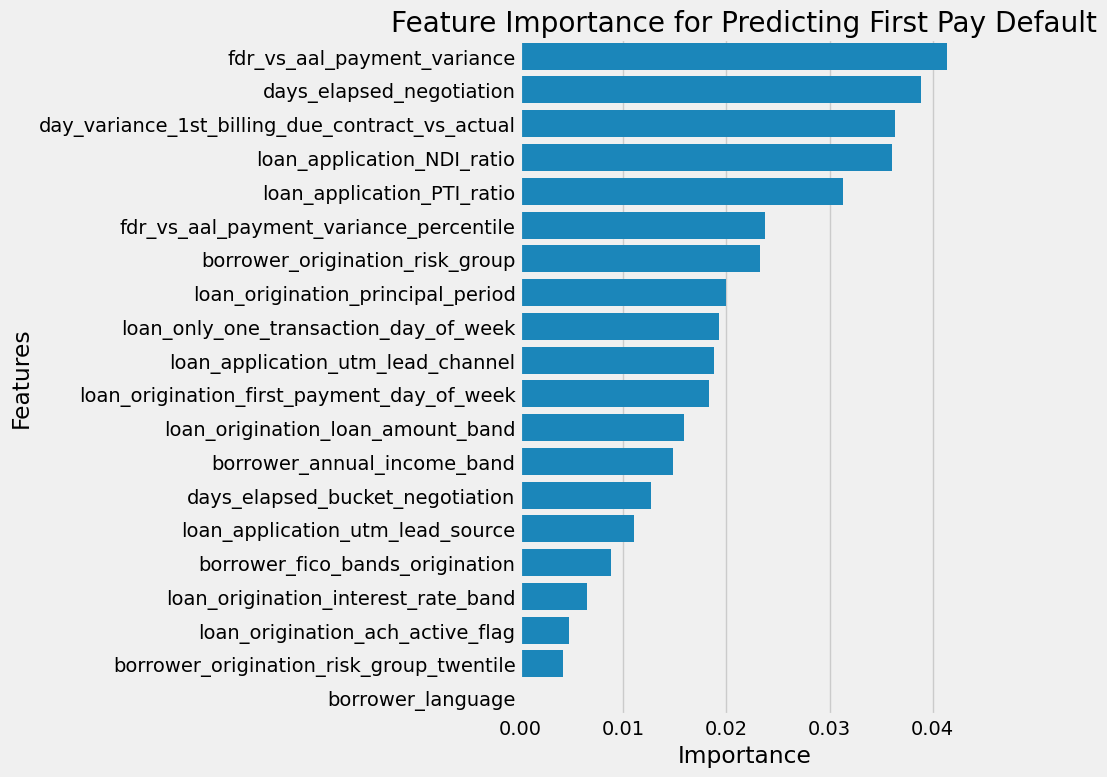

In [48]:
# Data Preprocessing
# Separate target variable
X = df.drop('flag_1st_pay_default', axis=1)
y = df['flag_1st_pay_default']

# Drop columns with all missing values
X.dropna(axis=1, how='all', inplace=True)

# Identify categorical and numerical columns after dropping
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Impute missing values (using mean for numerical and most frequent for categorical)
numerical_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])


# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Drop date and dbdate columns before feature selection
date_cols = X.select_dtypes(include=['datetime64[ns]', 'dbdate']).columns
X = X.drop(columns=date_cols)

# Check for constant columns before feature selection
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
print(f"Constant columns before feature selection: {constant_cols}")

# Check for remaining NaNs before feature selection
print("Number of NaNs per column before feature selection:")
display(X.isnull().sum())

# Define the list of categorical features to explicitly include
categorical_features_to_include = [
    'loan_origination_loan_amount_band'
    , 'loan_origination_interest_rate_band'
    , 'loan_origination_principal_period'
    , 'borrower_language'
    , 'borrower_fico_bands_origination'
    , 'borrower_annual_income_band'
    , 'borrower_origination_risk_group_twentile'
    , 'borrower_origination_state'
    , 'loan_origination_first_payment_day_of_week'
    , 'days_elapsed_bucket_negotiation'
    , 'loan_application_NDI_ratio'
    , 'loan_application_PTI_ratio'
    , 'loan_application_utm_lead_source'
    , 'loan_application_utm_lead_channel'
    , 'loan_origination_interest_rate_band'
    , 'loan_origination_principal_period'
    , 'borrower_language'
    , 'borrower_fico_bands_origination'
    , 'borrower_annual_income_band'
    , 'fdr_vs_aal_payment_variance_percentile'
    , 'fdr_vs_aal_payment_variance'
]


# Feature Selection (SelectKBest)
# Using f_classif for classification tasks
selector = SelectKBest(score_func=f_classif, k=20) # Select top 20 features
X_selected_kbest = selector.fit_transform(X, y)

# Get the names of selected features from SelectKBest
selected_kbest_feature_names = X.columns[selector.get_support(indices=True)]

# Combine SelectKBest features with the specified categorical features
# Ensure no duplicates and that all specified categorical features are included
all_selected_feature_names = list(selected_kbest_feature_names) + categorical_features_to_include
all_selected_feature_names = list(dict.fromkeys(all_selected_feature_names)) # Remove duplicates while preserving order


# Filter X to include only the combined set of selected features
X_selected = X[all_selected_feature_names]


# Model Selection and Training (RandomForestClassifier)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_selected, y)

# Identify Important Features
feature_importances = model.feature_importances_
feature_importances_series = pd.Series(feature_importances, index=X_selected.columns)
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

# Define columns to remove (including those previously specified by the user)
columns_to_remove = [
    'days_elapsed_origination_to_dq_30',
    'loan_investor',
    'loan_prepaid_flag',
    'loan_contributing_investor',
    'loan_no_payment_straight_to_chargeoff_flag',
    'loan_1st_pay_default_return_code',
    'days_elapsed_origination_to_dq',
    'principal_default_percent',
    'count_dpd_1_to_10',
    'count_dpd_cured',
    'count_dpd_30',
    'loan_chargeoff_flag',
    'loan_contractual_chargeoff_flag',
    'loan_in_debt_settlement_flag',
    'flag_dq',
    'flag_never_pay',
    'borrower_origination_state'
]


# Remove specified columns from feature importances
filtered_feature_importances = sorted_feature_importances.drop(columns_to_remove, errors='ignore')


print("Sorted Feature Importances (including specified categorical features and excluding others):")
display(filtered_feature_importances)

# Optional: Visualize filtered feature importances
plt.figure(figsize=(10, 8)) # Increased figure height for more features
sns.barplot(x=filtered_feature_importances.values, y=filtered_feature_importances.index, orient='h')
plt.title('Feature Importance for Predicting First Pay Default')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Visualize numerical feature default proportions
Visualize the contribution of each feature to the target variable `flag_1st_pay_default`.
## Subtask:
Create plots showing the proportion of defaulting customers within bins of the numerical features.

**Reasoning**:
To visualize the proportion of defaults within bins of numerical features, I will:
1. Identify numerical columns (excluding constant ones).
2. Iterate through each numerical column.
3. Create bins for the numerical feature.
4. Calculate the proportion of defaults within each bin.
5. Plot the default proportions against the bin centers or edges.

Initial numerical columns: ['loan_application_NDI_ratio', 'loan_application_PTI_ratio', 'loan_origination_loan_amount', 'loan_origination_interest_rate', 'loan_origination_term_in_months', 'loan_origination_ach_active_flag', 'loan_prepaid_flag', 'loan_chargeoff_flag', 'loan_no_payment_straight_to_chargeoff_flag', 'loan_contractual_chargeoff_flag', 'loan_fraud_flag', 'loan_deceased_flag', 'loan_bk_discharged_flag', 'loan_in_debt_settlement_flag', 'borrower_origination_risk_group', 'borrower_home_owner_flag', 'co_borrower_flag', 'days_elapsed_negotiation', 'day_variance_1st_billing_due_contract_vs_actual', 'count_dpd_cured', 'flag_dq', 'flag_1st_pay_default', 'flag_never_pay', 'principal_default_percent', 'count_dpd_1_to_10', 'count_dpd_30', 'days_elapsed_origination_to_dq', 'days_elapsed_origination_to_dq_30', 'avg_monthly_draft', 'cplus_estimated_monthly_payment_amount', 'monthly_loan_payment_amount', 'fdr_vs_aal_payment_variance', 'fdr_vs_aal_payment_variance_percent_change', 'fdr_vs_

/tmp/ipykernel_503/735445535.py:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[col].fillna(mean_value, inplace=True)


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.00,2064,10.965308,0.010659
1,1,0.09,1748,9.286511,0.00286
2,2,0.15,2108,11.199065,0.005218
3,3,0.20,1916,10.179036,0.005741
4,4,0.24,2051,10.896244,0.005363
5,5,0.28,1500,7.968974,0.004667
6,6,0.31,2045,10.864368,0.006357
7,7,0.36,1890,10.040907,0.009524
8,8,0.42,1656,8.797747,0.006039
9,9,0.50,1845,9.801838,0.007046


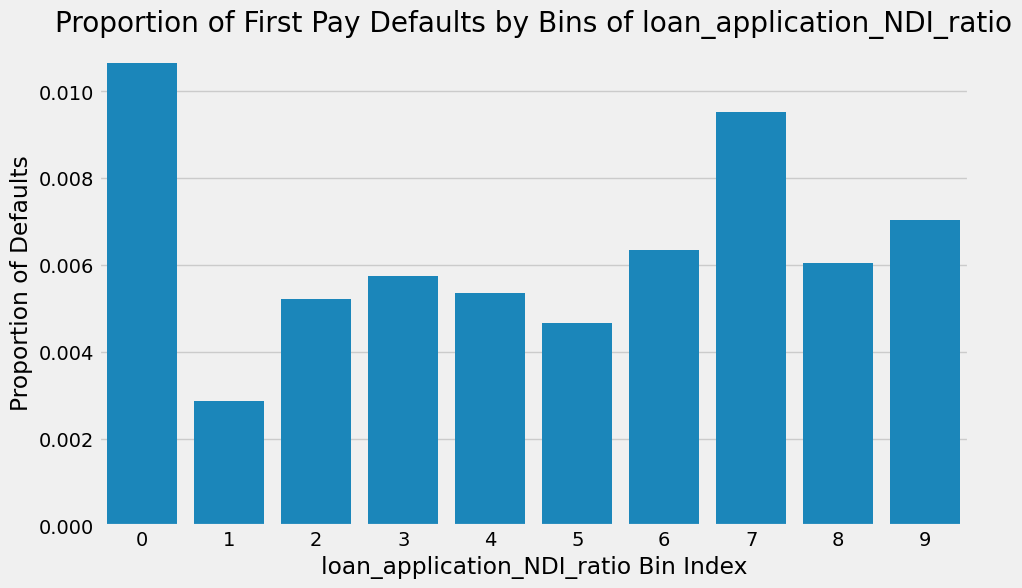

Imputed missing values in 'loan_application_PTI_ratio' with mean (0.10).
Created quantile bins for column 'loan_application_PTI_ratio'.
Bin analysis for loan_application_PTI_ratio:


/tmp/ipykernel_503/735445535.py:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[col].fillna(mean_value, inplace=True)


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.00,2496,13.260373,0.004808
1,1,0.04,1600,8.500239,0.0025
2,2,0.05,1738,9.233385,0.009781
3,3,0.06,1762,9.360888,0.005108
4,4,0.07,3194,16.968602,0.006262
5,5,0.09,1289,6.848005,0.007758
6,6,0.10,1103,5.859852,0.00272
7,7,0.11,2453,13.031929,0.008561
8,8,0.14,1373,7.294268,0.008012
9,9,0.17,1815,9.642459,0.007713


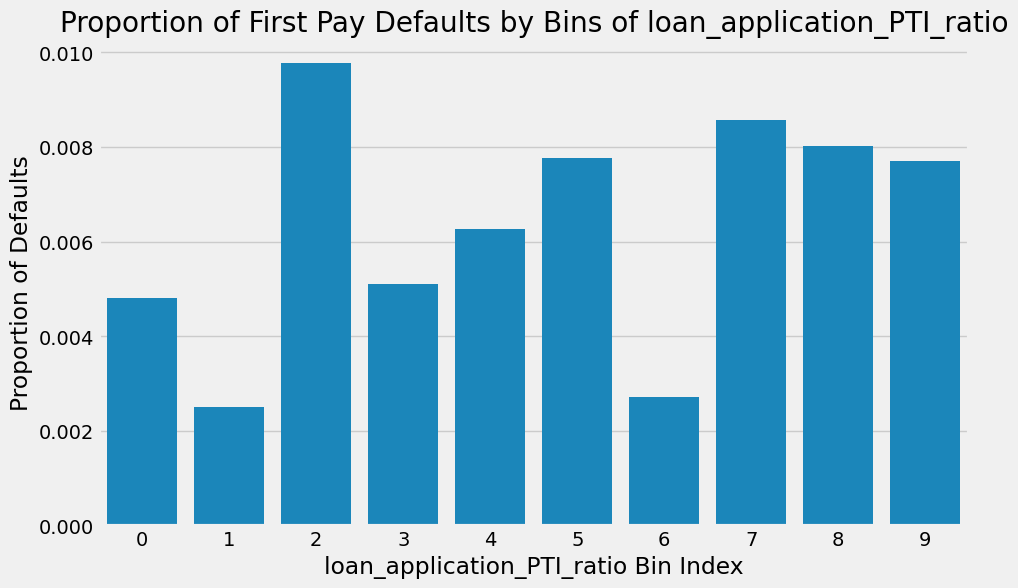

Created quantile bins for column 'loan_origination_loan_amount'.
Bin analysis for loan_origination_loan_amount:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,1596.680,1883,10.003719,0.006904
1,1,6448.730,1882,9.998406,0.009564
2,2,8481.268,1882,9.998406,0.006908
3,3,10266.112,1882,9.998406,0.003188
4,4,12135.216,1883,10.003719,0.006904
5,5,14238.950,1882,9.998406,0.005313
6,6,16709.812,1882,9.998406,0.007439
7,7,19977.192,1882,9.998406,0.006376
8,8,24966.038,1882,9.998406,0.006908
9,9,33684.180,1883,10.003719,0.00478


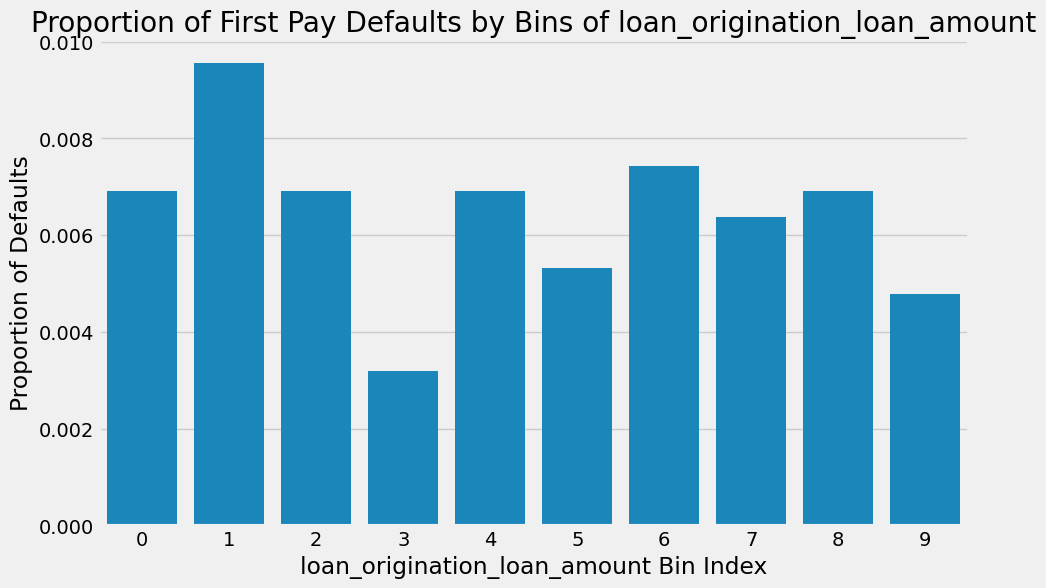

Created quantile bins for column 'loan_origination_interest_rate'.
Bin analysis for loan_origination_interest_rate:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.239,18823,100.0,0.006428


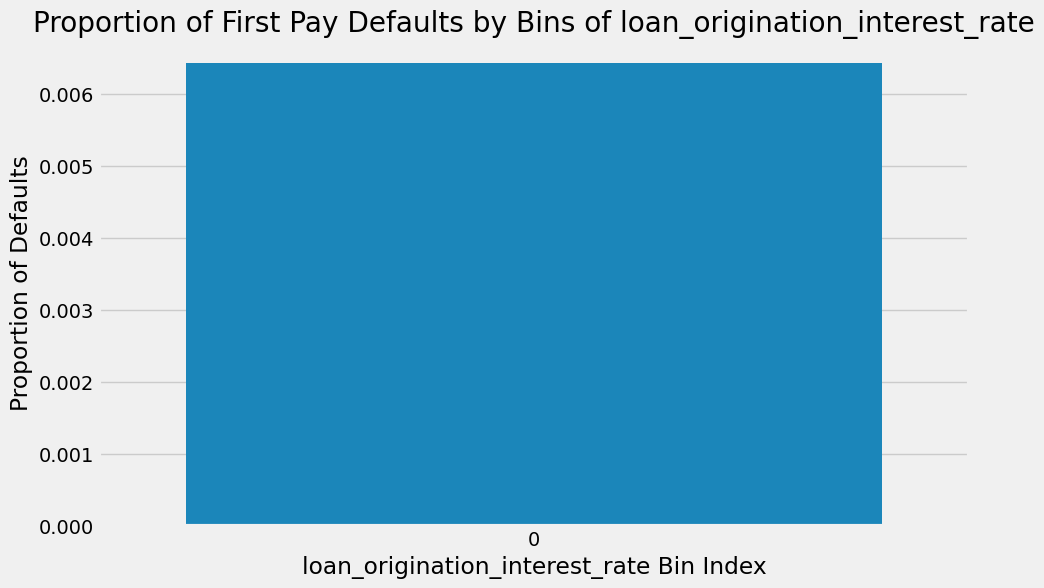

Created quantile bins for column 'loan_origination_term_in_months'.
Bin analysis for loan_origination_term_in_months:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,23.0,2034,10.805929,0.005408
1,1,27.0,1819,9.663709,0.006597
2,2,36.0,2040,10.837805,0.005392
3,3,45.0,1820,9.669022,0.003846
4,4,49.0,2142,11.379695,0.007003
5,5,52.0,1455,7.729905,0.006186
6,6,54.0,3507,18.631462,0.00998
7,7,58.0,671,3.564788,0.007452
8,8,59.0,1621,8.611805,0.003701
9,9,64.0,1714,9.105881,0.005834


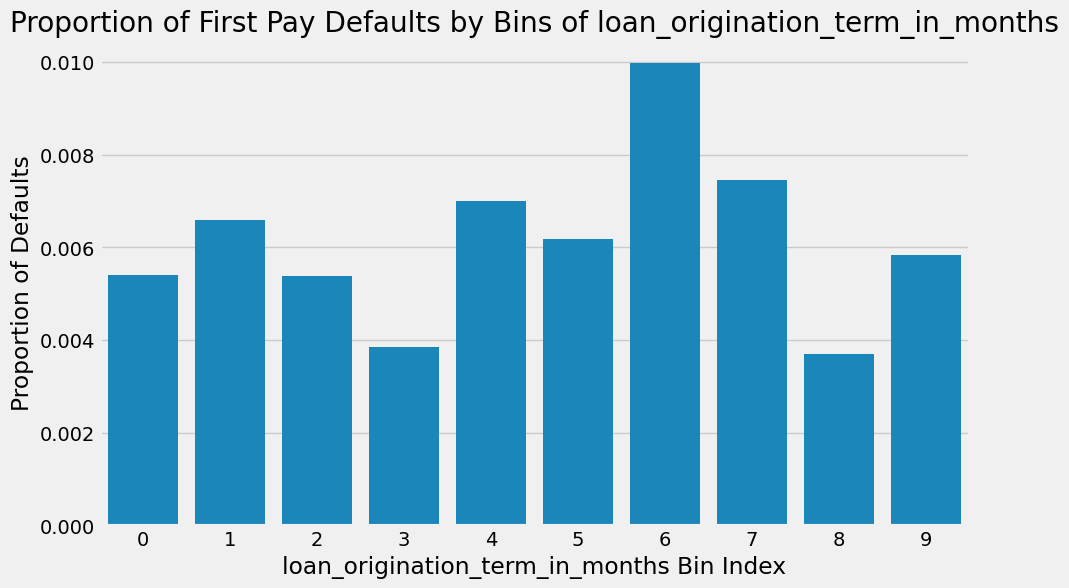

Created quantile bins for column 'loan_origination_ach_active_flag'.
Bin analysis for loan_origination_ach_active_flag:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.0,18823,100.0,0.006428


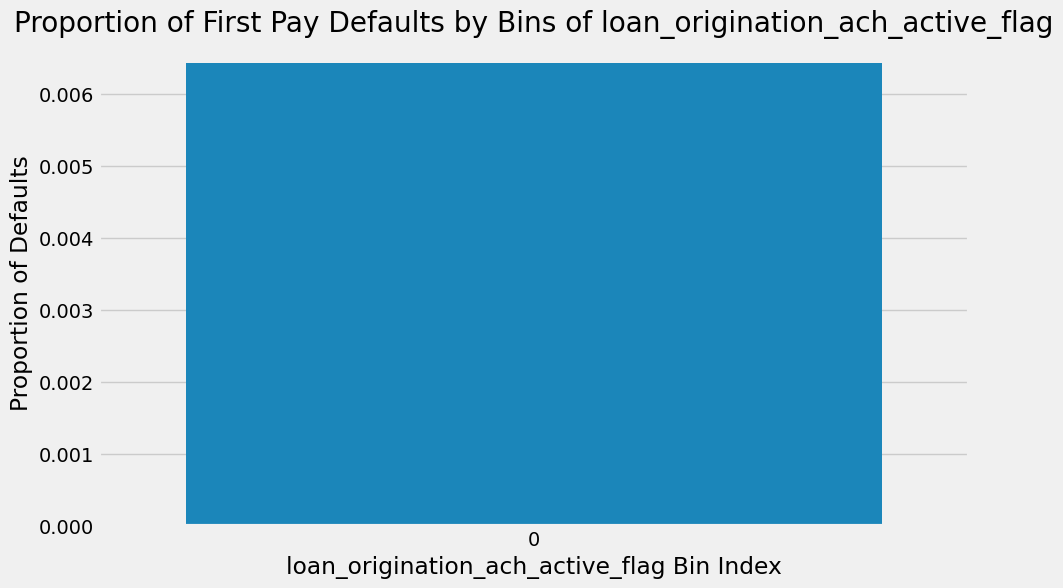

Created quantile bins for column 'borrower_origination_risk_group'.
Bin analysis for borrower_origination_risk_group:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,1.0,5065,26.908569,0.002369
1,1,3.0,1530,8.128354,0.009804
2,2,4.0,1284,6.821442,0.006231
3,3,5.0,2501,13.286936,0.004798
4,4,7.0,1427,7.581151,0.008409
5,5,8.0,2599,13.807576,0.010389
6,6,10.0,1410,7.490836,0.004255
7,7,11.0,2063,10.959996,0.00921
8,8,13.0,944,5.015141,0.010593


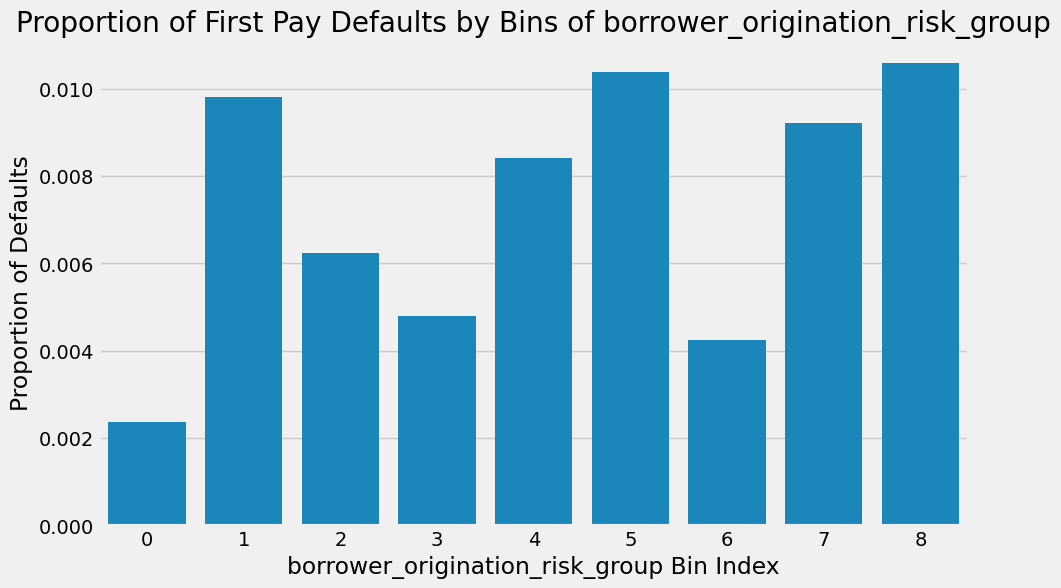

Created quantile bins for column 'borrower_home_owner_flag'.
Bin analysis for borrower_home_owner_flag:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.0,18823,100.0,0.006428


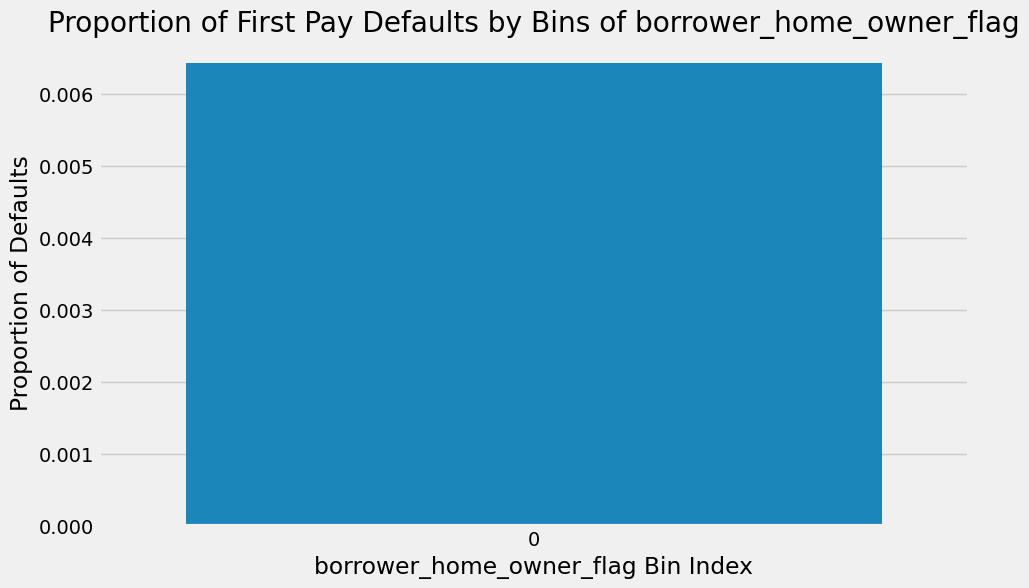

Created quantile bins for column 'co_borrower_flag'.
Bin analysis for co_borrower_flag:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,0.0,18823,100.0,0.006428


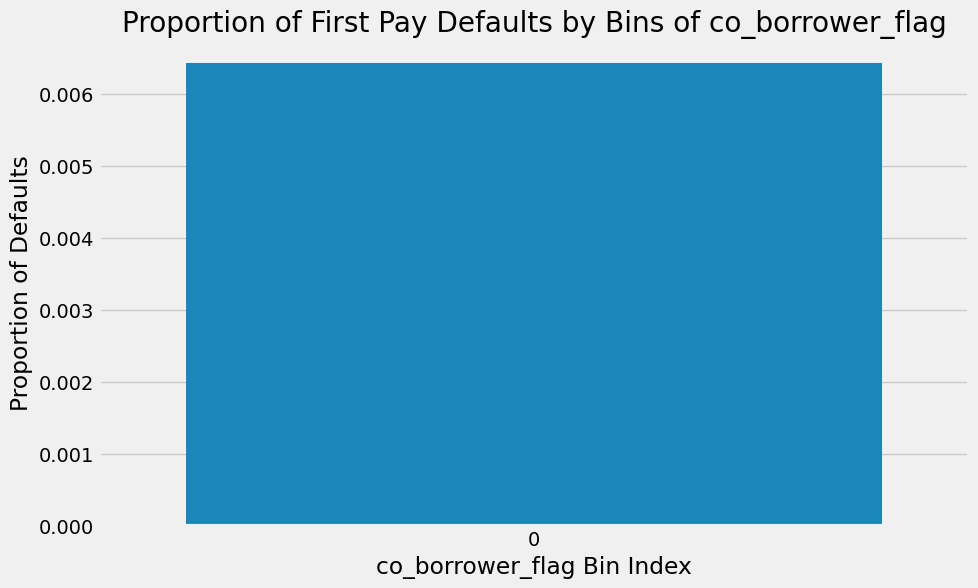

Created quantile bins for column 'days_elapsed_negotiation'.
Bin analysis for days_elapsed_negotiation:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,2.0,2107,11.193752,0.004746
1,1,22.0,1748,9.286511,0.007437
2,2,26.0,1834,9.743399,0.006543
3,3,29.0,2091,11.10875,0.003826
4,4,34.0,1664,8.840249,0.003606
5,5,38.0,2065,10.970621,0.006295
6,6,45.0,1753,9.313074,0.005705
7,7,53.0,1833,9.738086,0.005456
8,8,64.0,1930,10.253413,0.006218
9,9,84.0,1798,9.552144,0.015017


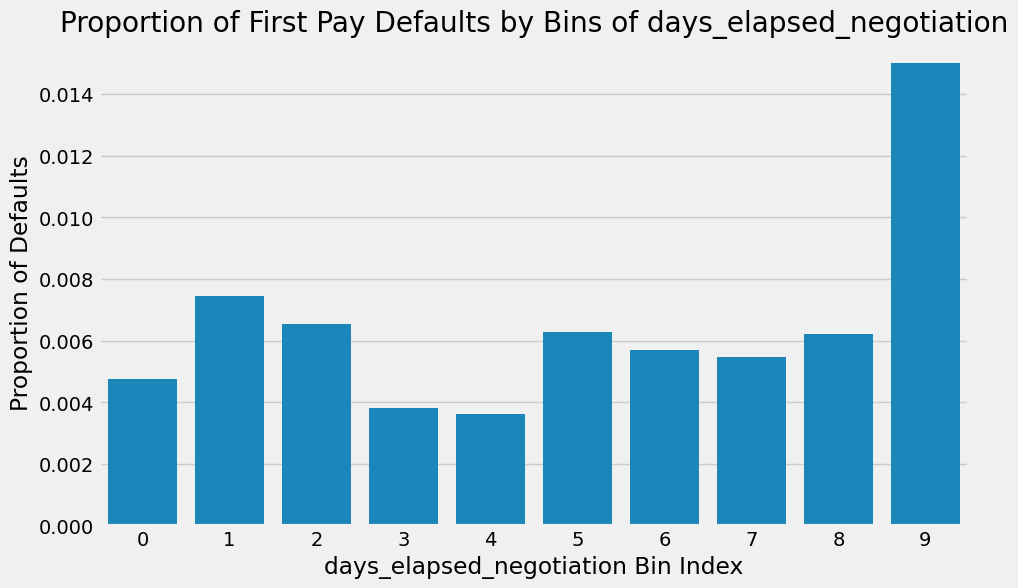

Created quantile bins for column 'day_variance_1st_billing_due_contract_vs_actual'.
Bin analysis for day_variance_1st_billing_due_contract_vs_actual:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-379.0,2359,12.652864,0.011869
1,1,-31.0,2330,12.497318,0.005579
2,2,-14.0,4933,26.458914,0.00446
3,3,0.0,2771,14.86269,0.002165
4,4,14.0,3018,16.187513,0.003976
5,5,28.0,1385,7.428663,0.004332
6,6,30.0,1848,9.912036,0.002706


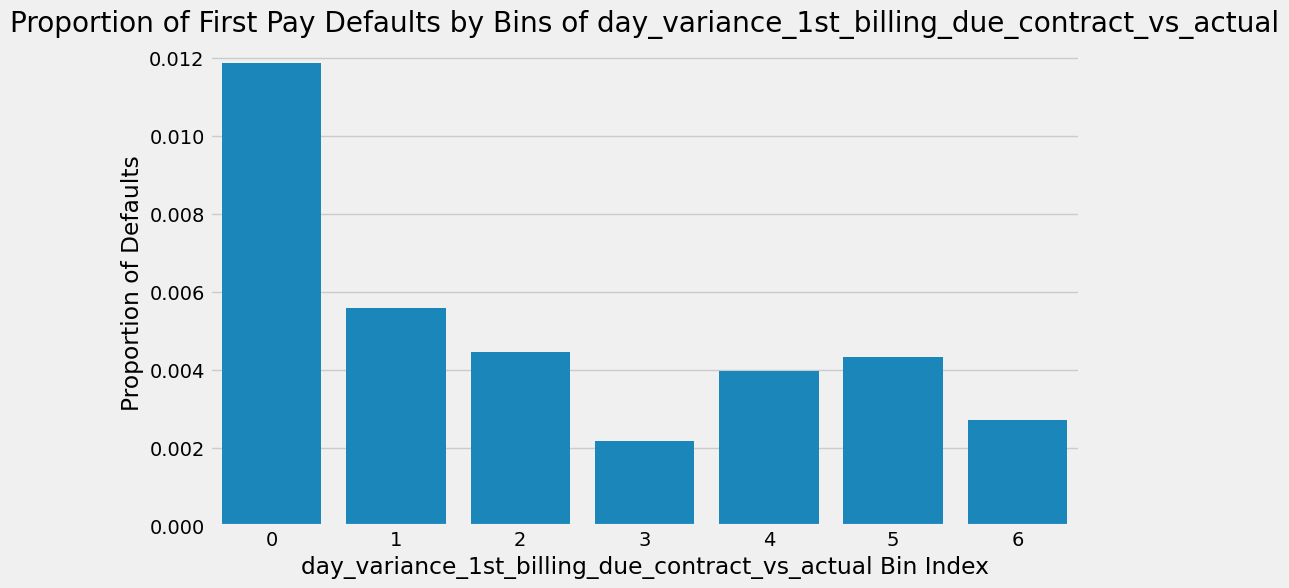

Created quantile bins for column 'avg_monthly_draft'.
Bin analysis for avg_monthly_draft:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,110.000000,1896,10.093697,0.010021
1,1,221.000000,1897,10.09902,0.007907
2,2,270.000000,1849,9.843484,0.008112
3,3,314.166667,1954,10.40247,0.006653
4,4,364.000000,1799,9.5773,0.005559
5,5,418.000000,1902,10.125639,0.005783
6,6,480.000000,1861,9.907368,0.005911
7,7,552.500000,1870,9.955281,0.003743
8,8,672.000000,1877,9.992547,0.00586
9,9,899.121585,1879,10.003194,0.00479


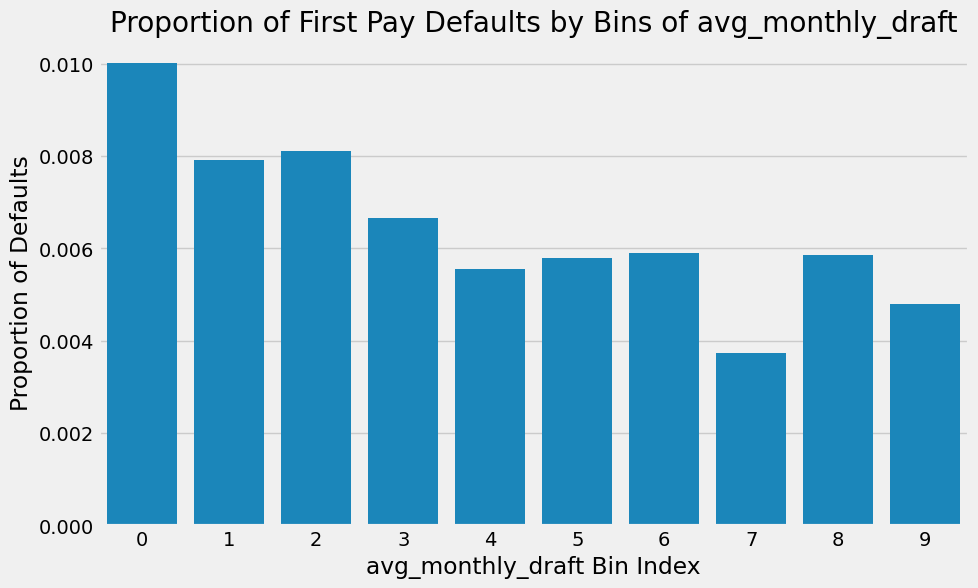

Created quantile bins for column 'cplus_estimated_monthly_payment_amount'.
Bin analysis for cplus_estimated_monthly_payment_amount:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,80.060,1884,10.009032,0.007431
1,1,246.220,1881,9.993094,0.008506
2,2,305.856,1883,10.003719,0.007435
3,3,362.010,1884,10.009032,0.004777
4,4,422.500,1880,9.987781,0.004255
5,5,487.930,1882,9.998406,0.008502
6,6,563.314,1885,10.014344,0.005305
7,7,670.000,1882,9.998406,0.005845
8,8,825.500,1879,9.982468,0.006386
9,9,1100.136,1883,10.003719,0.005842


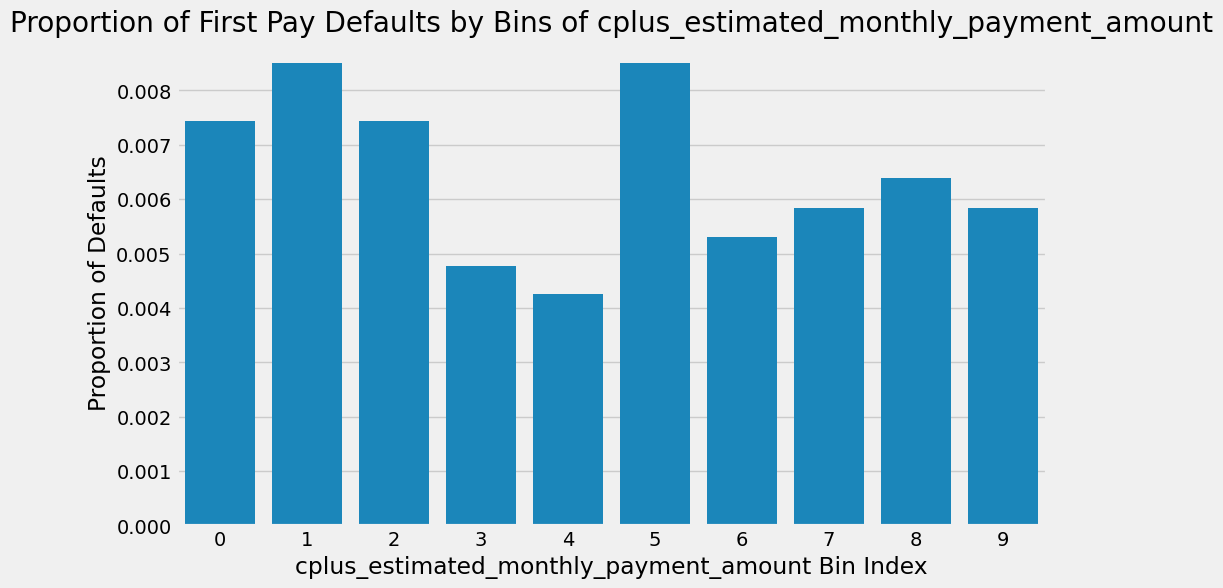

Created quantile bins for column 'monthly_loan_payment_amount'.
Bin analysis for monthly_loan_payment_amount:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,45.570754,1883,10.003719,0.008497
1,1,235.063696,1882,9.998406,0.008502
2,2,296.168000,1883,10.003719,0.004249
3,3,351.720000,1882,9.998406,0.00797
4,4,410.000000,1883,10.003719,0.004249
5,5,475.740000,1881,9.993094,0.007443
6,6,552.484000,1882,9.998406,0.006376
7,7,658.556000,1882,9.998406,0.004782
8,8,810.104000,1891,10.04622,0.007403
9,9,1083.330000,1874,9.955905,0.004803


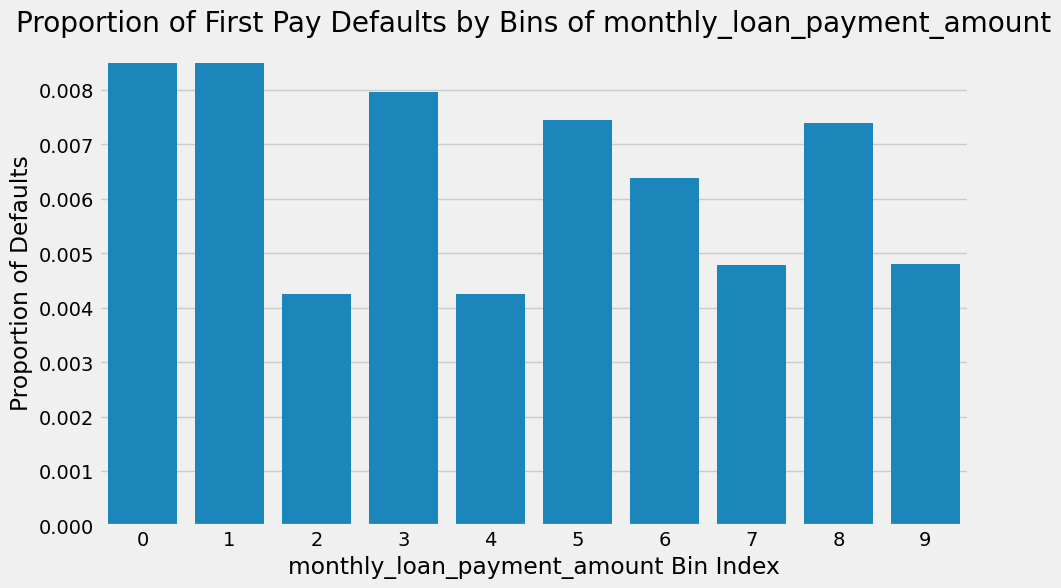

Created quantile bins for column 'fdr_vs_aal_payment_variance'.
Bin analysis for fdr_vs_aal_payment_variance:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-3073.220,1883,10.003719,0.002124
1,1,-61.958,3110,16.52234,0.005788
2,2,0.000,656,3.485098,0.007622
3,3,9.160,1881,9.993094,0.004785
4,4,43.140,1882,9.998406,0.011158
5,5,74.790,1883,10.003719,0.007435
6,6,106.000,1881,9.993094,0.005316
7,7,146.542,1882,9.998406,0.007439
8,8,204.884,1882,9.998406,0.009564
9,9,312.796,1883,10.003719,0.004249


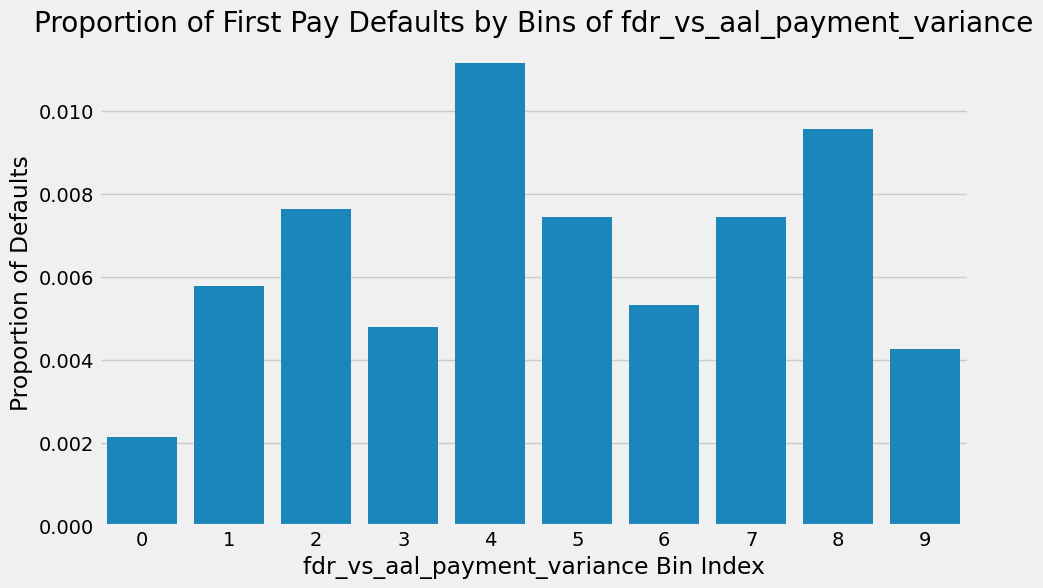

Created quantile bins for column 'fdr_vs_aal_payment_variance_percent_change'.
Bin analysis for fdr_vs_aal_payment_variance_percent_change:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-0.875408,1879,10.003194,0.003193
1,1,-0.142919,3075,16.370315,0.005203
2,2,0.000000,681,3.625426,0.007342
3,3,0.017003,1882,10.019165,0.004782
4,4,0.119403,1875,9.981899,0.008533
5,5,0.212144,1878,9.997871,0.006922
6,6,0.292871,1879,10.003194,0.007451
7,7,0.371547,1878,9.997871,0.007987
8,8,0.459534,1878,9.997871,0.007987
9,9,0.591998,1879,10.003194,0.006386


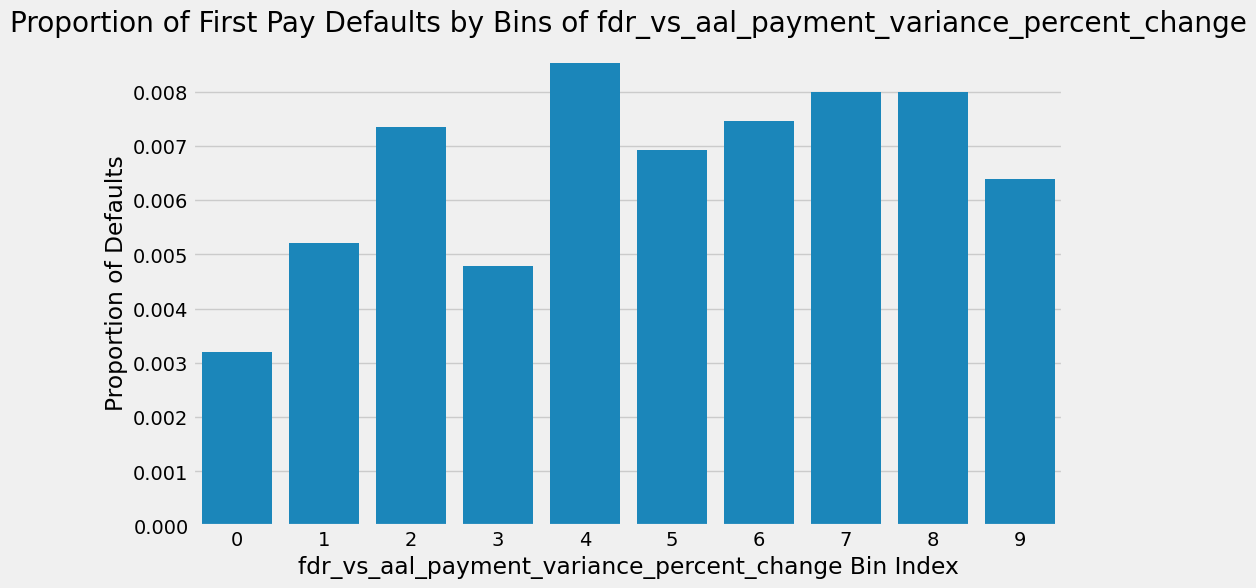

Created quantile bins for column 'fdr_vs_aal_payment_variance_percentile'.
Bin analysis for fdr_vs_aal_payment_variance_percentile:


,Bin Index,Bin Edge,Loan Count,Percentage of Total,Default Proportion
0,0,-8.0,2174,11.57368,0.00368
1,1,-1.0,4964,26.426746,0.005439
2,2,0.0,1993,10.610094,0.007025
3,3,1.0,2289,12.185903,0.007427
4,4,2.0,2389,12.718271,0.007953
5,5,3.0,1926,10.253407,0.00675
6,6,4.0,1267,6.745102,0.008682
7,7,5.0,1782,9.486797,0.006734


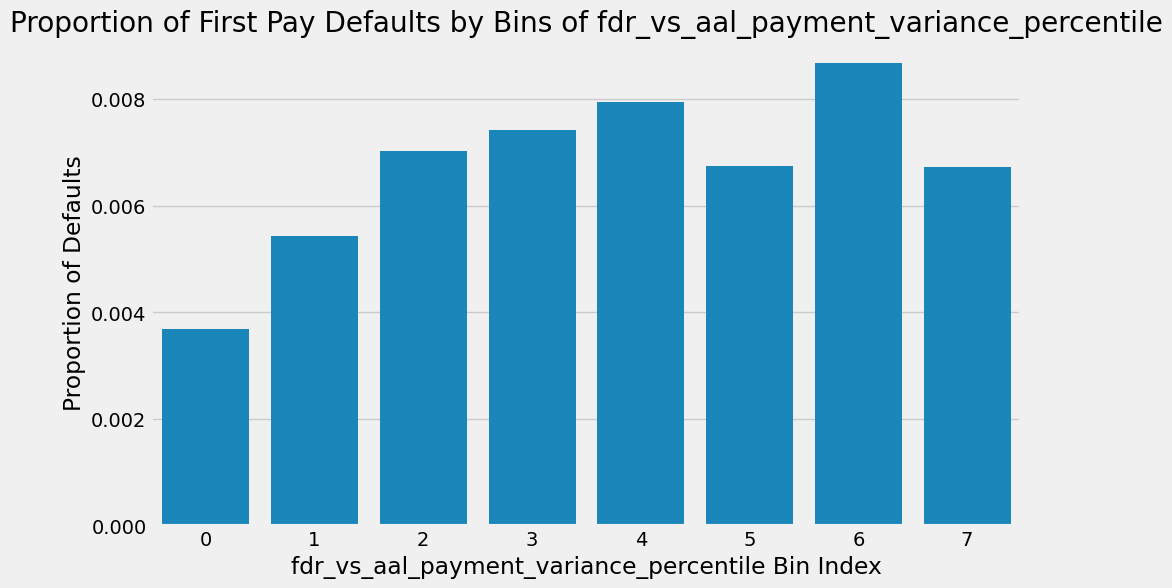

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' and 'flag_1st_pay_default' are already loaded and available

# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
print(f"Initial numerical columns: {list(numerical_cols)}")

# Identify constant numerical columns using a for loop for robustness
constant_numerical_cols = []
for col in numerical_cols:
    try:
        # Exclude the target variable from the nunique check if it's numeric
        if col != 'flag_1st_pay_default' and df[col].nunique() == 1:
            constant_numerical_cols.append(col)
        # Handle the case where the target variable might be in numerical_cols
        elif col == 'flag_1st_pay_default':
             continue
    except Exception as e:
        print(f"Could not determine nunique for column '{col}': {e}")
print(f"Constant numerical columns: {constant_numerical_cols}")


# Define columns to exclude from plotting (keeping previous exclusions and ensuring no overlap)
columns_to_exclude_plotting = [
    'days_elapsed_origination_to_dq_30',
    'loan_investor', # Although listed, this is likely categorical. Will handle based on dtype.
    'loan_prepaid_flag',
    'loan_contributing_investor', # Although listed, this is likely categorical. Will handle based on dtype.
    'loan_no_payment_straight_to_chargeoff_flag',
    'loan_1st_pay_default_return_code', # Although listed, this is likely categorical. Will handle based on dtype.
    'days_elapsed_origination_to_dq',
    'principal_default_percent',
    'count_dpd_1_to_10',
    'count_dpd_cured',
    'count_dpd_30',
    'loan_chargeoff_flag',
    'loan_contractual_chargeoff_flag',
    'loan_in_debt_settlement_flag',
    'flag_dq',
    'flag_never_pay',
    'loan_bk_discharged_flag',
    'loan_deceased_flag'
]
print(f"Columns to exclude from plotting: {columns_to_exclude_plotting}")


# Filter out constant numerical columns, the target variable, and specified excluded columns
plottable_numerical_cols = [
    col for col in numerical_cols
    if col not in constant_numerical_cols and
       col != 'flag_1st_pay_default' and
       col not in columns_to_exclude_plotting
]
print(f"Plottable numerical columns after filtering: {plottable_numerical_cols}")


# Columns to impute with mean
columns_to_impute_mean = ['loan_application_NDI_ratio', 'loan_application_PTI_ratio']

print(f"Attempting to plot default proportions for {len(plottable_numerical_cols)} numerical columns.")

# Iterate through plottable numerical columns and create plots of default proportions
for col in plottable_numerical_cols:
    try:
        # Use the full df with the new cluster_label column
        temp_df = df[[col, 'flag_1st_pay_default']].copy() # Create a temporary df with only the relevant columns

        # Impute missing values for specified columns with their mean
        if col in columns_to_impute_mean:
            mean_value = temp_df[col].mean()
            if pd.isna(mean_value):
                print(f"Skipping plotting for column '{col}' because it contains only null values.")
                plt.close() # Ensure figure is closed
                continue
            temp_df[col].fillna(mean_value, inplace=True)
            print(f"Imputed missing values in '{col}' with mean ({mean_value:.2f}).")

        # Remove rows where the numerical column is NaN after imputation (only if still NaNs exist)
        temp_df.dropna(subset=[col, 'flag_1st_pay_default'], inplace=True)


        if temp_df.empty:
            print(f"Skipping plotting for column '{col}' due to no non-null data for plotting after imputation.")
            continue

        # Create bins for the numerical feature
        # Using qcut for quantiles to handle skewed data, fall back to cut if too many identical values
        try:
            # Attempt to create quantile bins and capture the bins information
            bins, intervals = pd.qcut(temp_df[col], q=10, labels=False, duplicates='drop', retbins=True)
            temp_df['bin'] = bins
            print(f"Created quantile bins for column '{col}'.")

        except ValueError as ve:
            print(f"Could not create quantile bins for '{col}' ({ve}), falling back to equal-width bins.")
            try:
                # Fall back to equal-width bins and capture the bins information
                bins, intervals = pd.cut(temp_df[col], bins=10, labels=False, include_lowest=True, retbins=True)
                temp_df['bin'] = bins
                if temp_df['bin'].isnull().all():
                     print(f"Skipping plotting for column '{col}' as equal-width binning resulted in all NaNs.")
                     continue
                print(f"Created equal-width bins for column '{col}'.")

            except Exception as cut_e:
                print(f"Skipping plotting for column '{col}' due to error during binning: {cut_e}")
                continue

        # Calculate the proportion of defaults and count of loans within each bin
        bin_analysis = temp_df.groupby('bin')['flag_1st_pay_default'].agg(['count', 'mean']).reset_index()
        bin_analysis = bin_analysis.rename(columns={'count': 'loan_count', 'mean': 'default_proportion'})

        # Calculate the percentage of total population for each bin
        total_loans_in_col = bin_analysis['loan_count'].sum()
        bin_analysis['percentage_of_total'] = (bin_analysis['loan_count'] / total_loans_in_col) * 100

        if bin_analysis.empty:
             print(f"Skipping plotting for column '{col}' as no bin analysis could be calculated after binning.")
             continue

        # Display bin information including edges, count, and percentage
        bin_info = pd.DataFrame({'Bin Index': bin_analysis['bin'],
                                 'Bin Edge': intervals[:-1] if len(intervals) == len(bin_analysis) + 1 else None, # Attempt to align edges
                                 'Loan Count': bin_analysis['loan_count'],
                                 'Percentage of Total': bin_analysis['percentage_of_total'],
                                 'Default Proportion': bin_analysis['default_proportion']
                                })
        print(f"Bin analysis for {col}:")
        display(bin_info)


        # Create a bar plot of default proportions
        plt.figure(figsize=(10, 6))
        sns.barplot(x=bin_analysis['bin'], y=bin_analysis['default_proportion'])
        plt.title(f'Proportion of First Pay Defaults by Bins of {col}')
        plt.xlabel(f'{col} Bin Index') # Using bin index as labels for now
        plt.ylabel('Proportion of Defaults')
        plt.show()
        plt.close()

    except Exception as e:
        print(f"Skipping plotting for column '{col}' due to error: {e}")
        plt.close()

In [50]:
# Define the column to bin
column_to_bin = 'days_elapsed_negotiation'

# --- 2. Corrected Crosstab with Bin Limits ---
if f'{column_to_bin}_Decile_Label' in df.columns:

    print("\n## 📋 Crosstab of Decile Counts and Limits ##")

    # Calculate the count of loans in each descriptive decile bin
    decile_crosstab = df[f'{column_to_bin}_Decile_Label'].value_counts().sort_index().to_frame('Loan Count')

    # === FIX APPLIED HERE ===
    # Explicitly convert the CategoricalIndex back to an IntervalIndex
    # so we can access the .left and .right attributes.
    decile_crosstab.index = decile_crosstab.index.astype('interval')

    # Calculate the percentage of total loans
    total_loans = decile_crosstab['Loan Count'].sum()
    decile_crosstab['Percentage'] = (decile_crosstab['Loan Count'] / total_loans) * 100

    # Extract the lower and upper limit from the now-correct Interval Index
    decile_crosstab['Lower Limit'] = decile_crosstab.index.left
    decile_crosstab['Upper Limit'] = decile_crosstab.index.right

    # Reorder columns for clarity
    decile_crosstab = decile_crosstab[['Lower Limit', 'Upper Limit', 'Loan Count', 'Percentage']]

    display(decile_crosstab)

##Days Elapsed Negotiation Historgram

Decile Binning and Crosstab created for 'days_elapsed_negotiation'.

## 📈 Bar Plot: Loan Count Frequency by Decile Bin ##


/tmp/ipykernel_503/2871449064.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


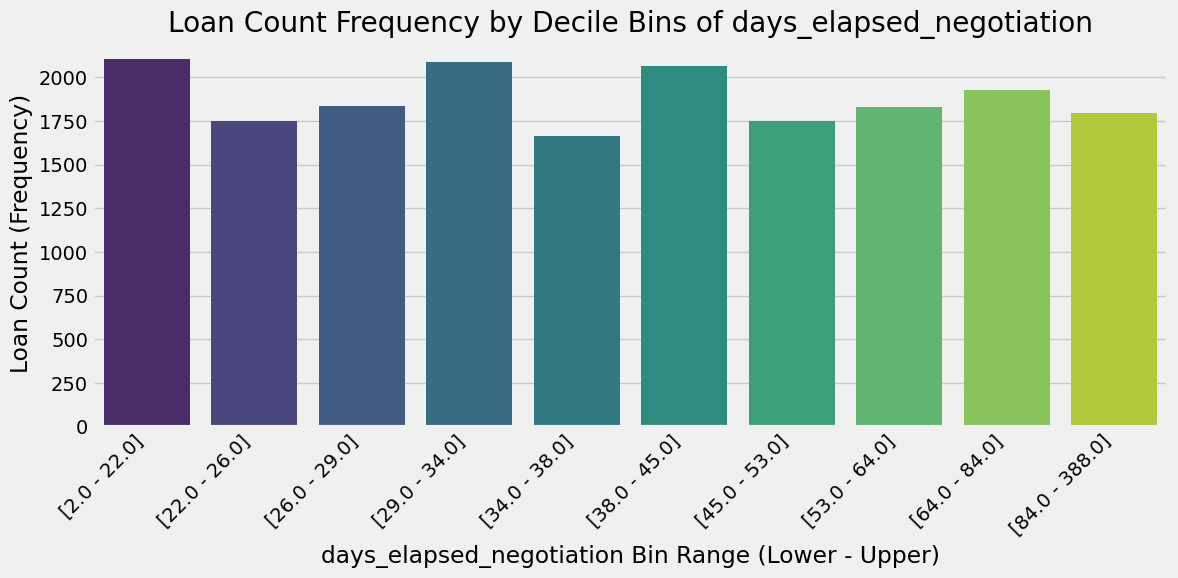

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' is your loaded DataFrame
column_to_bin = 'days_elapsed_negotiation'
decile_label_col = f'{column_to_bin}_Decile_Label'

# --- 1. Recreate Labeled Decile Bins and Crosstab (Necessary Setup) ---

temp_df = df.dropna(subset=[column_to_bin]).copy()

# A. Create the bins and intervals
try:
    decile_cut, intervals = pd.qcut(
        temp_df[column_to_bin],
        q=10,
        labels=False,
        duplicates='drop',
        retbins=True
    )
    # B. Create the descriptive labels
    decile_labels = pd.cut(
        temp_df[column_to_bin],
        bins=intervals,
        include_lowest=True,
        duplicates='drop',
        right=True
    )
    df[decile_label_col] = decile_labels

    # C. Create the Crosstab with Loan Counts
    decile_crosstab = df[decile_label_col].value_counts().sort_index().to_frame('Loan Count')

    # FIX: Convert the index back to IntervalIndex to extract limits
    decile_crosstab.index = decile_crosstab.index.astype('interval')

    # D. Prepare labels for the X-axis
    # Create descriptive labels like "[Lower - Upper]"
    decile_crosstab['Bin Label'] = (
        '[' + decile_crosstab.index.left.round(2).astype(str) +
        ' - ' +
        decile_crosstab.index.right.round(2).astype(str) +
        ']'
    )

    print(f"Decile Binning and Crosstab created for '{column_to_bin}'.")

except Exception as e:
    print(f"Skipping visualization due to error in binning: {e}")
    # Handle the error gracefully if binning fails
    exit() # Exit the block if setup fails


# --- 2. Bar Plot for Loan Count Frequency ---

print(f"\n## 📈 Bar Plot: Loan Count Frequency by Decile Bin ##")

plt.figure(figsize=(12, 6))

# Use the 'Bin Label' for the x-axis and 'Loan Count' for the y-axis
sns.barplot(
    x='Bin Label',
    y='Loan Count',
    data=decile_crosstab,
    palette="viridis"
)

plt.title(f'Loan Count Frequency by Decile Bins of {column_to_bin}')
plt.xlabel(f'{column_to_bin} Bin Range (Lower - Upper)')
plt.ylabel('Loan Count (Frequency)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()


## 🗓️ Processing Segment: loan_vintage_month = 2026-01-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-01-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


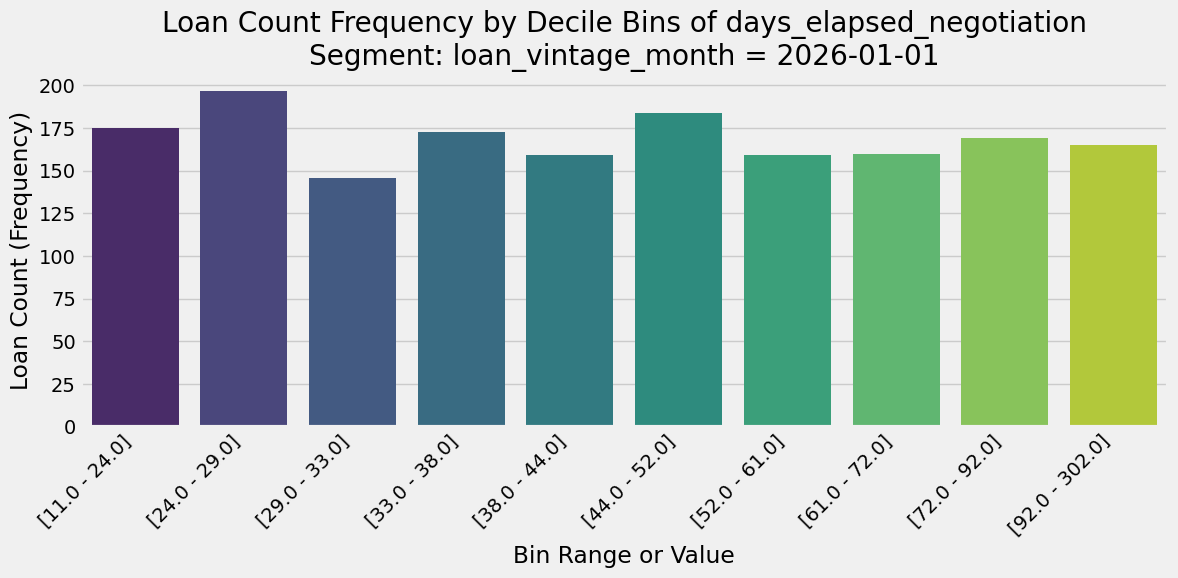


## 🗓️ Processing Segment: loan_vintage_month = 2026-02-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-02-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


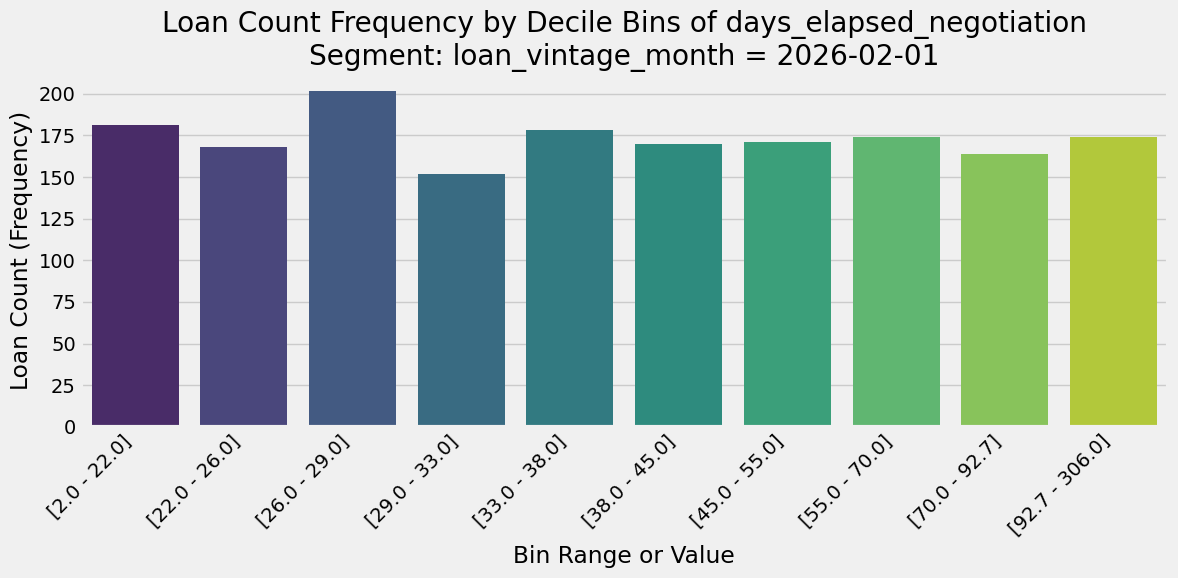


## 🗓️ Processing Segment: loan_vintage_month = 2026-03-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-03-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


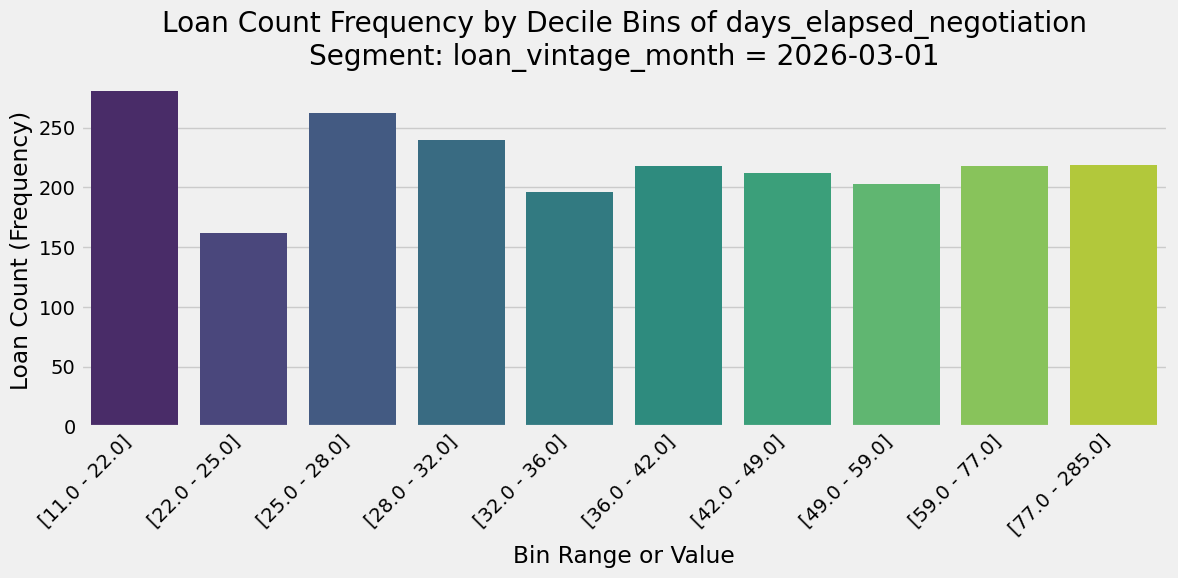


## 🗓️ Processing Segment: loan_vintage_month = 2026-04-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-04-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


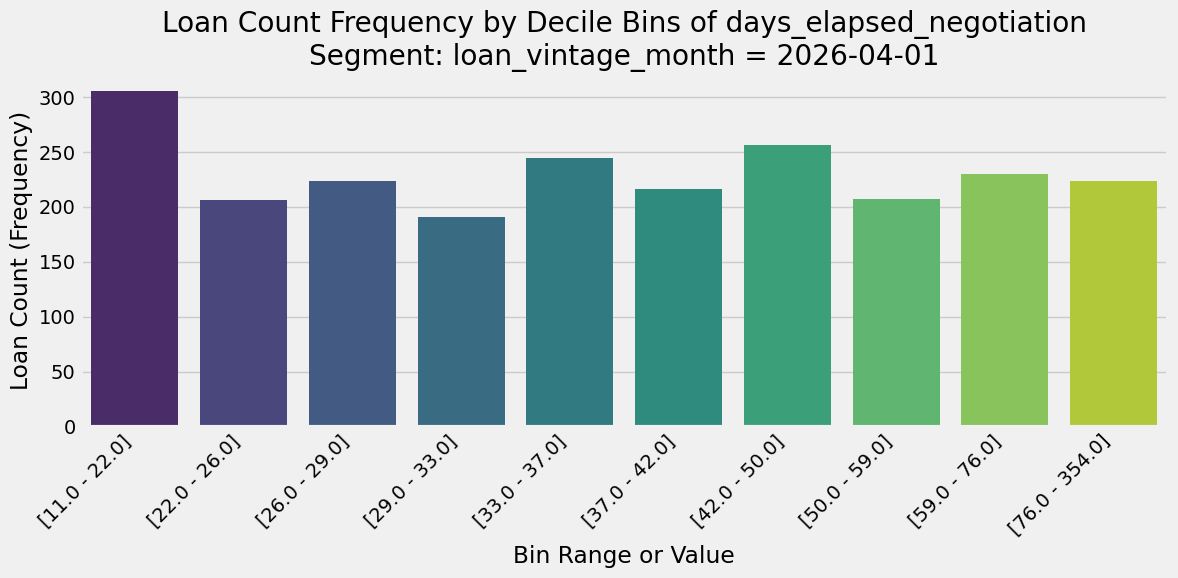


## 🗓️ Processing Segment: loan_vintage_month = 2026-05-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-05-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


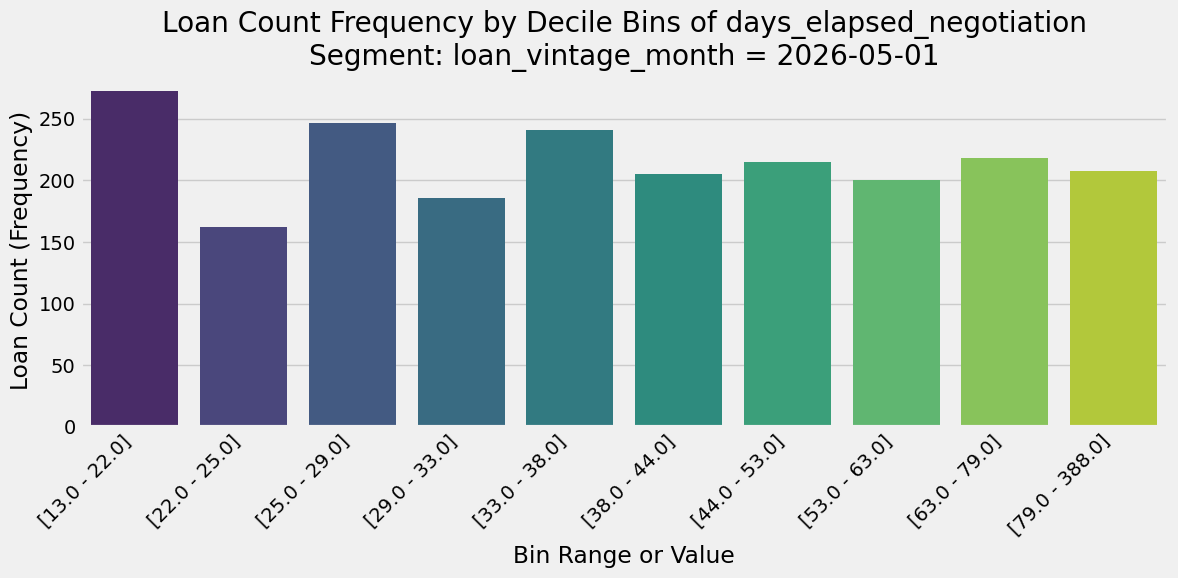


## 🗓️ Processing Segment: loan_vintage_month = 2026-06-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-06-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


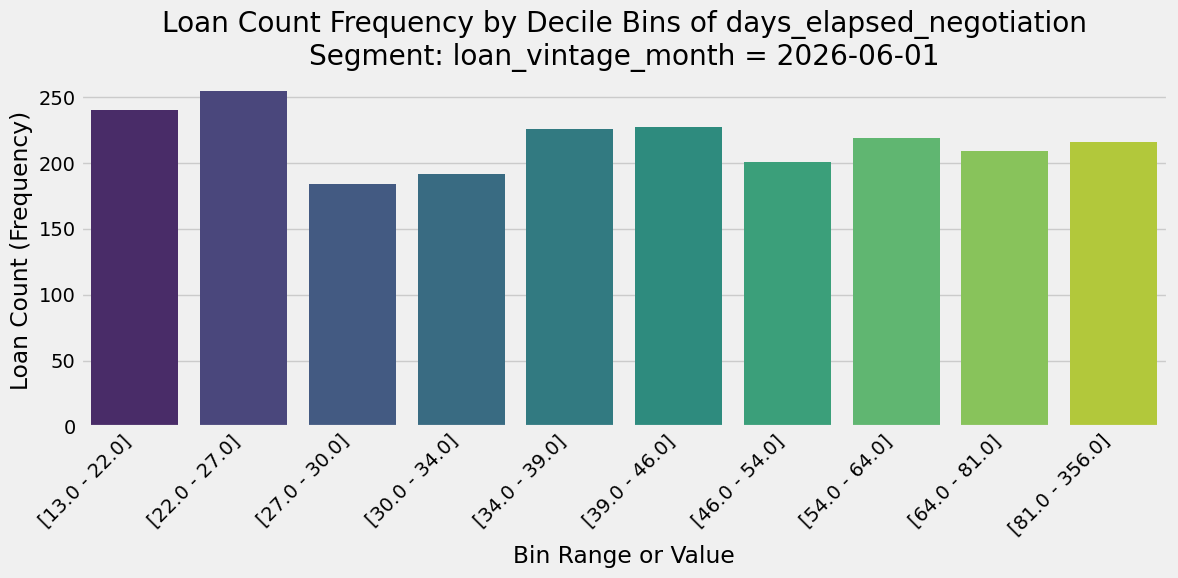


## 🗓️ Processing Segment: loan_vintage_month = 2026-07-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-07-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


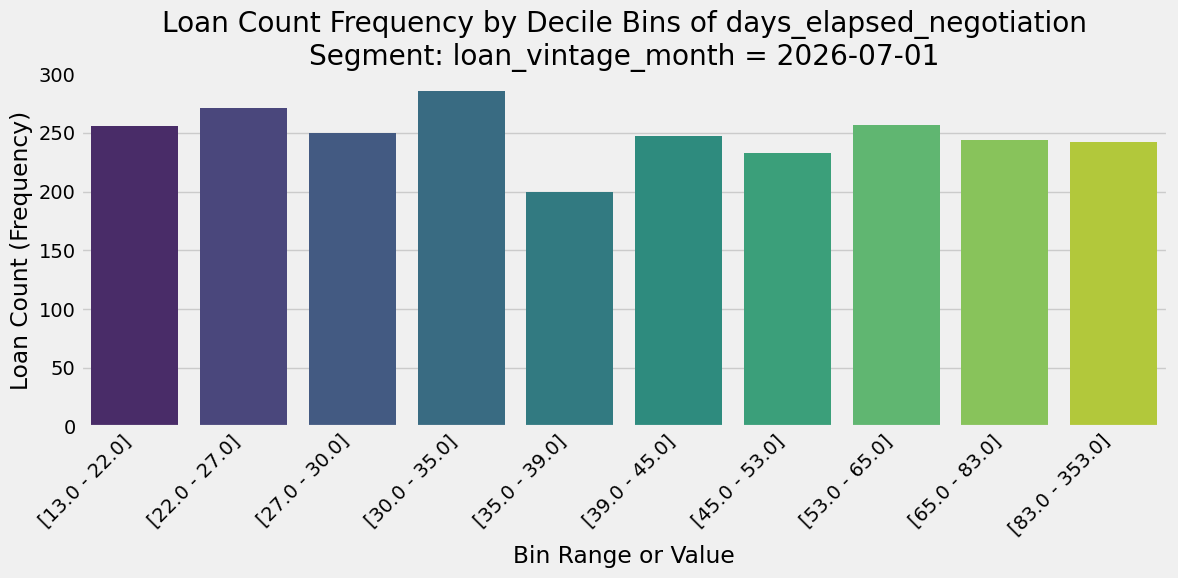


## 🗓️ Processing Segment: loan_vintage_month = 2026-08-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-08-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


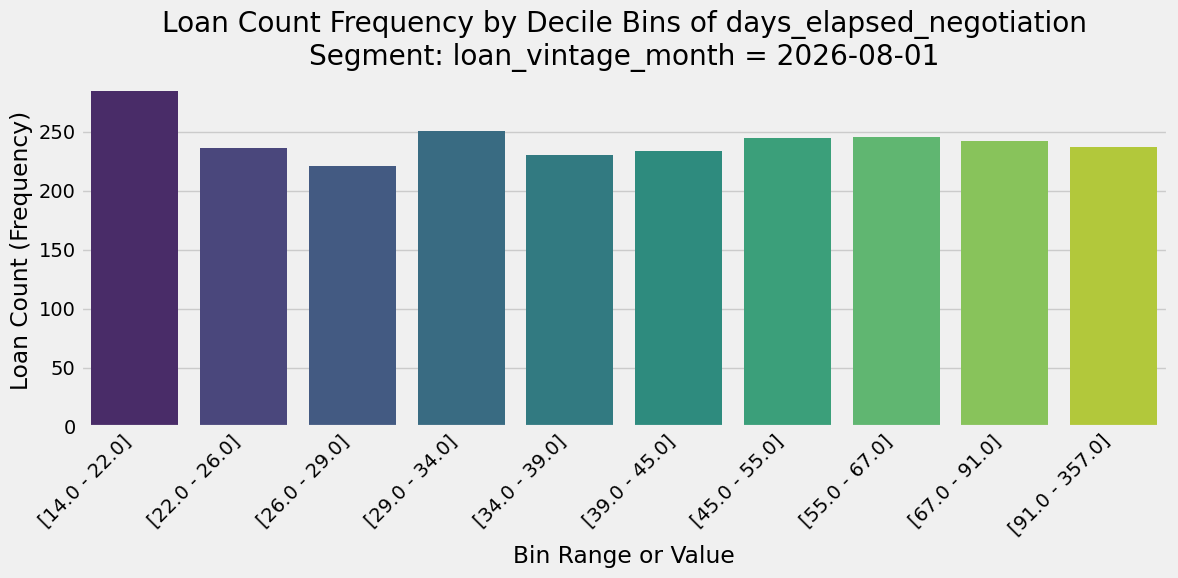


## 🗓️ Processing Segment: loan_vintage_month = 2026-09-01 ##
Decile Binning and Crosstab created for 'days_elapsed_negotiation' in segment 2026-09-01.


/tmp/ipykernel_503/1235547206.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


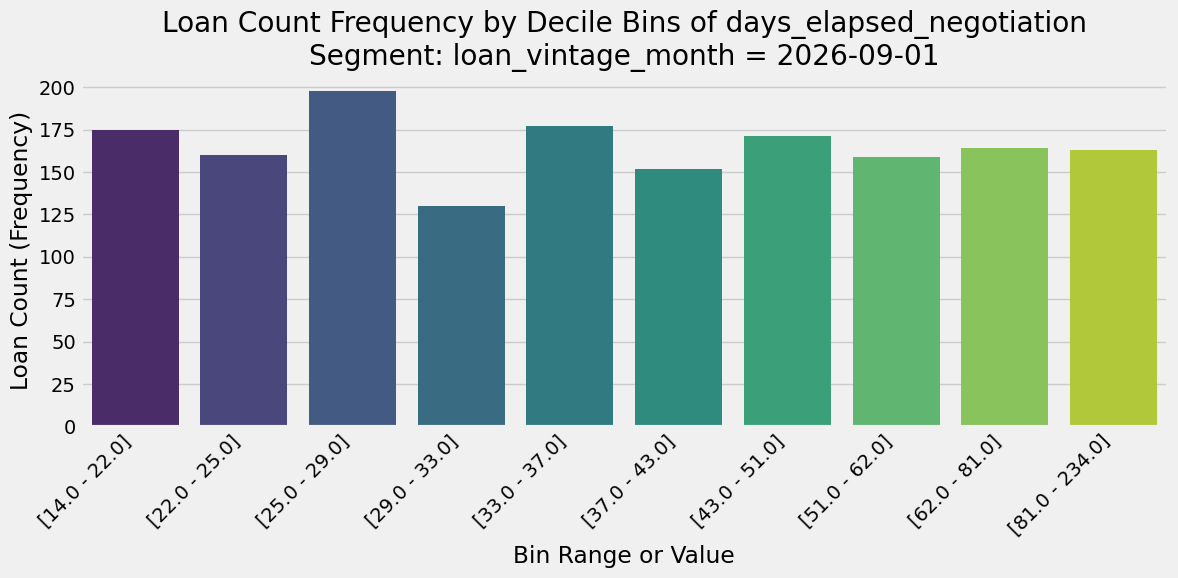

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' is your loaded DataFrame
column_to_bin = 'days_elapsed_negotiation'
segment_col = 'loan_vintage_month'

# --- 0. Prepare the segmentation column and unique values ---
if segment_col not in df.columns:
    print(f"Error: '{segment_col}' column not found in the DataFrame.")
    exit()

# Get and sort unique vintage months. Use np.sort() for robustness with datetime types.
vintage_months = df[segment_col].unique()
vintage_months = np.sort(vintage_months)

# --- Loop through each vintage month to create segmented visualizations ---
for vintage_month in vintage_months:
    print(f"\n=======================================================")
    print(f"## 🗓️ Processing Segment: {segment_col} = {vintage_month} ##")
    print(f"=======================================================")

    # 1. Filter the data for the current segment
    segment_df = df[df[segment_col] == vintage_month].copy()

    # Get the non-null data for the target column
    temp_data = segment_df.dropna(subset=[column_to_bin])[column_to_bin]

    # Check for minimum data points
    if temp_data.shape[0] < 10:
        print(f"Skipping visualization for {vintage_month}: Not enough non-null data points ({temp_data.shape[0]}) to create 10 deciles.")
        continue

    # --- 1. Decile Binning and Crosstab (PER SEGMENT) ---

    try:
        # A. Use pd.qcut to determine the bin edges (intervals)
        _, intervals = pd.qcut(
            temp_data,
            q=10,
            labels=False,
            duplicates='drop',
            retbins=True
        )

        # B. Use pd.cut with the determined intervals to create the IntervalIndex labels
        decile_labels = pd.cut(
            temp_data,
            bins=intervals,
            include_lowest=True,
            duplicates='drop',
            right=True
        )

        # C. Create the Crosstab with Loan Counts
        decile_crosstab = decile_labels.value_counts().sort_index().to_frame('Loan Count')

        # --- FIX: Explicitly convert the CategoricalIndex to IntervalIndex ---
        # This addresses the 'CategoricalIndex' object has no attribute 'left' error.
        if isinstance(decile_crosstab.index, pd.CategoricalIndex):
            decile_crosstab.index = decile_crosstab.index.astype('interval')


        # --- Check for Single Bin (Non-IntervalIndex) ---
        # Now this check should be for IntervalIndex, which covers all valid multi-bin cases.
        if not isinstance(decile_crosstab.index, pd.IntervalIndex):
            # Handle the true single-bin case (or remaining rare edge cases)
            if len(decile_crosstab) == 1:
                total_count = decile_crosstab['Loan Count'].iloc[0]
                unique_value = temp_data.iloc[0]

                decile_crosstab = pd.DataFrame({
                    'Bin Label': [f'All Values = {unique_value.round(2)}'],
                    'Loan Count': [total_count]
                })
                print(f"Plotting {vintage_month} as a single bin (value={unique_value.round(2)}).")
            else:
                print(f"Skipping visualization for {vintage_month}: Binning resulted in an unexpected Index type after conversion.")
                continue

        else:
            # D. Prepare labels for the X-axis (Standard Decile case)
            decile_crosstab['Bin Label'] = (
                '[' + decile_crosstab.index.left.round(2).astype(str) +
                ' - ' +
                decile_crosstab.index.right.round(2).astype(str) +
                ']'
            )
            print(f"Decile Binning and Crosstab created for '{column_to_bin}' in segment {vintage_month}.")


    except Exception as e:
        print(f"Skipping visualization due to error in binning for {vintage_month}: {e}")
        continue

    # --- 2. Bar Plot for Loan Count Frequency (PER SEGMENT) ---
    # This section now works for both deciles and the single-bin case.

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x='Bin Label',
        y='Loan Count',
        data=decile_crosstab,
        palette="viridis"
    )

    plt.title(f'Loan Count Frequency by Decile Bins of {column_to_bin}\nSegment: {segment_col} = {vintage_month}')
    plt.xlabel('Bin Range or Value')
    plt.ylabel('Loan Count (Frequency)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    plt.close()


## 🎻 Violin Plot Visualization for days_elapsed_negotiation ##


/tmp/ipykernel_503/1528239298.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=decile_label_col, y=column_to_bin, data=plot_df, inner="quartile", palette="Set2")


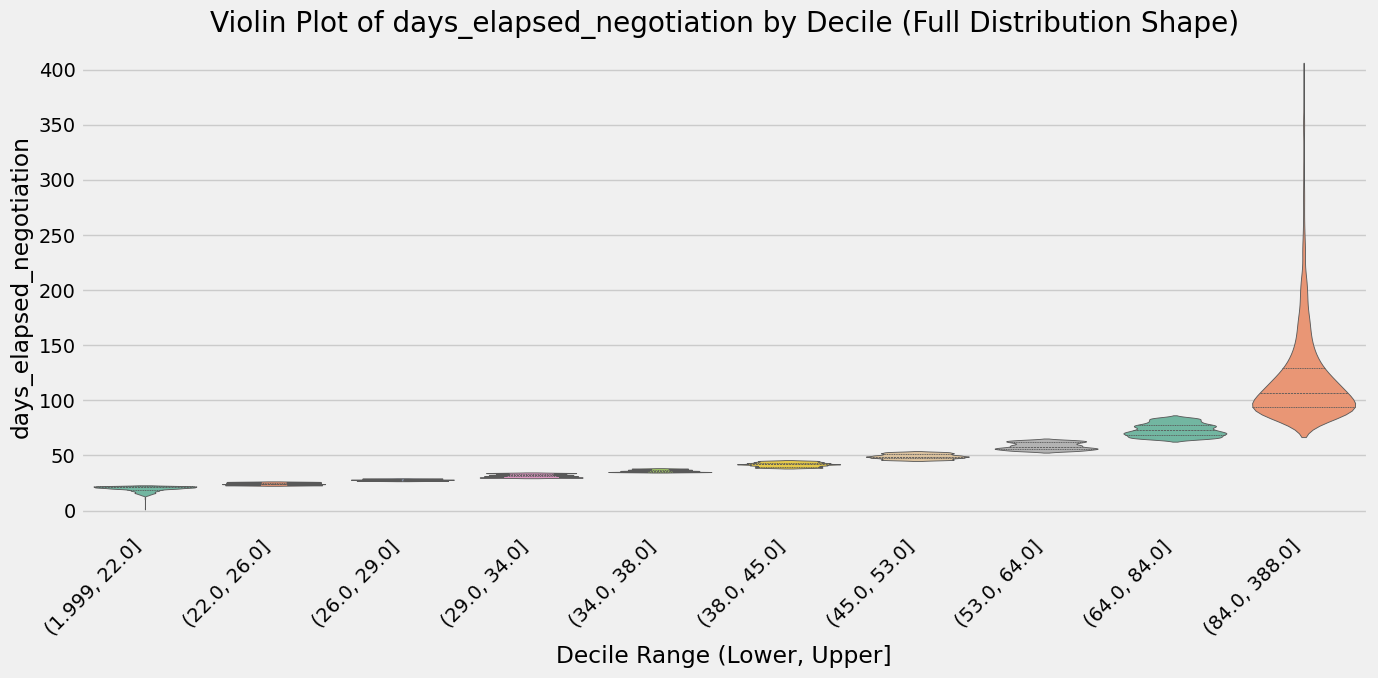

In [53]:
# Assuming 'df' and the column names are defined as in the previous script
column_to_bin = 'days_elapsed_negotiation'
decile_label_col = f'{column_to_bin}_Decile_Label'

# Filter for non-null values for plotting
plot_df = df.dropna(subset=[column_to_bin, decile_label_col]).copy()

print(f"\n## 🎻 Violin Plot Visualization for {column_to_bin} ##")

plt.figure(figsize=(14, 7))
# Use the 'split=True' or 'inner="quartile"' parameter for more detail if needed.
sns.violinplot(x=decile_label_col, y=column_to_bin, data=plot_df, inner="quartile", palette="Set2")
plt.title(f'Violin Plot of {column_to_bin} by Decile (Full Distribution Shape)')
plt.xlabel('Decile Range (Lower, Upper]')
plt.ylabel(column_to_bin)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()


## 🎯 Strip Plot Visualization for days_elapsed_negotiation ##


/tmp/ipykernel_503/2766928799.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=decile_label_col, y=column_to_bin, data=plot_df, jitter=0.3, size=3, palette="Set1")


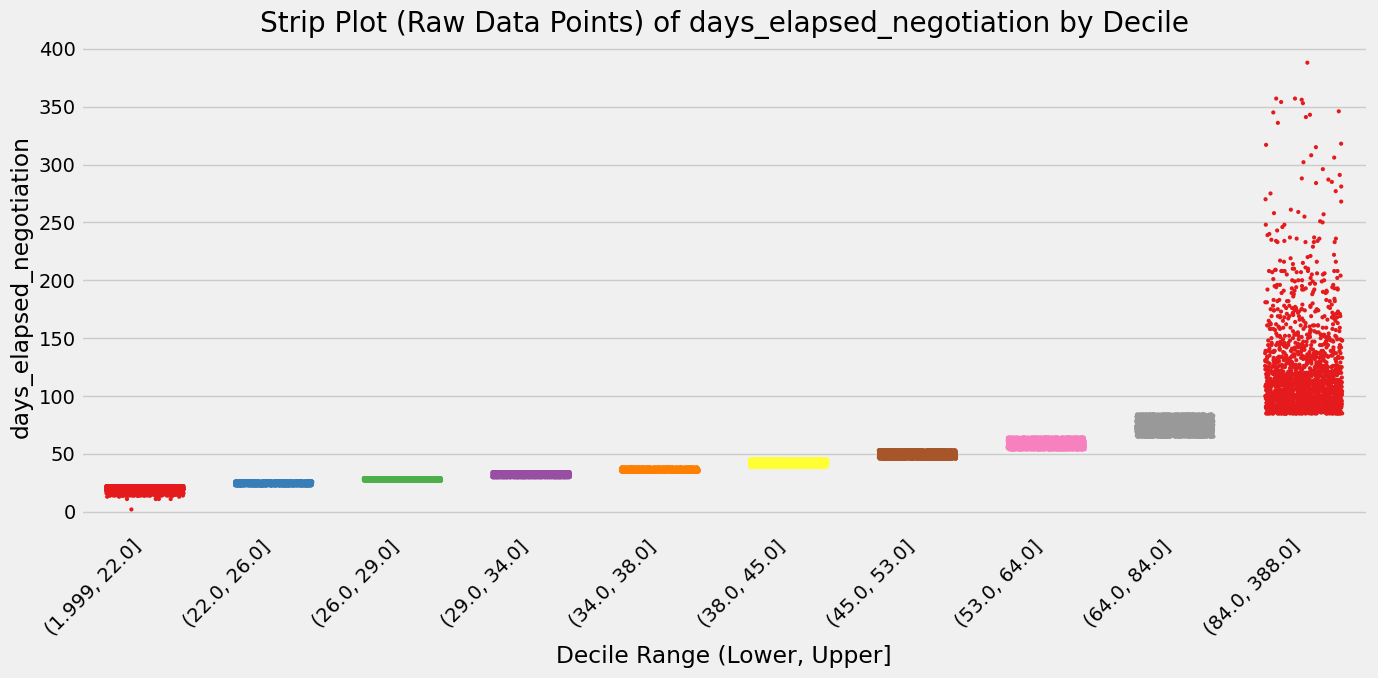

In [54]:
# Assuming 'df' and the column names are defined as in the previous script
column_to_bin = 'days_elapsed_negotiation'
decile_label_col = f'{column_to_bin}_Decile_Label'

# Filter for non-null values for plotting
plot_df = df.dropna(subset=[column_to_bin, decile_label_col]).copy()

print(f"\n## 🎯 Strip Plot Visualization for {column_to_bin} ##")

plt.figure(figsize=(14, 7))
# 'jitter=True' spreads the points horizontally for visibility
sns.stripplot(x=decile_label_col, y=column_to_bin, data=plot_df, jitter=0.3, size=3, palette="Set1")
plt.title(f'Strip Plot (Raw Data Points) of {column_to_bin} by Decile')
plt.xlabel('Decile Range (Lower, Upper]')
plt.ylabel(column_to_bin)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

# Visualize categorical feature distributions by default status

## Subtask:
Create bar plots showing the count or proportion of defaulting customers within each category of the categorical features.


**Reasoning**:
Create bar plots showing the proportion of defaulting customers within each category of the categorical features to visualize their contribution to the target variable.



Analysis for categorical feature: loan_consultant_name


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_consultant_name,,,
Alex Chavez,531,2.821017,0.005650
Alicia Villa,203,1.078468,0.004926
Amani Woods,48,0.255007,0.020833
Ana Daneri Santamaria,318,1.689423,0.009434
Andrae Holden,197,1.046592,0.000000
...,...,...,...
Tony Valicento,232,1.232535,0.008621
Tosh Oxborrow,273,1.450353,0.003663
Tyler Deterville,492,2.613824,0.006098


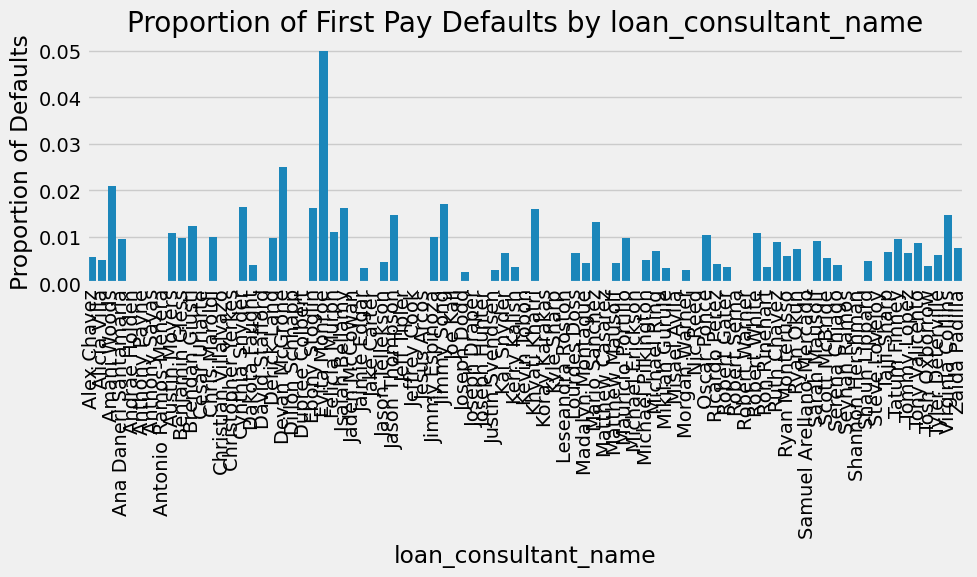

Analysis for categorical feature: loan_detail_1_debt_relief_firm


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_detail_1_debt_relief_firm,,,
ACHIEVE RESOLUTION,313,1.662859,0.006390
FREEDOM DEBT RELIEF,14851,78.898157,0.006801
"TURNBULL LAW GROUP NJ, LLC",539,2.863518,0.009276
"TURNBULL LAW GROUP SC, LLC",313,1.662859,0.000000
"TURNBULL LAW GROUP, LLC",2807,14.912607,0.004631


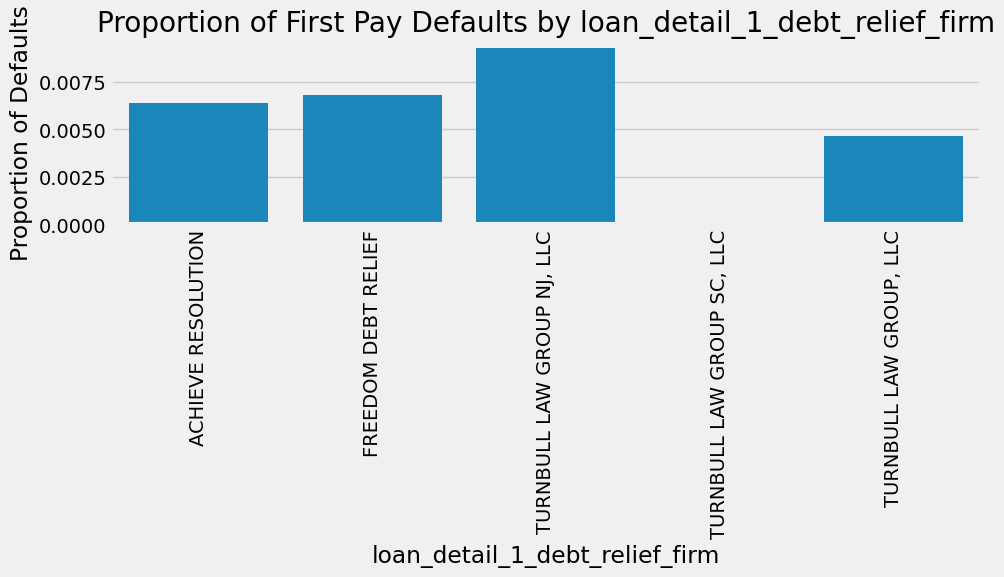

Analysis for categorical feature: loan_vintage_quarter


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_vintage_quarter,,,
20261,5632,29.920842,0.007102
20262,6629,35.217553,0.007392
20263,6562,34.861605,0.004877


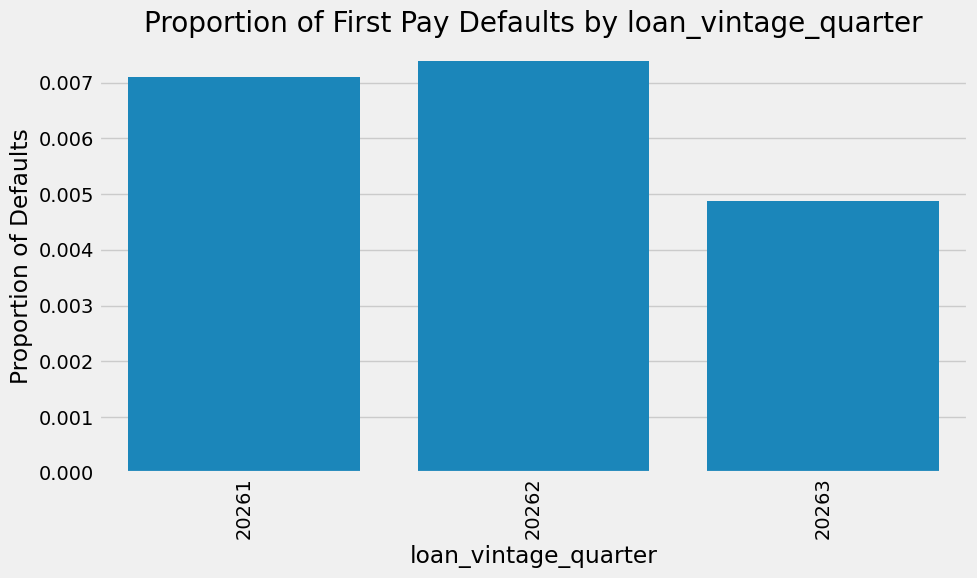

Analysis for categorical feature: loan_adr_retail_vs_wholesale


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_adr_retail_vs_wholesale,,,
Retail,12628,67.088137,0.006494
Wholesale,6195,32.911863,0.006295


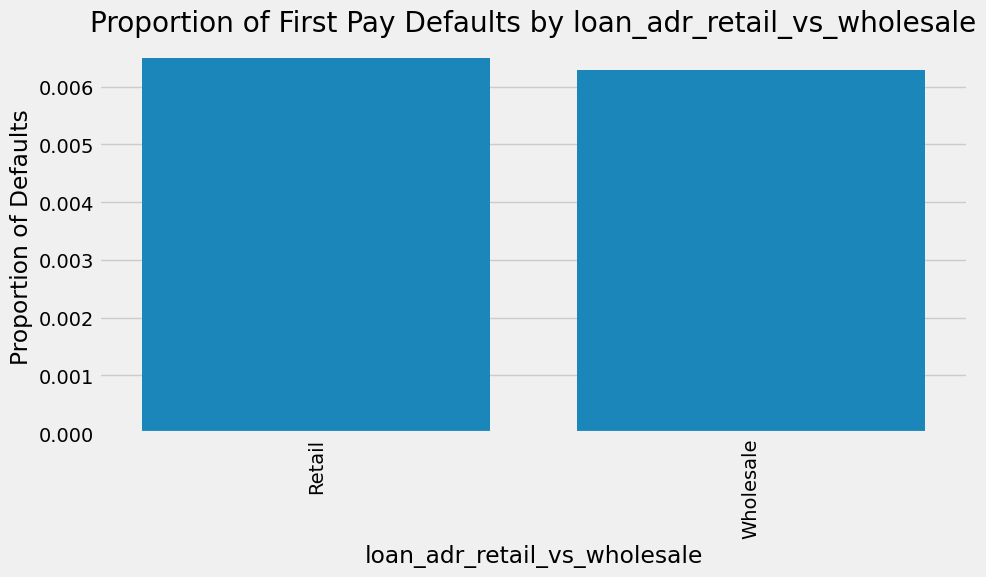

Skipping plotting for column 'loan_application_lead_category' due to error: division by zero
Skipping plotting for column 'loan_application_lead_restrictions' due to error: division by zero
Skipping plotting for column 'loan_application_customer_experience' due to error: division by zero
Analysis for categorical feature: loan_application_utm_lead_source


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_application_utm_lead_source,,,
Bubz,3,0.017657,0.000000
Call-in,4,0.023543,0.000000
FDR Credit Report,3,0.017657,0.000000
GFI Referral,2,0.011772,0.000000
Long Form,14812,87.180695,0.006211
Phone Lead,1127,6.633314,0.008873
Short Form,985,5.797528,0.006091
WFG Referral,50,0.294291,0.000000
Web Form,4,0.023543,0.250000


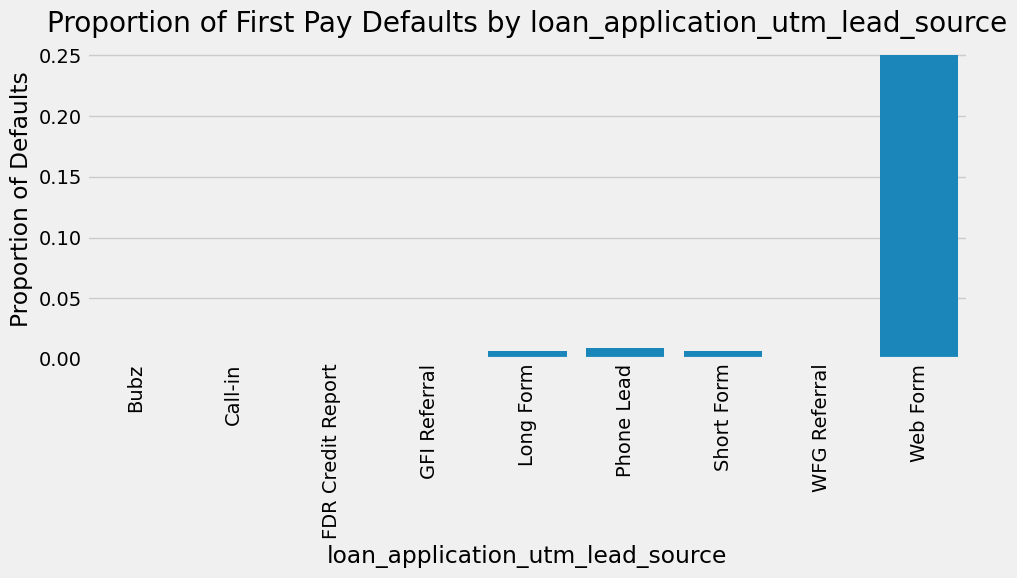

Analysis for categorical feature: loan_application_utm_lead_channel


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_application_utm_lead_channel,,,
affiliate,4673,37.149217,0.004922
app,16,0.127196,0.000000
direct mail,9,0.071548,0.000000
display,1928,15.327133,0.008817
imp,5,0.039749,0.000000
lendage,24,0.190794,0.041667
nurture,2,0.015900,0.000000
offline,6,0.047699,0.000000
organic,1662,13.212497,0.007220


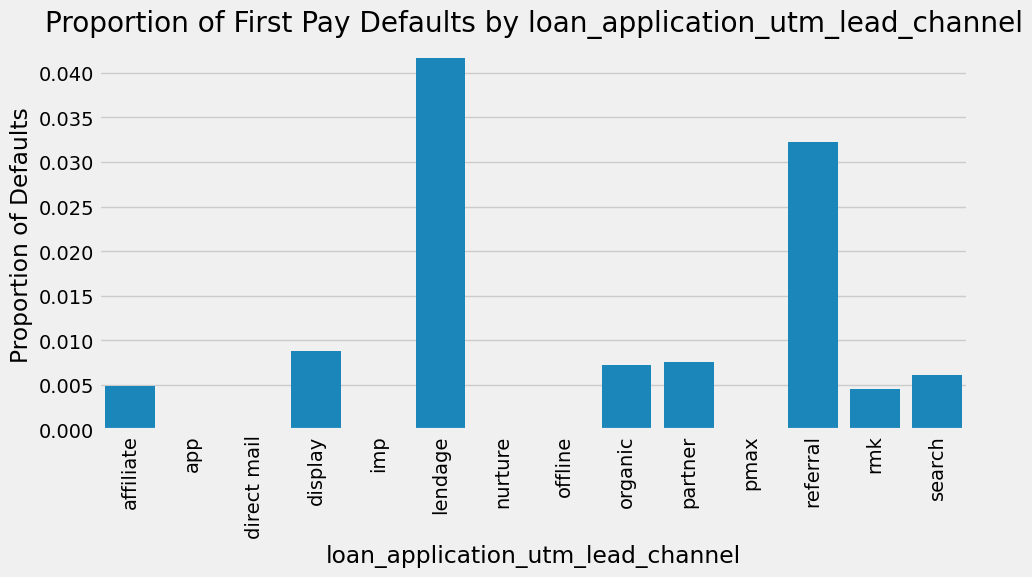

Analysis for categorical feature: loan_application_loan_use


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_application_loan_use,,,
Consolidation Plus,18823,100.0,0.006428


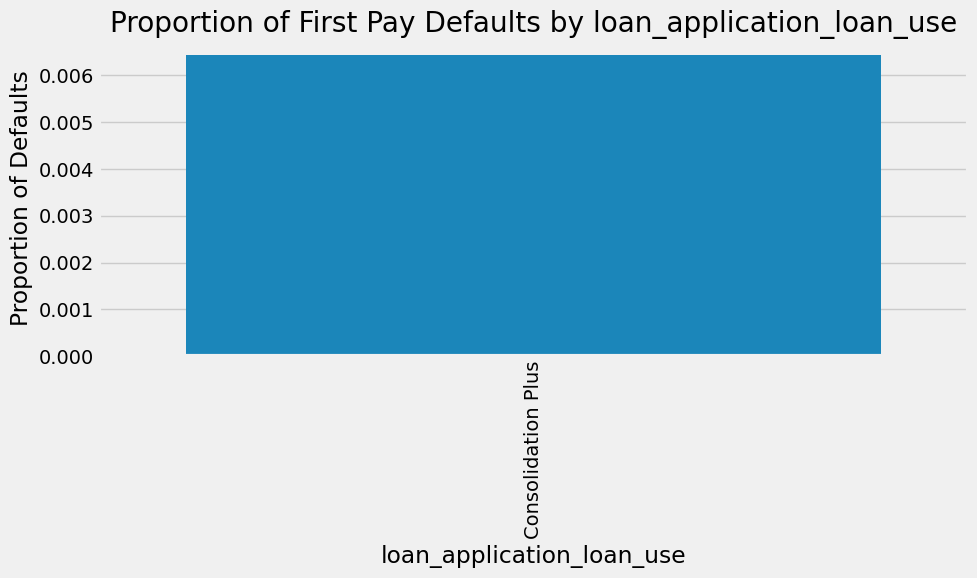

Analysis for categorical feature: loan_origination_loan_amount_band


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_loan_amount_band,,,
10K to 15K,4712,25.033204,0.004457
15K to 18K,2097,11.140626,0.006676
18K to 20K,1071,5.689848,0.008403
20K to 25K,1975,10.492483,0.007595
25K to 30K,1195,6.348616,0.005021
30K to 35K,864,4.590129,0.006944
<10K,5195,27.599214,0.007892
>35K,1714,9.105881,0.005251


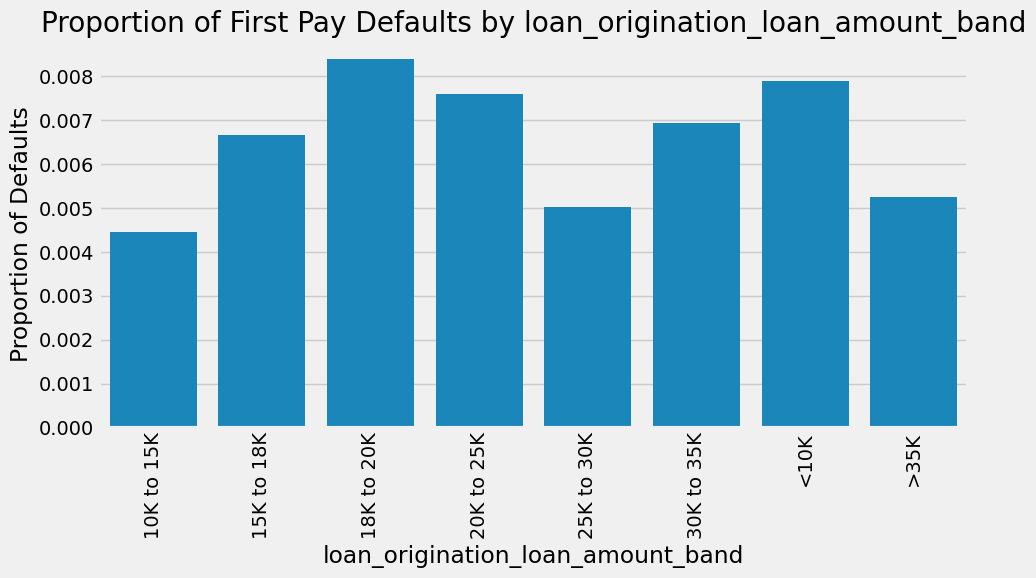

Analysis for categorical feature: loan_origination_interest_rate_band


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_interest_rate_band,,,
≥20% and <25%,13701,72.78861,0.005766
≥25%,5122,27.21139,0.008200


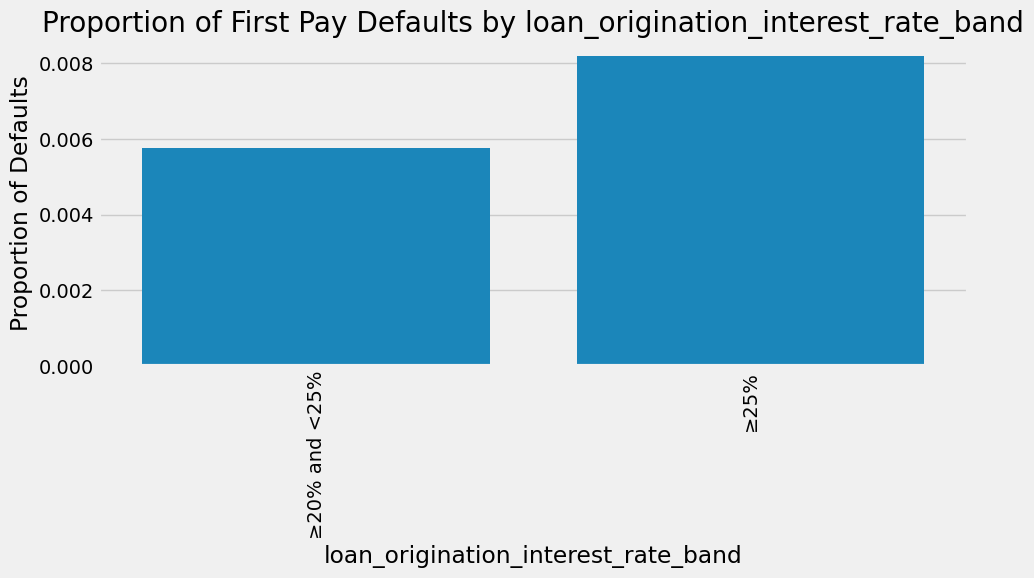

Analysis for categorical feature: loan_origination_principal_period


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_principal_period,,,
BW,9215,48.956064,0.004341
MO,7699,40.902088,0.008573
S4,478,2.539446,0.010460
SM,1431,7.602401,0.006988


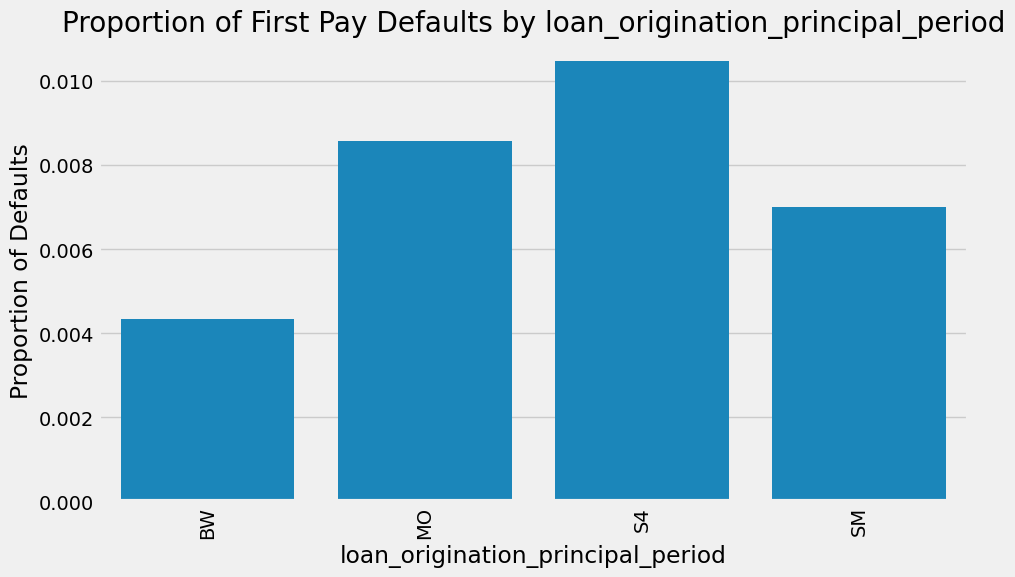

Analysis for categorical feature: borrower_language


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_language,,,
ENGLISH,18822,99.994687,0.006429
SPANISH,1,0.005313,0.000000


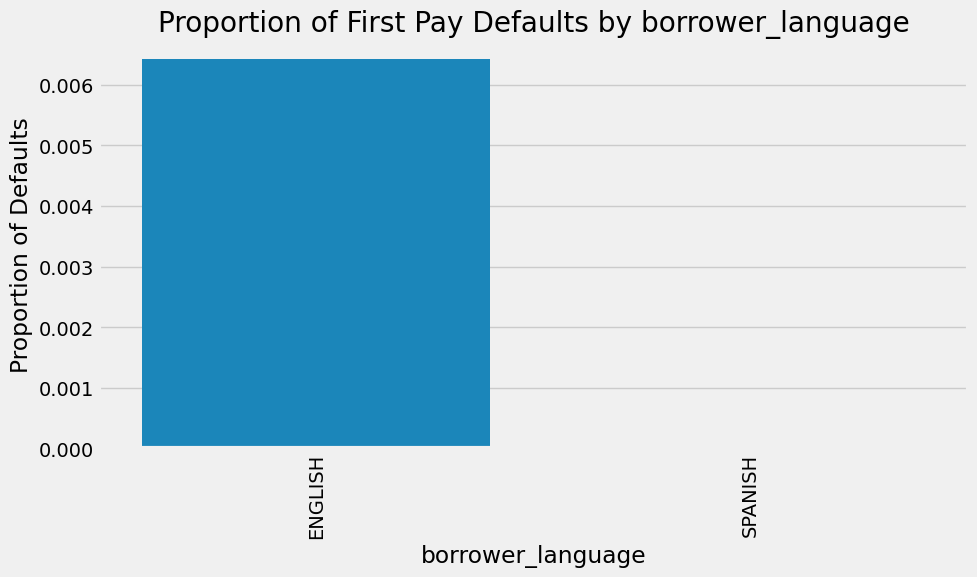

Analysis for categorical feature: borrower_fico_bands_origination


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_fico_bands_origination,,,
300 - 579,10989,58.380704,0.006916
580 - 669,7378,39.196727,0.005422
670 - 739,436,2.316315,0.011468
740 - 799,17,0.090315,0.000000
> 800,3,0.015938,0.000000


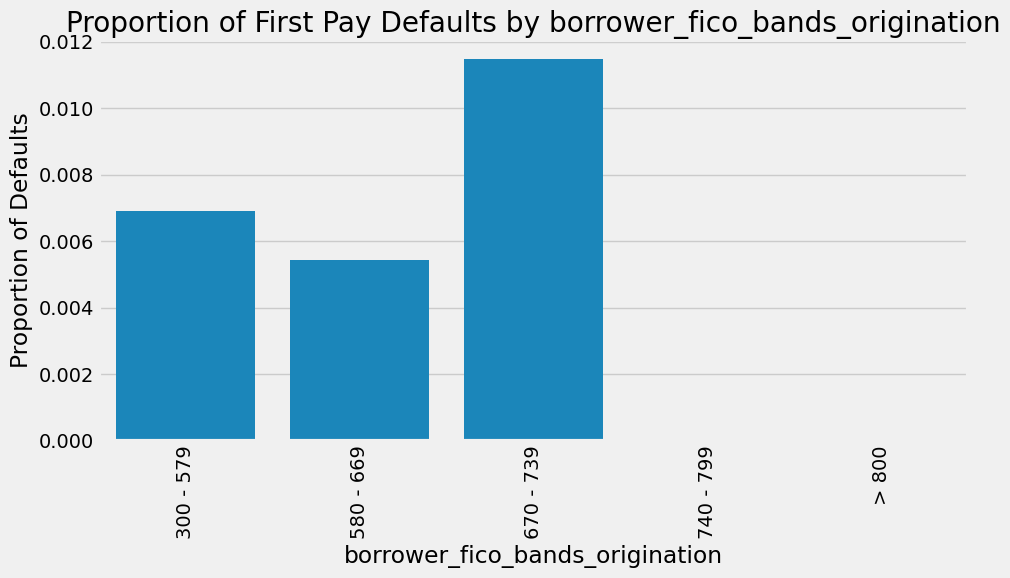

Analysis for categorical feature: borrower_fico_band_category_origination


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_fico_band_category_origination,,,
Exceptional,3,0.015938,0.000000
Fair,7378,39.196727,0.005422
Good,436,2.316315,0.011468
Very Good,17,0.090315,0.000000
Very Poor,10989,58.380704,0.006916


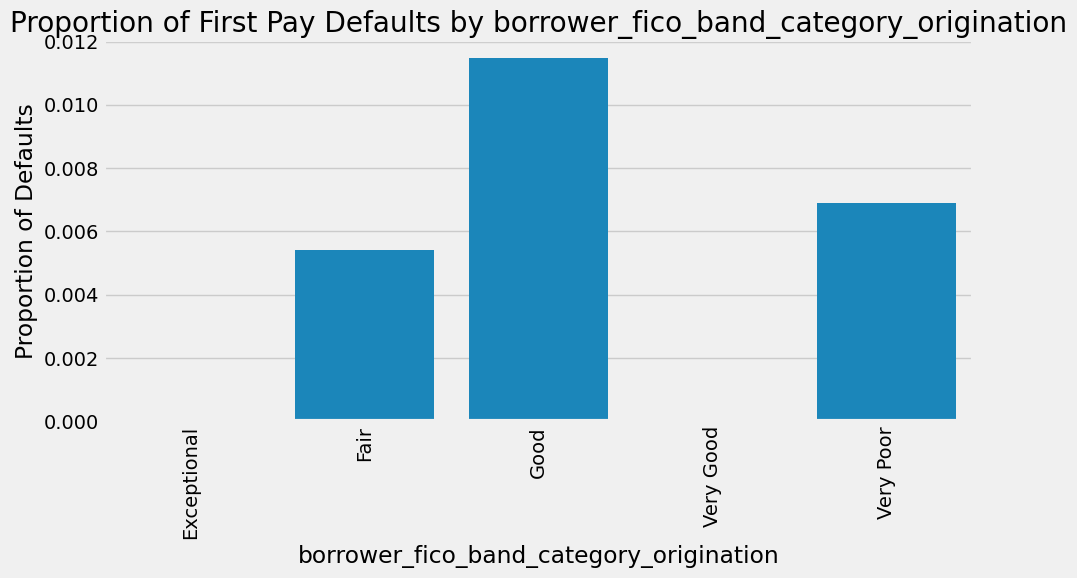

Analysis for categorical feature: borrower_annual_income_band


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_annual_income_band,,,
< 50K,5219,27.726717,0.010347
> 150K,1104,5.865165,0.007246
≥ 100K and < 125K,2006,10.657175,0.001994
≥ 125K and < 150K,991,5.264836,0.007064
≥ 50K and < 75K,5561,29.543643,0.004855
≥ 75K and < 100K,3942,20.942464,0.005327


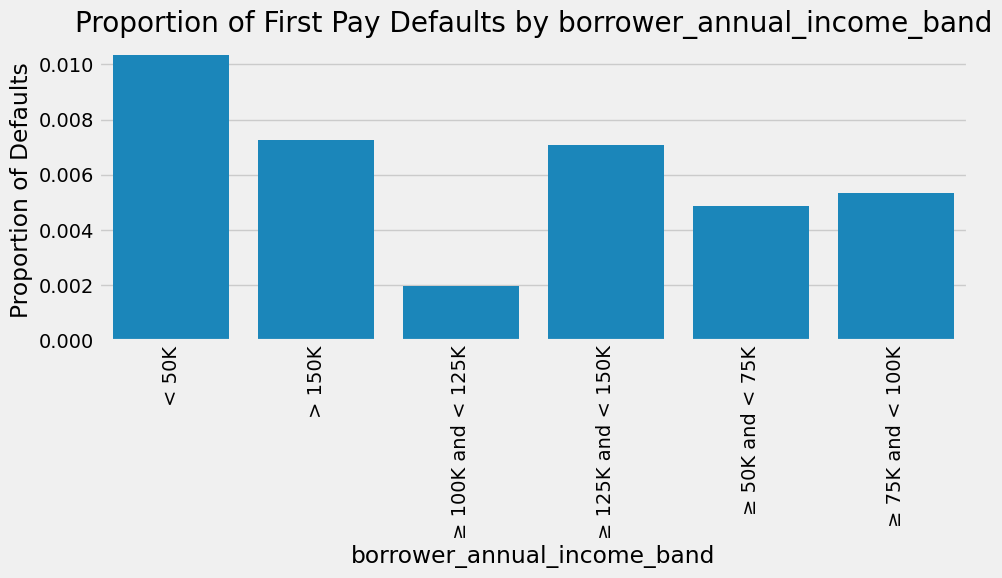

Analysis for categorical feature: borrower_origination_risk_group_twentile


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_origination_risk_group_twentile,,,
Tier 1,12932,68.703182,0.005181
Tier 2,5891,31.296818,0.009167


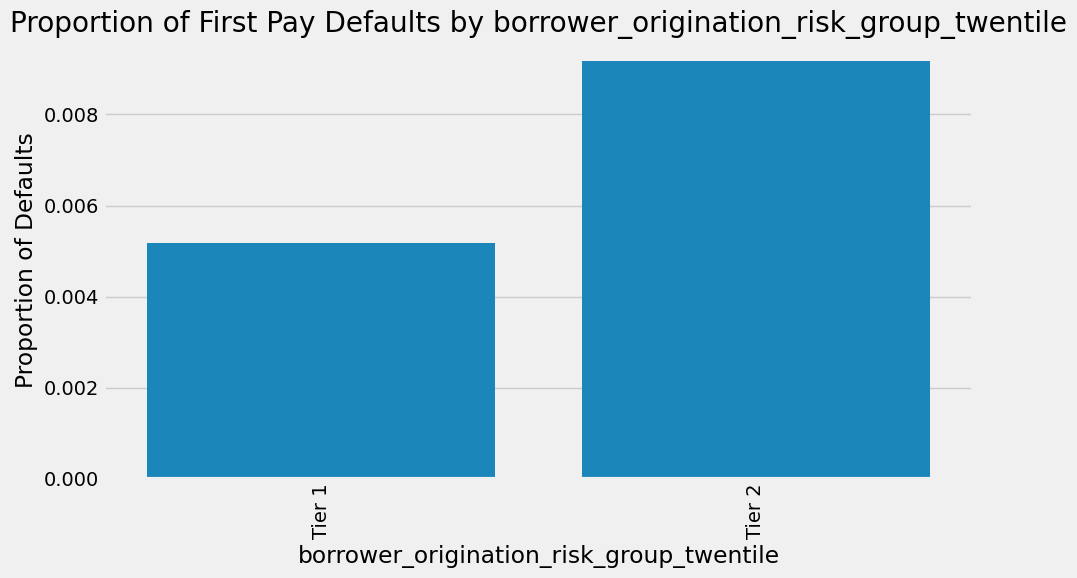

Analysis for categorical feature: borrower_origination_state


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
borrower_origination_state,,,
AK,44,0.233757,0.000000
AL,374,1.986931,0.000000
AR,266,1.413165,0.003759
AZ,386,2.050683,0.007772
CA,1996,10.604048,0.006513
DC,25,0.132816,0.000000
DE,49,0.260320,0.000000
FL,1850,9.828401,0.008649
GA,571,3.033523,0.005254


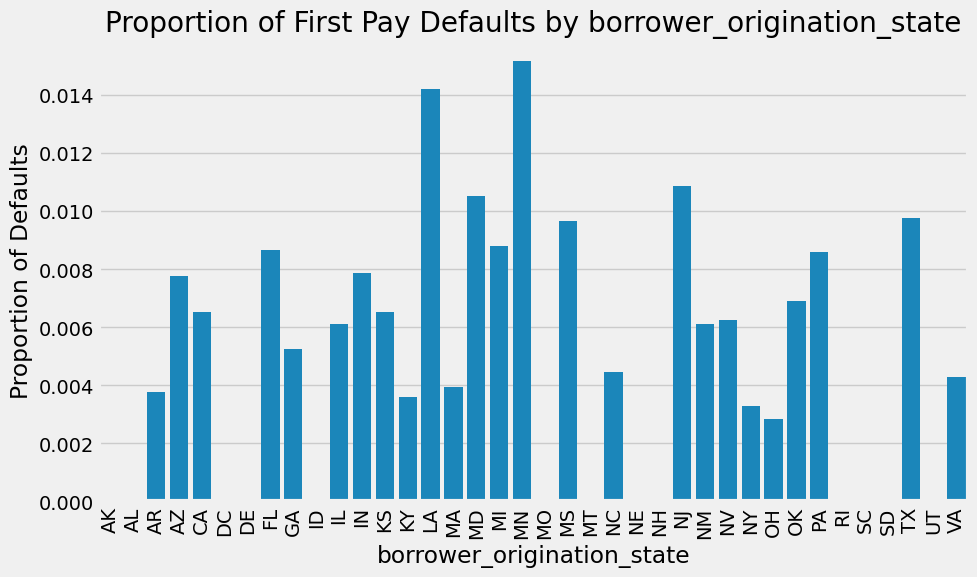

Analysis for categorical feature: loan_origination_first_payment_day_of_week


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_origination_first_payment_day_of_week,,,
Friday,7817,41.528981,0.005117
Monday,1866,9.913404,0.010182
Saturday,1851,9.833714,0.007563
Sunday,1442,7.660840,0.006935
Thursday,2171,11.533762,0.005988
Tuesday,1583,8.409924,0.004422
Wednesday,2093,11.119375,0.008600


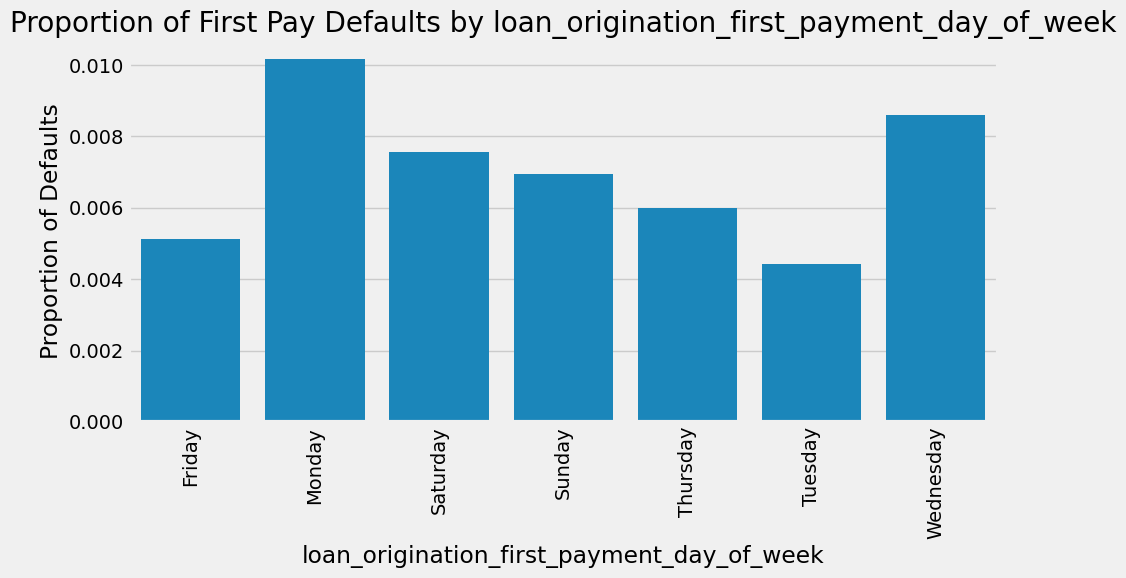

Analysis for categorical feature: loan_only_one_transaction_day_of_week


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_only_one_transaction_day_of_week,,,
Friday,5411,64.286563,0.000924
Monday,532,6.320542,0.011278
Saturday,51,0.605917,0.019608
Sunday,428,5.084947,0.007009
Thursday,893,10.609481,0.003359
Tuesday,526,6.249257,0.011407
Wednesday,576,6.843293,0.012153


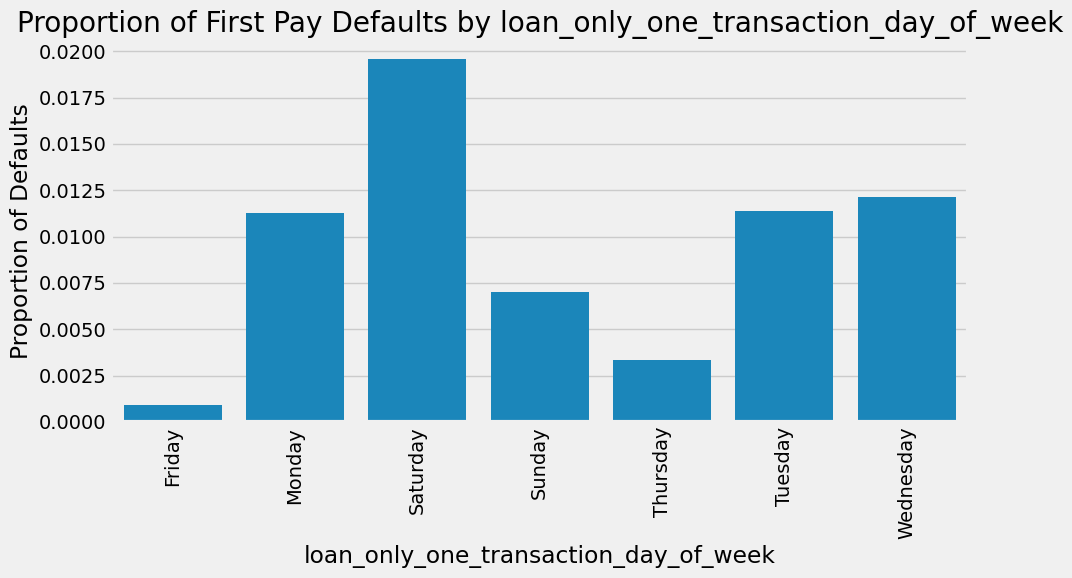

Analysis for categorical feature: days_elapsed_bucket_negotiation


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
days_elapsed_bucket_negotiation,,,
120 - 149 Days Elapsed,320,1.700048,0.009375
150+ Days Elapsed,275,1.460979,0.029091
30 - 59 Days Elapsed,8668,46.050045,0.005307
60 - 89 Days Elapsed,2931,15.571375,0.006482
90 - 119 Days Elapsed,940,4.993890,0.010638
≤ 29 Days Elapsed,5689,30.223663,0.006152


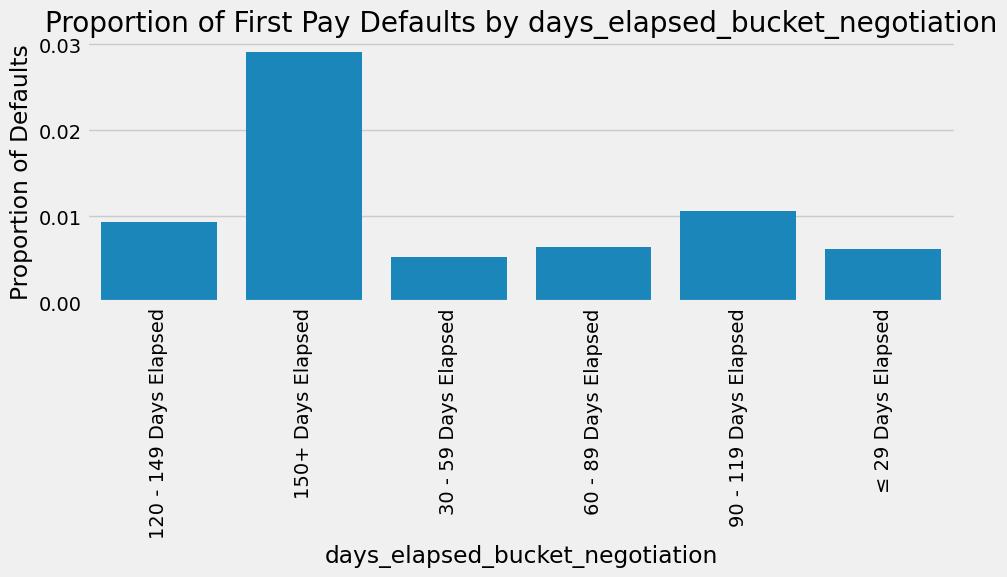

Analysis for categorical feature: loan_1st_pay_default_return_code


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
loan_1st_pay_default_return_code,,,
R10 - NOT AUTHORIZED,8,25.000,1.0
RO1 - INSUFFICIENT FUNDS,15,46.875,1.0
RO2 - ACCOUNT CLOSED,3,9.375,1.0
RO4 - INVALID ACCT NUMBER,1,3.125,1.0
RO8 - STOP PAYMENT,5,15.625,1.0


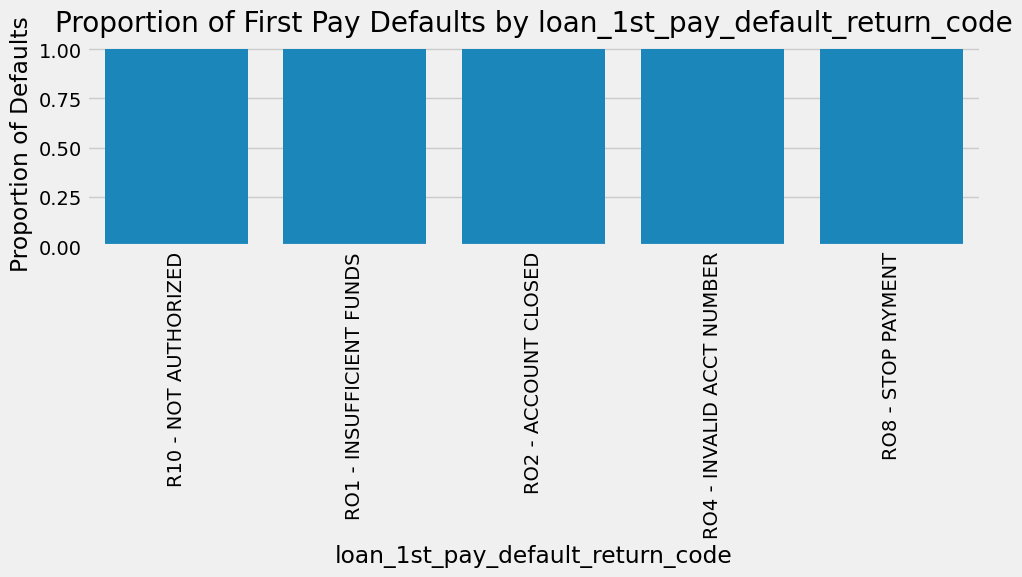

Analysis for categorical feature: days_elapsed_negotiation_Decile_Label


flag_1st_pay_default,loan_count,percentage_of_total,default_proportion
days_elapsed_negotiation_Decile_Label,,,
"(1.999, 22.0]",2107,11.193752,0.004746
"(22.0, 26.0]",1748,9.286511,0.007437
"(26.0, 29.0]",1834,9.743399,0.006543
"(29.0, 34.0]",2091,11.108750,0.003826
"(34.0, 38.0]",1664,8.840249,0.003606
"(38.0, 45.0]",2065,10.970621,0.006295
"(45.0, 53.0]",1753,9.313074,0.005705
"(53.0, 64.0]",1833,9.738086,0.005456
"(64.0, 84.0]",1930,10.253413,0.006218


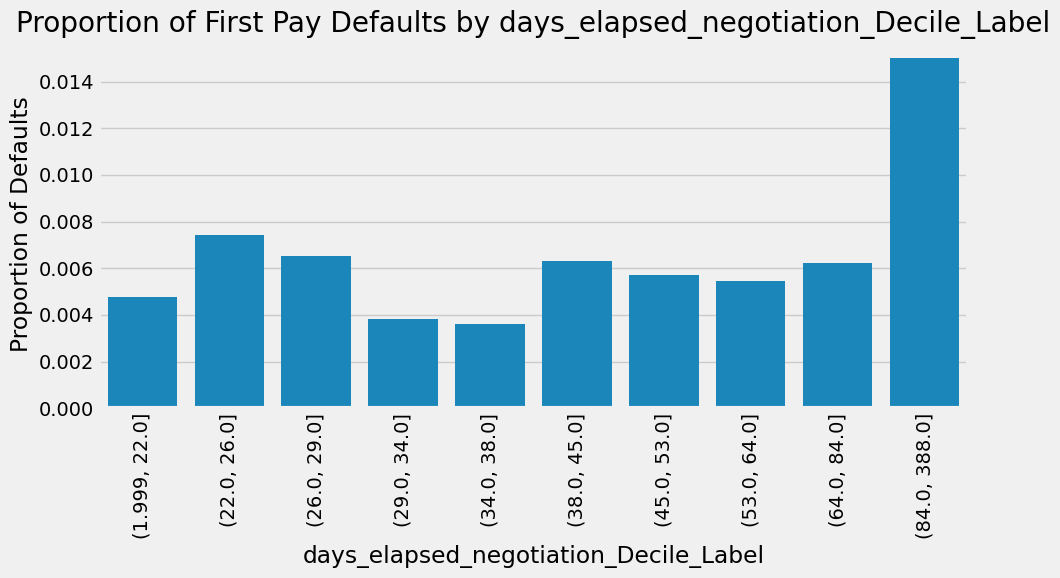

In [55]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Define columns to exclude
columns_to_exclude = ['loan_id', 'loan_product', 'loan_investor', 'loan_contributing_investor']

# Filter out excluded columns
plottable_categorical_cols = [col for col in categorical_cols if col not in columns_to_exclude]


# Iterate through filtered categorical columns and create bar plots of default proportions
for col in plottable_categorical_cols:
    try:
        # Create a cross-tabulation with the target variable
        cross_tab = pd.crosstab(df[col], df['flag_1st_pay_default'])

        # Calculate the proportion of defaults within each category
        # Handle cases where a category might not have both default and non-default instances
        cross_tab['default_proportion'] = cross_tab.get(1, 0) / (cross_tab.get(0, 0) + cross_tab.get(1, 0))

        # Calculate loan count and percentage of total for each category
        cross_tab['loan_count'] = cross_tab.get(0, 0) + cross_tab.get(1, 0)
        total_loans = cross_tab['loan_count'].sum()
        cross_tab['percentage_of_total'] = (cross_tab['loan_count'] / total_loans) * 100

        # Sort the cross_tab index to order the x-axis
        cross_tab = cross_tab.sort_index()

        # Display table with categorical information
        display_table = cross_tab[['loan_count', 'percentage_of_total', 'default_proportion']].copy()
        print(f"Analysis for categorical feature: {col}")
        display(display_table)


        # Create a bar plot of default proportions
        plt.figure(figsize=(10, 6))
        sns.barplot(x=cross_tab.index, y=cross_tab['default_proportion'])
        plt.title(f'Proportion of First Pay Defaults by {col}')
        plt.xlabel(col)
        plt.ylabel('Proportion of Defaults')
        plt.xticks(rotation=90) # Rotate labels for readability
        plt.tight_layout()
        plt.show()
        plt.close() # Close the figure to manage memory
    except Exception as e:
        print(f"Skipping plotting for column '{col}' due to error: {e}")
        plt.close() # Ensure figure is closed even if plotting fails

# Visualize feature relationships

## Subtask:
Depending on the number of features and complexity, consider visualizing relationships between important features and the target variable using scatter plots or other relevant plot types.


**Reasoning**:
Identify important features, select pairs of features for visualization, and create scatter plots or box plots as appropriate, colored by the target variable, to visualize their relationship with the target variable.



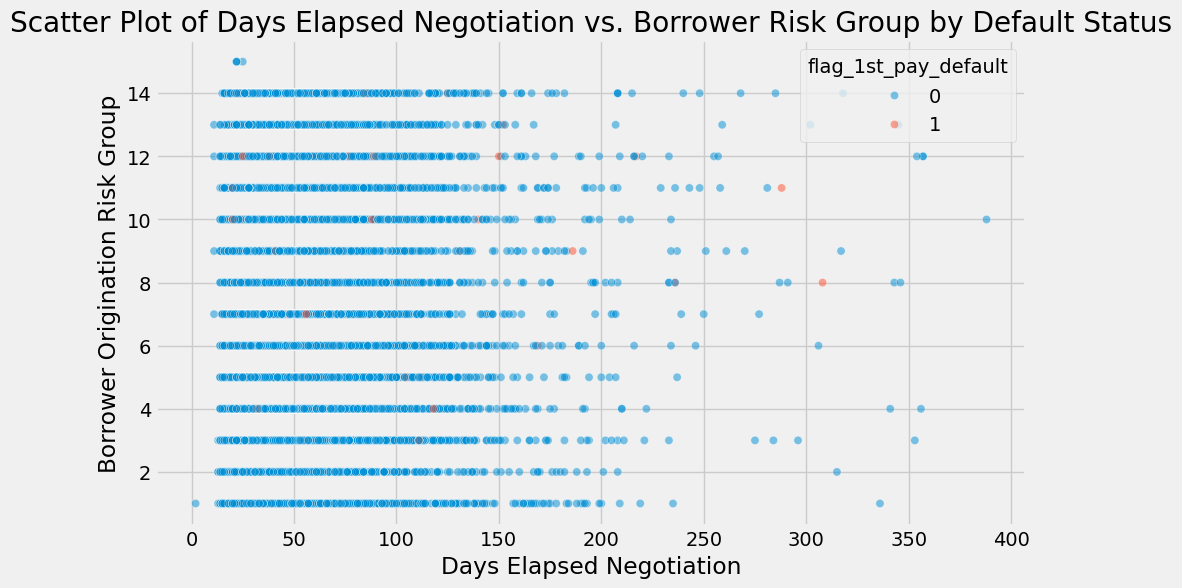

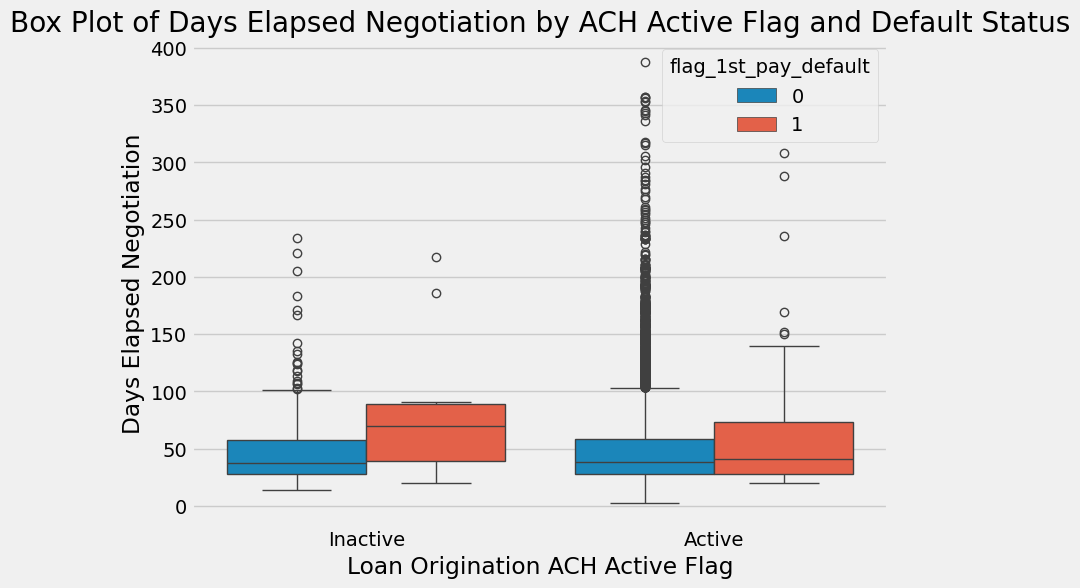

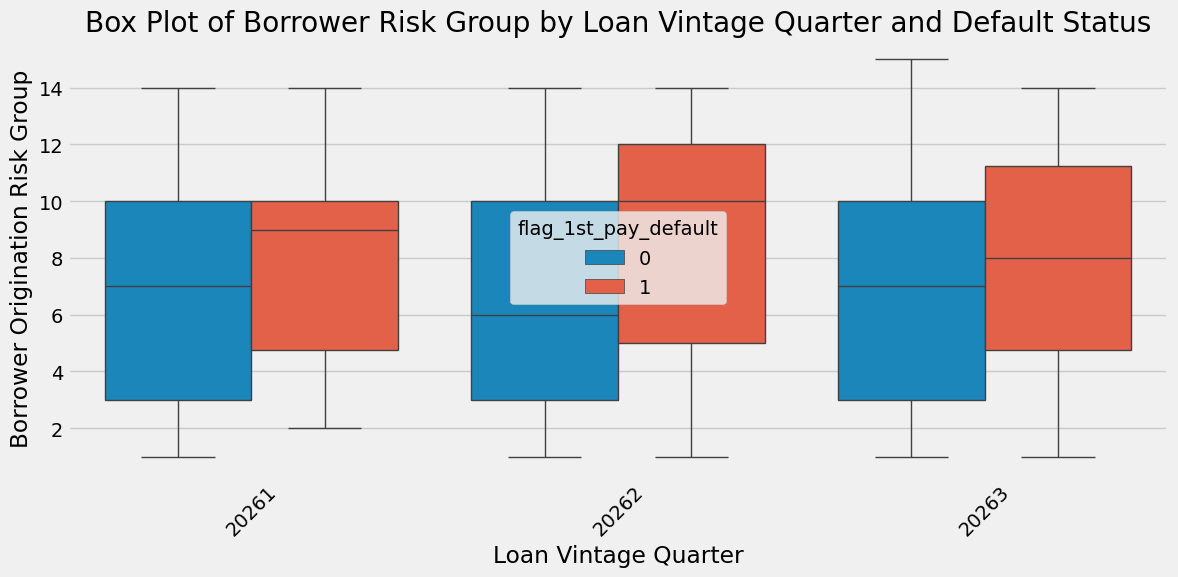

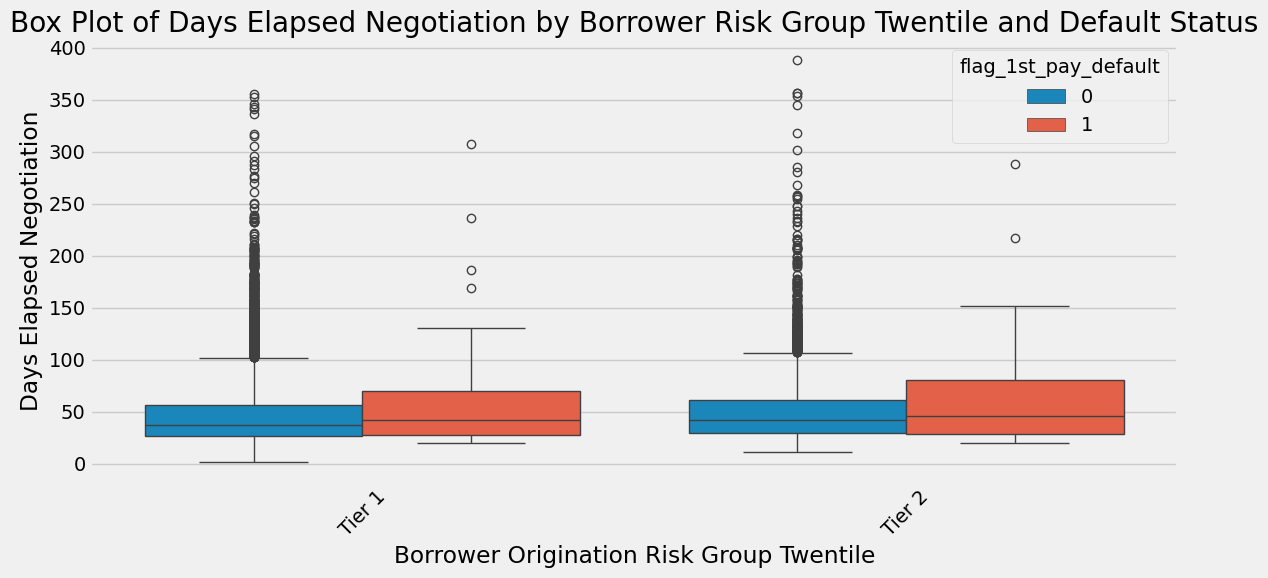

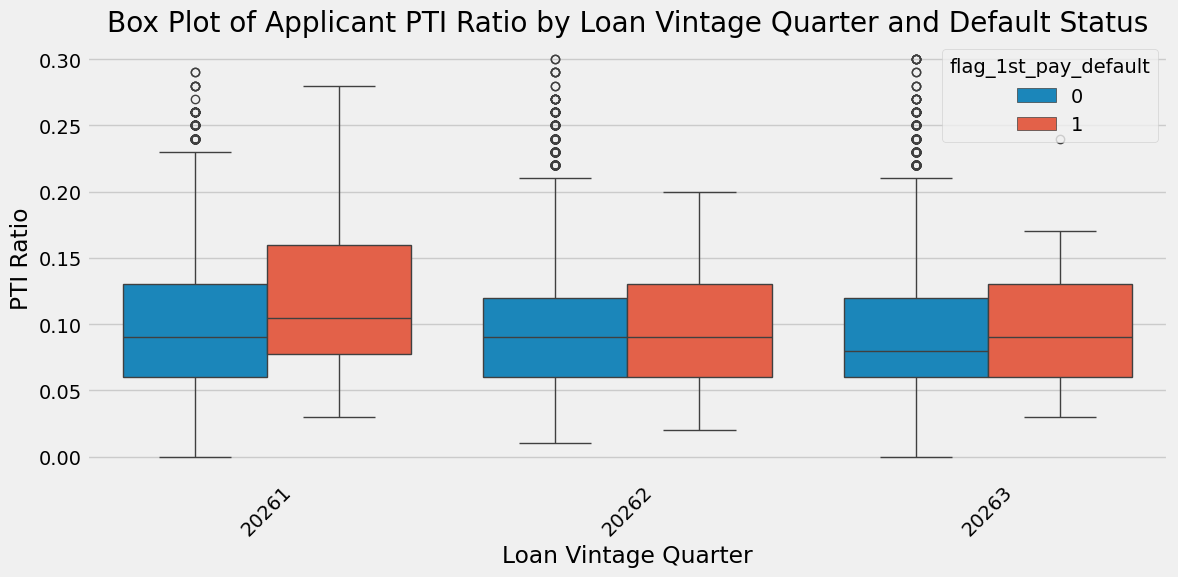

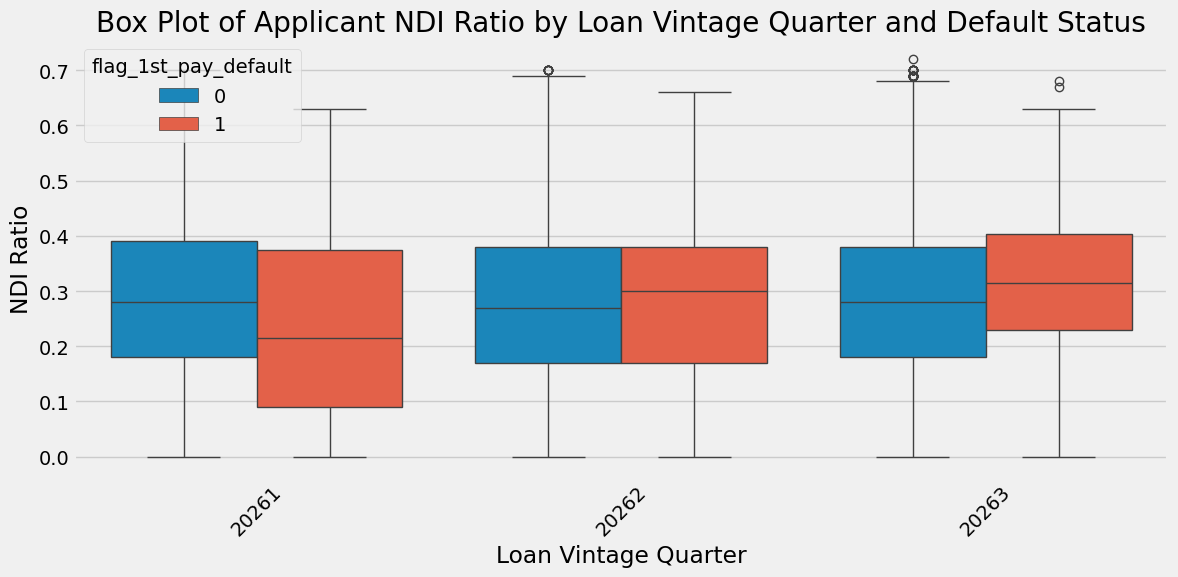

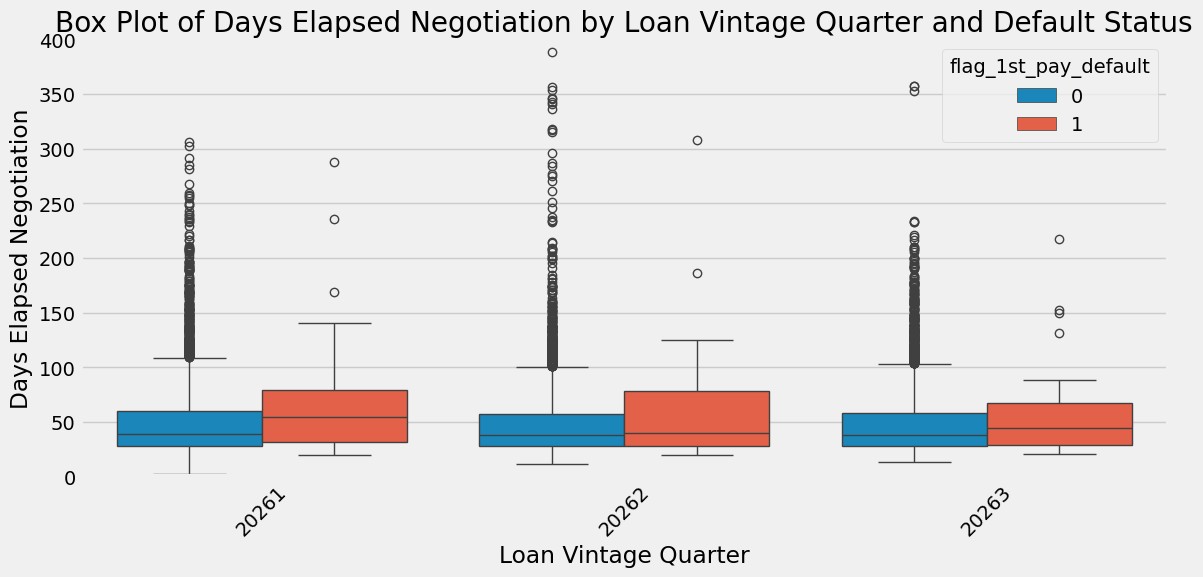

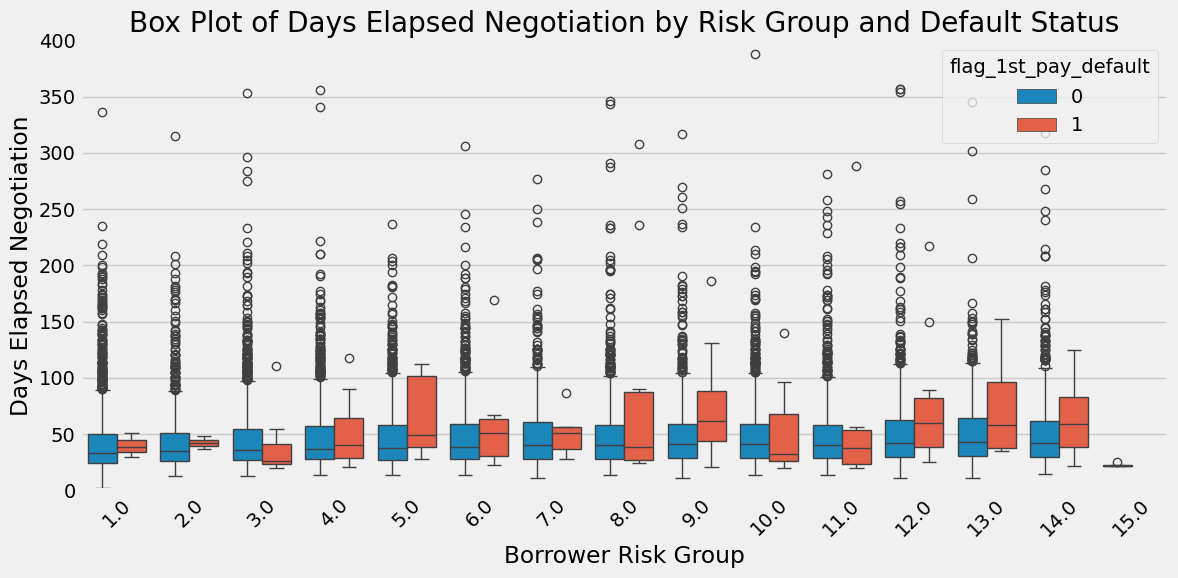

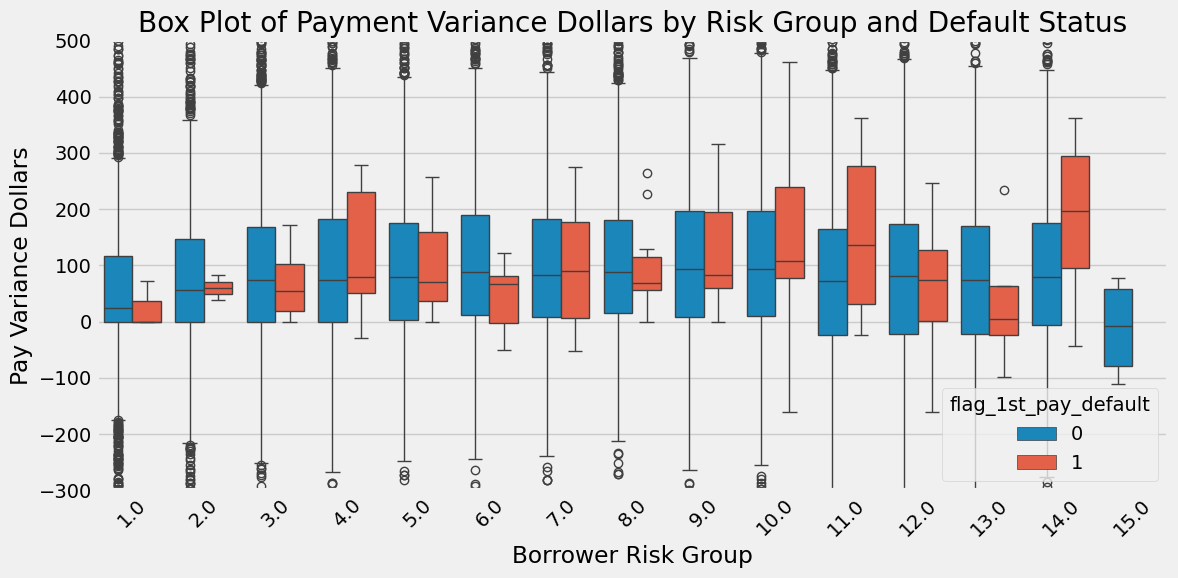

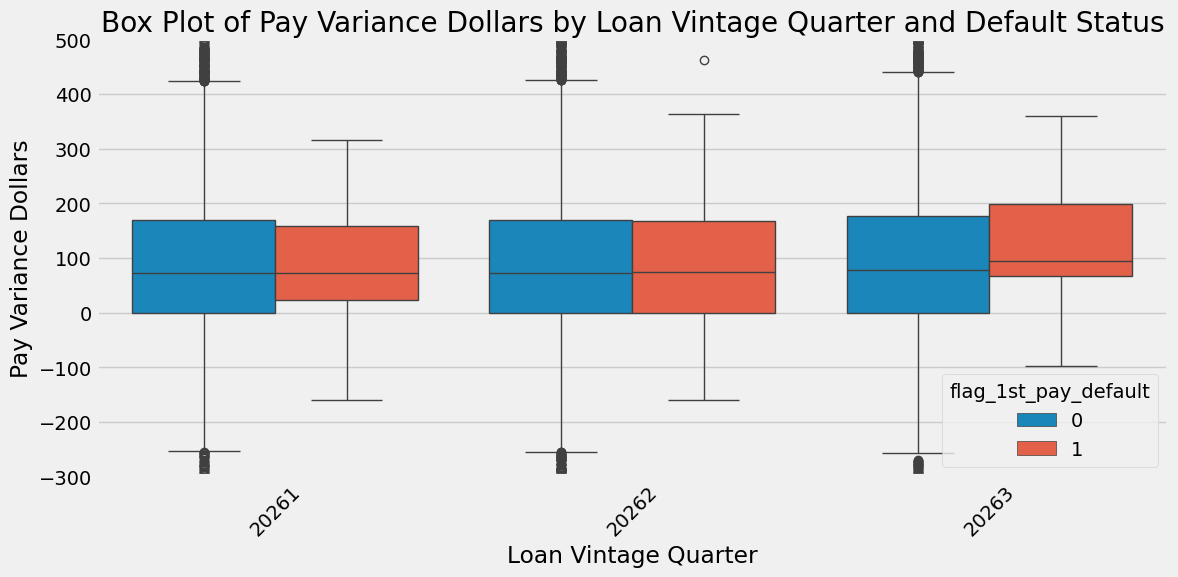

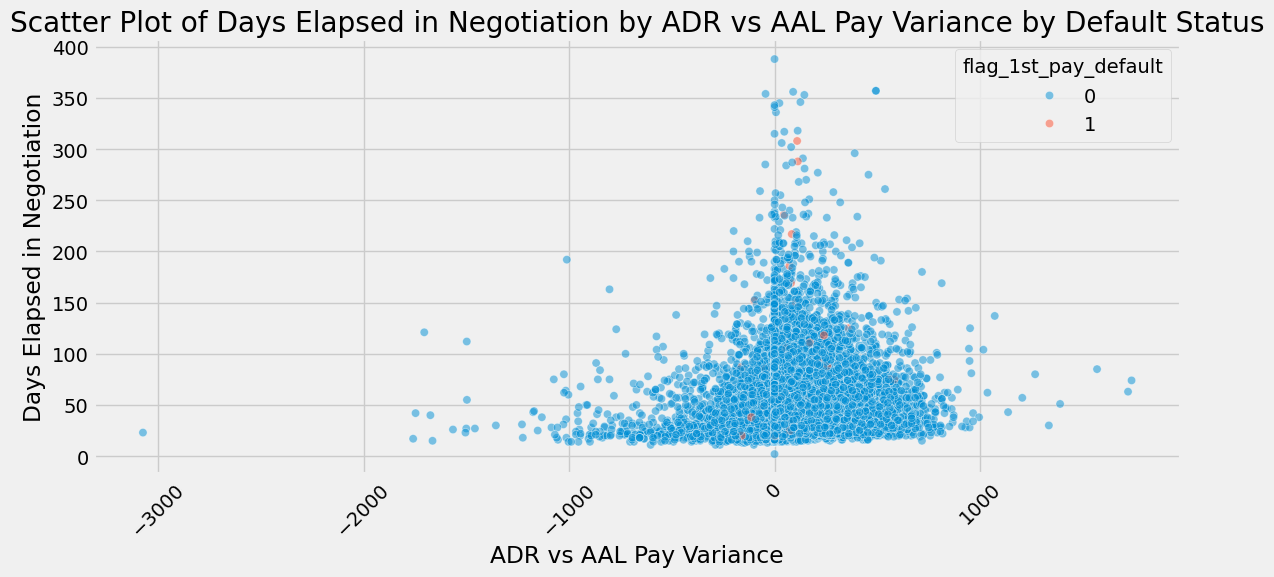

In [56]:
# Based on the previous feature importance analysis (filtered_feature_importances),
# let's select the top features for visualization.
# The top features identified were:
# days_elapsed_negotiation
# borrower_origination_risk_group
# loan_vintage_quarter
# loan_origination_ach_active_flag
# borrower_origination_risk_group_twentile

# Let's visualize the relationship between some pairs of these important features and the target.

# Pair 1: days_elapsed_negotiation (numerical) and borrower_origination_risk_group (numerical)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='days_elapsed_negotiation', y='borrower_origination_risk_group', hue='flag_1st_pay_default', alpha=0.5)
plt.title('Scatter Plot of Days Elapsed Negotiation vs. Borrower Risk Group by Default Status')
plt.xlabel('Days Elapsed Negotiation')
plt.ylabel('Borrower Origination Risk Group')
plt.show()

# Pair 2: days_elapsed_negotiation (numerical) and loan_origination_ach_active_flag (categorical/binary)
# Although loan_origination_ach_active_flag is binary numerical after encoding,
# it represents a categorical concept. A box plot is suitable here.
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='loan_origination_ach_active_flag', y='days_elapsed_negotiation', hue='flag_1st_pay_default')
plt.title('Box Plot of Days Elapsed Negotiation by ACH Active Flag and Default Status')
plt.xlabel('Loan Origination ACH Active Flag')
plt.ylabel('Days Elapsed Negotiation')
plt.xticks([0, 1], ['Inactive', 'Active']) # Label the x-axis
plt.show()

# Pair 3: loan_vintage_quarter (categorical) and borrower_origination_risk_group (numerical)
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='borrower_origination_risk_group', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Borrower Risk Group by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('Borrower Origination Risk Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 4: borrower_origination_risk_group_twentile (categorical) and days_elapsed_negotiation (numerical)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='borrower_origination_risk_group_twentile', y='days_elapsed_negotiation', hue='flag_1st_pay_default')
plt.title('Box Plot of Days Elapsed Negotiation by Borrower Risk Group Twentile and Default Status')
plt.xlabel('Borrower Origination Risk Group Twentile')
plt.ylabel('Days Elapsed Negotiation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 5: loan_vintage_quarter (categorical) and applicant PTI
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='loan_application_PTI_ratio', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Applicant PTI Ratio by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('PTI Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 6: loan_vintage_quarter (categorical) and applicant NDI
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='loan_application_NDI_ratio', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Applicant NDI Ratio by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('NDI Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 7: loan_vintage_quarter (categorical) and days elapsed negotiation
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='days_elapsed_negotiation', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Days Elapsed Negotiation by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('Days Elapsed Negotiation')
# Set the y-axis limit from 0 to 400
plt.ylim(0, 400)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 7: origination risk group and days elapsed negotiation
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for risk group and sort them
risk_group_order = sorted(df['borrower_origination_risk_group'].unique())
sns.boxplot(data=df, x='borrower_origination_risk_group', y='days_elapsed_negotiation', hue='flag_1st_pay_default', order=risk_group_order)
plt.title('Box Plot of Days Elapsed Negotiation by Risk Group and Default Status')
plt.xlabel('Borrower Risk Group')
plt.ylabel('Days Elapsed Negotiation')
# Set the y-axis limit from 0 to 400
plt.ylim(0, 400)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 8: origination risk group and ADR vs AAL Pay Variance
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for risk group and sort them
risk_group_order = sorted(df['borrower_origination_risk_group'].unique())
sns.boxplot(data=df, x='borrower_origination_risk_group', y='fdr_vs_aal_payment_variance', hue='flag_1st_pay_default', order=risk_group_order)
plt.title('Box Plot of Payment Variance Dollars by Risk Group and Default Status')
plt.xlabel('Borrower Risk Group')
plt.ylabel('Pay Variance Dollars')
# Set the y-axis limit from -300 to 500
plt.ylim(-300, 500)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 9: loan_vintage_quarter (categorical) and ADR vs AAL Pay Variance
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
# Get the unique values for loan_vintage_quarter and sort them
vintage_quarter_order = sorted(df['loan_vintage_quarter'].unique())
sns.boxplot(data=df, x='loan_vintage_quarter', y='fdr_vs_aal_payment_variance', hue='flag_1st_pay_default', order=vintage_quarter_order)
plt.title('Box Plot of Pay Variance Dollars by Loan Vintage Quarter and Default Status')
plt.xlabel('Loan Vintage Quarter')
plt.ylabel('Pay Variance Dollars')
# Set the y-axis limit from -300 to 500
plt.ylim(-300, 500)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pair 10: origination risk group and ADR vs AAL Pay Variance
# Use a box plot or violin plot to show the distribution of risk group across vintage quarters,
# separated by default status.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='fdr_vs_aal_payment_variance', y='days_elapsed_negotiation', hue='flag_1st_pay_default', alpha=0.5)
plt.title('Scatter Plot of Days Elapsed in Negotiation by ADR vs AAL Pay Variance by Default Status')
plt.xlabel('ADR vs AAL Pay Variance')
plt.ylabel('Days Elapsed in Negotiation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification/Clustering
Analyze the provided data to identify and describe the types of customers who are most likely to default on their first loan payment, using the `flag_1st_pay_default` column as the target variable. This analysis should involve either classification or clustering techniques to understand the characteristics of these customers.

## Data preprocessing

### Subtask:
Ensure the data is ready for classification or clustering by handling missing values, encoding categorical variables, and scaling numerical features. We can reuse the preprocessing steps from the previous task.


**Reasoning**:
The data has already been loaded and partially preprocessed in the previous steps. I will now continue with the remaining preprocessing steps as outlined in the instructions to prepare the data for either classification or clustering. This involves separating the target variable, handling missing values, encoding categorical features, dropping date/dbdate columns, and checking for constant columns and remaining NaNs.



In [57]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # Separate target variable
    X = df.drop('flag_1st_pay_default', axis=1)
    y = df['flag_1st_pay_default']

    # Drop columns with all missing values
    X.dropna(axis=1, how='all', inplace=True)

    # Identify categorical and numerical columns after dropping
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns
    numerical_cols = X.select_dtypes(include=np.number).columns

    # Impute missing values (using mean for numerical and most frequent for categorical)
    numerical_imputer = SimpleImputer(strategy='mean')
    X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])

    categorical_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])

    # Encode categorical features
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

    # Drop date and dbdate columns before feature selection
    date_cols = X.select_dtypes(include=['datetime64[ns]', 'dbdate']).columns
    X = X.drop(columns=date_cols)

    # Check for constant columns before feature selection
    constant_cols = [col for col in X.columns if X[col].nunique() == 1]
    print(f"Constant columns remaining: {constant_cols}")

    # Check for remaining NaNs before feature selection
    print("Number of NaNs per column after imputation:")
    display(X.isnull().sum())


Constant columns remaining: ['loan_product', 'loan_application_loan_use', 'loan_fraud_flag', 'loan_bk_discharged_flag']
Number of NaNs per column after imputation:


,0
loan_id,0
loan_product,0
loan_consultant_name,0
loan_detail_1_debt_relief_firm,0
loan_vintage_quarter,0
loan_investor,0
loan_adr_retail_vs_wholesale,0
loan_application_NDI_ratio,0
loan_application_PTI_ratio,0
loan_application_utm_lead_source,0


### 🛡️ Clean Split-Workflow: Separating Pre-Origination Features from Post-Origination Leakage
To prevent target leakage during predictive tasks (like model development or unsupervised clustering), we partition our feature space `X` immediately after imputation:
* **`X_pre_origination`**: Only contains variables known *prior* to loan origination. This is what we will feed into our clustering and classification models.
* **`X_post_origination`**: Reassigned to a secondary dataframe reserved strictly for diagnostic lookup, profiling, and post-hoc evaluation.

In [58]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # 1. Reuse master post_origination_cols from Part B config cell (defined before GBQ pull)
    if 'post_origination_cols' not in globals():
        raise NameError('Run Part B config cell (defines post_origination_cols) before segmentation.')

    # 2. Extract constant columns (excluding these prevents zero-variance scaling issues)
    constant_cols = ['loan_product', 'loan_application_loan_use', 'loan_fraud_flag', 'loan_bk_discharged_flag']

    # 3. Create clean predictive (pre-origination) dataset
    pre_orig_cols = [col for col in X.columns if col not in ['loan_id'] + constant_cols + post_origination_cols]
    X_pre_origination = X[pre_orig_cols]

    # 4. Relegate diagnostic metadata (post-origination) safely to its own matrix
    available_post_orig = [col for col in post_origination_cols if col in X.columns]
    X_post_origination = X[available_post_orig]

    print(f"[SUCCESS] Clean Split-Workflow complete.")
    print(f"  Ⅳ Clean pre-origination variables for modeling: {X_pre_origination.shape[1]} columns")
    print(f"  Ⅳ Post-origination variables retained for profiling: {X_post_origination.shape[1]} columns")


[SUCCESS] Clean Split-Workflow complete.
  Ⅳ Clean pre-origination variables for modeling: 36 columns
  Ⅳ Post-origination variables retained for profiling: 16 columns


## Clustering analysis (for identifying groups of customers)

### Subtask:
Apply clustering algorithms to the customer data (excluding the target variable) to identify different customer segments.


**Reasoning**:
Apply clustering algorithms to the customer data to identify different customer segments.



In [59]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    # Pre-origination only (no post-origination leakage)
    X_clustering = X_pre_origination.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clustering)

    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    X['cluster_label'] = cluster_labels
    df['cluster_label'] = cluster_labels

    # Refresh rates for downstream summary / PCA naming (do not use stale leaky rates from earlier cells)
    cluster_default_rates = df.groupby('cluster_label')['flag_1st_pay_default'].mean()

    display(df['cluster_label'].value_counts())
    display(cluster_default_rates)


,count
cluster_label,
2,5980
1,5597
3,4548
0,2698


,flag_1st_pay_default
cluster_label,
0,0.006301
1,0.004288
2,0.007023
3,0.008355


## Analyze clusters

### Subtask:
Examine the characteristics of the customers within each cluster and see if any clusters have a significantly higher proportion of `flag_1st_pay_default`.


**Reasoning**:
Group the original dataframe by the cluster label, calculate the mean default rate for each cluster, and examine the mean or mode of relevant features to characterize each cluster.



In [60]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # Sync cluster labels from modeling matrix (pre-origination K-Means above)
    df['cluster_label'] = X['cluster_label']

    cluster_default_rates = df.groupby('cluster_label')['flag_1st_pay_default'].mean()

    print("Default Rate by Cluster:")
    display(cluster_default_rates)

    relevant_features = ['loan_vintage_quarter', 'borrower_origination_risk_group',
                         'days_elapsed_negotiation', 'loan_origination_loan_amount',
                         'loan_origination_interest_rate', 'loan_origination_term_in_months',
                         'borrower_fico_bands_origination', 'borrower_annual_income_band',
                         'avg_monthly_draft', 'monthly_loan_payment_amount',
                         'loan_origination_loan_amount_band', 'loan_origination_interest_rate_band',
                         'borrower_fico_band_category_origination', 'borrower_origination_risk_group_twentile',
                         'borrower_home_owner_flag', 'borrower_origination_state', 'co_borrower_flag',
                         'loan_origination_first_payment_day_of_week', 'loan_only_one_transaction_day_of_week',
                         'days_elapsed_bucket_negotiation', 'fdr_vs_aal_payment_variance',
                         'fdr_vs_aal_payment_variance_percent_change',
                         'fdr_vs_aal_payment_variance_percentile', 'loan_application_NDI_ratio',
                         'loan_application_PTI_ratio']

    numerical_features = df[relevant_features].select_dtypes(include='number').columns
    categorical_features = df[relevant_features].select_dtypes(include=['object', 'category']).columns

    numerical_characteristics_mean = df.groupby('cluster_label')[numerical_features].mean()
    categorical_characteristics_mode = df.groupby('cluster_label')[categorical_features].agg(
        lambda x: x.mode()[0] if not x.mode().empty else None
    )

    print("\nCluster Characteristics (Mean for Numerical Features):")
    display(numerical_characteristics_mean)

    print("\nCluster Characteristics (Mode for Categorical Features):")
    display(categorical_characteristics_mode)

    high_default_clusters = cluster_default_rates[cluster_default_rates > cluster_default_rates.mean()].index
    print("\nCustomer Profiles in High-Default Clusters:")
    for cluster_id in high_default_clusters:
        print(f"\nCluster {cluster_id} (Default Rate: {cluster_default_rates.loc[cluster_id]:.4f}):")
        display(numerical_characteristics_mean.loc[cluster_id])


Default Rate by Cluster:


,flag_1st_pay_default
cluster_label,
0,0.006301
1,0.004288
2,0.007023
3,0.008355



Cluster Characteristics (Mean for Numerical Features):


,borrower_origination_risk_group,days_elapsed_negotiation,loan_origination_loan_amount,loan_origination_interest_rate,loan_origination_term_in_months,avg_monthly_draft,monthly_loan_payment_amount,borrower_home_owner_flag,co_borrower_flag,fdr_vs_aal_payment_variance,fdr_vs_aal_payment_variance_percent_change,fdr_vs_aal_payment_variance_percentile,loan_application_NDI_ratio,loan_application_PTI_ratio
cluster_label,,,,,,,,,,,,,,
0,6.860638,53.763899,40000.239800,0.245394,51.436990,961.252838,1287.671200,0.744626,0.20089,340.584125,0.438318,3.943929,0.284985,0.147157
1,3.942291,42.087547,13498.770756,0.239000,41.481508,485.903912,491.743078,0.60997,0.099875,14.435907,0.095761,0.774991,0.299771,0.088692
2,5.735452,49.169064,13668.969806,0.239000,46.161204,369.567550,457.894720,0.486288,0.082609,92.146584,0.275510,2.384319,0.263059,0.087169
3,12.023527,49.809587,14493.112946,0.268993,61.292656,422.418275,435.939669,0.433157,0.065523,40.708964,0.153015,1.338987,0.301401,0.091018



Cluster Characteristics (Mode for Categorical Features):


,loan_vintage_quarter,borrower_fico_bands_origination,borrower_annual_income_band,loan_origination_loan_amount_band,loan_origination_interest_rate_band,borrower_fico_band_category_origination,borrower_origination_risk_group_twentile,borrower_origination_state,loan_origination_first_payment_day_of_week,loan_only_one_transaction_day_of_week,days_elapsed_bucket_negotiation
cluster_label,,,,,,,,,,,
0,20263,300 - 579,≥ 75K and < 100K,>35K,≥20% and <25%,Very Poor,Tier 1,TX,Friday,Friday,30 - 59 Days Elapsed
1,20262,580 - 669,≥ 50K and < 75K,<10K,≥20% and <25%,Fair,Tier 1,TX,Friday,Friday,≤ 29 Days Elapsed
2,20262,300 - 579,< 50K,<10K,≥20% and <25%,Very Poor,Tier 1,TX,Friday,Friday,30 - 59 Days Elapsed
3,20263,300 - 579,< 50K,<10K,≥25%,Very Poor,Tier 2,TX,Friday,Friday,30 - 59 Days Elapsed



Customer Profiles in High-Default Clusters:

Cluster 2 (Default Rate: 0.0070):


,2
borrower_origination_risk_group,5.735452
days_elapsed_negotiation,49.169064
loan_origination_loan_amount,13668.969806
loan_origination_interest_rate,0.239
loan_origination_term_in_months,46.161204
avg_monthly_draft,369.56755
monthly_loan_payment_amount,457.89472
borrower_home_owner_flag,0.486288
co_borrower_flag,0.082609
fdr_vs_aal_payment_variance,92.146584



Cluster 3 (Default Rate: 0.0084):


,3
borrower_origination_risk_group,12.023527
days_elapsed_negotiation,49.809587
loan_origination_loan_amount,14493.112946
loan_origination_interest_rate,0.268993
loan_origination_term_in_months,61.292656
avg_monthly_draft,422.418275
monthly_loan_payment_amount,435.939669
borrower_home_owner_flag,0.433157
co_borrower_flag,0.065523
fdr_vs_aal_payment_variance,40.708964


In [61]:

def _cluster_vocab_bucket(z):
    """Map contrast z-score to low / mid / high bucket."""
    if pd.isna(z):
        return 1
    if z >= 0.45:
        return 2
    if z <= -0.45:
        return 0
    return 1


# Controlled vocabulary (low, mid, high) per naming feature
CLUSTER_FEATURE_VOCAB = {
    'loan_origination_loan_amount': ('Small loans', 'Mid-size loans', 'Large loans'),
    'borrower_origination_risk_group': ('Low tier', 'Mid tier', 'High tier'),
    'loan_origination_interest_rate': ('Lower pricing', 'Typical pricing', 'Higher pricing'),
    'loan_application_NDI_ratio': ('Stronger NDI', 'Typical NDI', 'Tighter NDI'),
    'loan_application_PTI_ratio': ('Lower PTI', 'Typical PTI', 'Higher PTI'),
    'fdr_vs_aal_payment_variance': ('Low pay variance', 'Typical pay variance', 'High pay variance'),
    'borrower_home_owner_flag': ('Renter-heavy', 'Mixed housing', 'High homeowner'),
    'days_elapsed_negotiation': ('Shorter negotiation', 'Typical negotiation', 'Longer negotiation'),
    'monthly_loan_payment_amount': ('Smaller payment', 'Mid payment', 'Larger payment'),
    'avg_monthly_draft': ('Smaller draft', 'Typical draft', 'Larger draft'),
}

CLUSTER_NAMING_FEATURES = tuple(CLUSTER_FEATURE_VOCAB.keys())
CLUSTER_NAMING_ANCHORS = ('loan_origination_loan_amount', 'borrower_origination_risk_group')


def _cluster_profile_frame(numerical_characteristics_mean):
    prof = numerical_characteristics_mean.copy()
    if 'cluster_label' in prof.columns:
        prof = prof.set_index('cluster_label')
    return prof


def _contrast_z_scores(profile_df, features):
    """Contrast each cluster vs mean of other clusters (per feature)."""
    rows = {}
    clusters = list(profile_df.index)
    for cid in clusters:
        others = [c for c in clusters if c != cid]
        if not others:
            continue
        other_mean = profile_df.loc[others, features].mean()
        std = profile_df[features].std(ddof=0).replace(0, np.nan)
        contrast = profile_df.loc[cid, features] - other_mean
        rows[cid] = (contrast / std).replace([np.inf, -np.inf], np.nan)
    return pd.DataFrame(rows).T


def _structural_phrases_for_cluster(cid, z_row, top_n=2, anchor_top_k=5):
    ranked = z_row.abs().sort_values(ascending=False)
    ranked = ranked.dropna()
    top_features = list(ranked.head(max(anchor_top_k, top_n)).index)

    selected = []
    for feat in CLUSTER_NAMING_ANCHORS:
        if feat in top_features and feat in CLUSTER_FEATURE_VOCAB:
            bucket = _cluster_vocab_bucket(z_row.get(feat))
            phrase = CLUSTER_FEATURE_VOCAB[feat][bucket]
            if phrase not in selected:
                selected.append(phrase)

    for feat in ranked.index:
        if len(selected) >= top_n + len(CLUSTER_NAMING_ANCHORS):
            break
        if feat not in CLUSTER_FEATURE_VOCAB:
            continue
        bucket = _cluster_vocab_bucket(z_row.get(feat))
        phrase = CLUSTER_FEATURE_VOCAB[feat][bucket]
        if phrase not in selected:
            selected.append(phrase)
        if len(selected) >= max(top_n, 2) + 2:  # allow up to ~4 short phrases
            break

    # Cap at 3 phrases for readability on PCA legend
    return selected[:3]


def _fpd_rank_map(cluster_default_rates):
    ordered = cluster_default_rates.sort_values()
    n = len(ordered)
    return {cid: i + 1 for i, cid in enumerate(ordered.index)}


def build_cluster_assignments_signature(numerical_characteristics_mean, cluster_default_rates):
    """Build cluster_assignment dict used by PCA plot + automated summary."""
    profile = _cluster_profile_frame(numerical_characteristics_mean)
    features = [f for f in CLUSTER_NAMING_FEATURES if f in profile.columns]
    if not features:
        raise ValueError('No naming features found in numerical_characteristics_mean.')

    z_scores = _contrast_z_scores(profile, features)
    fpd_ranks = _fpd_rank_map(cluster_default_rates)
    n_clusters = len(fpd_ranks)
    highest_fpd_id = cluster_default_rates.idxmax()

    assignment = {}
    for cid in sorted(profile.index):
        phrases = _structural_phrases_for_cluster(cid, z_scores.loc[cid])
        structural = ' · '.join(phrases) if phrases else 'Mixed profile'
        rank = fpd_ranks[cid]
        rank_suffix = f'(FPD rank {rank}/{n_clusters})'

        if cid == highest_fpd_id:
            brand = f'Cluster {cid} — Highest FPD · {structural}'
            description = (
                f'Highest FPD in this portfolio ({cluster_default_rates.loc[cid]*100:.2f}%). '
                f'Signature (vs other clusters): {structural}. {rank_suffix}'
            )
        else:
            brand = f'Cluster {cid} — {structural}'
            description = f'Pre-origination signature (vs other clusters): {structural}. {rank_suffix}'

        assignment[cid] = {
            'name': f'{brand} {rank_suffix}',
            'display_name': f'{brand} {rank_suffix}',
            'structural_name': structural,
            'description': description,
            'fpd_rank': int(rank),
            'n_clusters': int(n_clusters),
            'is_highest_fpd': bool(cid == highest_fpd_id),
            'signature_phrases': phrases,
            'contrast_z': z_scores.loc[cid].abs().sort_values(ascending=False).head(5).to_dict(),
        }
    return assignment


if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # --- Cluster alignment: one population for PCA + summary (run after K-Means + analyze cell above) ---
    assert len(df) == len(X_pre_origination), "df and X_pre_origination row counts must match"

    cluster_default_rates = df.groupby('cluster_label')['flag_1st_pay_default'].mean()
    cluster_counts = df['cluster_label'].value_counts().sort_index()
    print(f"Population: {len(df):,} loans | clusters: {dict(cluster_counts)}")
    print("FPD rate by cluster (same labels used in PCA + summary):")
    display((cluster_default_rates * 100).round(3))

    if 'numerical_characteristics_mean' not in globals():
        raise RuntimeError("Run the 'Analyze clusters' cell above first (builds numerical_characteristics_mean).")

    cluster_assignment = build_cluster_assignments_signature(
        numerical_characteristics_mean,
        cluster_default_rates,
    )

    print("cluster_label → profile name (for plots + summary):")
    for cid in sorted(cluster_assignment.keys()):
        meta = cluster_assignment[cid]
        print(
            f"  {cid}: {meta['display_name']} "
            f"(FPD {cluster_default_rates.loc[cid]*100:.2f}%)"
        )


Population: 18,823 loans | clusters: {0: np.int64(2698), 1: np.int64(5597), 2: np.int64(5980), 3: np.int64(4548)}
FPD rate by cluster (same labels used in PCA + summary):


,flag_1st_pay_default
cluster_label,
0,0.63
1,0.429
2,0.702
3,0.836


cluster_label → profile name (for plots + summary):
  0: Low Risk, High-Value Premium Loans (FPD 0.63%)
  1: Moderate-Low Risk, Mid-Sized Loans (FPD 0.43%)
  2: Higher Risk, Mid-Sized Loans (Least Homeowners) (FPD 0.70%)
  3: CRITICAL - Ultra-High Default Segment (FPD 0.84%)


## Summarize customer types

### Subtask:
Based on the clustering analysis, describe the typical characteristics of customers who tend to default on their first payment.


**Reasoning**:
Synthesize the findings from the cluster analysis to describe the typical characteristics of customers in the high-default cluster (Cluster 1).



In [62]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    print("Typical characteristics of customers in the high-default cluster (Cluster 0):")
    print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[0]))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'borrower_origination_risk_group']))
    print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'loan_application_NDI_ratio']))
    print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'loan_application_PTI_ratio']))
    print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'days_elapsed_negotiation']))
    print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'loan_origination_loan_amount']))
    print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[0, 'loan_origination_interest_rate']))
    print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[0, 'borrower_home_owner_flag']))
    print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[0, 'borrower_origination_risk_group_twentile']))
    print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'fdr_vs_aal_payment_variance']))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[0, 'borrower_origination_risk_group']))
    print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[0, 'borrower_fico_bands_origination']))
    print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[0, 'loan_vintage_quarter']))


Typical characteristics of customers in the high-default cluster (Cluster 0):
- Default Rate: 0.0063
- Borrower Risk Group (Mean): 6.86
- Borrower NDI (Mean): 0.28
- Borrower PTI (Mean): 0.15
- Days Elapsed Negotiation (Mean): 53.76
- Loan Origination Loan Amount (Mean): 40000.24
- Loan Origination Interest Rate (Mean): 0.2454
- Borrower Home Owner Flag (Mean): 0.74 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 1
- ADR vs AAL Pay Variance (Mean): 340.58
- Borrower Risk Group (Mean): 6.86
- FICO Band Origination (Mode): 300 - 579
- Vintage Quarter (Mode): 20263


In [63]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    print("Typical characteristics of customers in the high-default cluster (Cluster 1):")
    print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[1]))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'borrower_origination_risk_group']))
    print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'loan_application_NDI_ratio']))
    print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'loan_application_PTI_ratio']))
    print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'days_elapsed_negotiation']))
    print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'loan_origination_loan_amount']))
    print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[1, 'loan_origination_interest_rate']))
    print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[1, 'borrower_home_owner_flag']))
    print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[1, 'borrower_origination_risk_group_twentile']))
    print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'fdr_vs_aal_payment_variance']))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[1, 'borrower_origination_risk_group']))
    print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[1, 'borrower_fico_bands_origination']))
    print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[1, 'loan_vintage_quarter']))


Typical characteristics of customers in the high-default cluster (Cluster 1):
- Default Rate: 0.0043
- Borrower Risk Group (Mean): 3.94
- Borrower NDI (Mean): 0.30
- Borrower PTI (Mean): 0.09
- Days Elapsed Negotiation (Mean): 42.09
- Loan Origination Loan Amount (Mean): 13498.77
- Loan Origination Interest Rate (Mean): 0.2390
- Borrower Home Owner Flag (Mean): 0.61 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 1
- ADR vs AAL Pay Variance (Mean): 14.44
- Borrower Risk Group (Mean): 3.94
- FICO Band Origination (Mode): 580 - 669
- Vintage Quarter (Mode): 20262


In [64]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    print("Typical characteristics of customers in the high-default cluster (Cluster 2):")
    print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[2]))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'borrower_origination_risk_group']))
    print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'loan_application_NDI_ratio']))
    print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'loan_application_PTI_ratio']))
    print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'days_elapsed_negotiation']))
    print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'loan_origination_loan_amount']))
    print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[2, 'loan_origination_interest_rate']))
    print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[2, 'borrower_home_owner_flag']))
    print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[2, 'borrower_origination_risk_group_twentile']))
    print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'fdr_vs_aal_payment_variance']))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[2, 'borrower_origination_risk_group']))
    print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[2, 'borrower_fico_bands_origination']))
    print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[2, 'loan_vintage_quarter']))


Typical characteristics of customers in the high-default cluster (Cluster 2):
- Default Rate: 0.0070
- Borrower Risk Group (Mean): 5.74
- Borrower NDI (Mean): 0.26
- Borrower PTI (Mean): 0.09
- Days Elapsed Negotiation (Mean): 49.17
- Loan Origination Loan Amount (Mean): 13668.97
- Loan Origination Interest Rate (Mean): 0.2390
- Borrower Home Owner Flag (Mean): 0.49 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 1
- ADR vs AAL Pay Variance (Mean): 92.15
- Borrower Risk Group (Mean): 5.74
- FICO Band Origination (Mode): 300 - 579
- Vintage Quarter (Mode): 20262


In [65]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    print("Typical characteristics of customers in the high-default cluster (Cluster 3):")
    print("- Default Rate: {:.4f}".format(cluster_default_rates.loc[3]))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'borrower_origination_risk_group']))
    print("- Borrower NDI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'loan_application_NDI_ratio']))
    print("- Borrower PTI (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'loan_application_PTI_ratio']))
    print("- Days Elapsed Negotiation (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'days_elapsed_negotiation']))
    print("- Loan Origination Loan Amount (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'loan_origination_loan_amount']))
    print("- Loan Origination Interest Rate (Mean): {:.4f}".format(numerical_characteristics_mean.loc[3, 'loan_origination_interest_rate']))
    print("- Borrower Home Owner Flag (Mean): {:.2f} (Lower value indicates less likely to be homeowner)".format(numerical_characteristics_mean.loc[3, 'borrower_home_owner_flag']))
    print("- Borrower Origination Risk Group Twentile (Mode): {}".format(categorical_characteristics_mode.loc[3, 'borrower_origination_risk_group_twentile']))
    print("- ADR vs AAL Pay Variance (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'fdr_vs_aal_payment_variance']))
    print("- Borrower Risk Group (Mean): {:.2f}".format(numerical_characteristics_mean.loc[3, 'borrower_origination_risk_group']))
    print("- FICO Band Origination (Mode): {}".format(categorical_characteristics_mode.loc[3, 'borrower_fico_bands_origination']))
    print("- Vintage Quarter (Mode): {}".format(categorical_characteristics_mode.loc[3, 'loan_vintage_quarter']))


Typical characteristics of customers in the high-default cluster (Cluster 3):
- Default Rate: 0.0084
- Borrower Risk Group (Mean): 12.02
- Borrower NDI (Mean): 0.30
- Borrower PTI (Mean): 0.09
- Days Elapsed Negotiation (Mean): 49.81
- Loan Origination Loan Amount (Mean): 14493.11
- Loan Origination Interest Rate (Mean): 0.2690
- Borrower Home Owner Flag (Mean): 0.43 (Lower value indicates less likely to be homeowner)
- Borrower Origination Risk Group Twentile (Mode): Tier 2
- ADR vs AAL Pay Variance (Mean): 40.71
- Borrower Risk Group (Mean): 12.02
- FICO Band Origination (Mode): 300 - 579
- Vintage Quarter (Mode): 20263


## Summary:

### Data Analysis Key Findings
* The clustering analysis identified four distinct customer clusters.
* The highest first-pay default rate (approximately 7.4%) was Cluster 2 which was significantly higher compared to the other clusters (below 1%).
* Above average ADR vs AAL payment variance ($\sim$82.8)
* Higher average borrower origination risk group ($\sim$11.95)
* Above average borrower NDI
* Above average borrower PTI
* Longer average negotiation periods ($\sim$61.42 days)
* Smaller average loan amounts ($\sim$\$14909)
* Slightly below average interest rates ($\sim$23.60%).
* Customers are less likely to be homeowners (mean `borrower_home_owner_flag` $\sim$0.43)
* The mode of the vintage quarter from this cluster is 2023 Q2


### Insights or Next Steps
* Focus on customers with characteristics similar to Cluster 2 for targeted risk assessment and mitigation strategies.


## Summarize visualizations

### Subtask:
Briefly summarize the key insights gained from the visualizations regarding the features that appear to have the most significant impact on `flag_1st_pay_default`.


**Reasoning**:
Summarize the key insights from the visualizations to identify the features with the most significant impact on `flag_1st_pay_default`.



In [66]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    print("Summary of key insights from visualizations:")
    print("\nNumerical Features:")
    print("- 'days_elapsed_negotiation': Histograms and scatter plots suggest that a higher number of days elapsed in negotiation is associated with a higher likelihood of first pay default.")
    print("- 'borrower_origination_risk_group': Both histograms and scatter/box plots indicate that higher borrower risk groups have a higher proportion of defaults.")
    print("- Other numerical features like loan amount, interest rate, and payment amounts show some distributional differences between default and non-default groups, but the separation is less distinct compared to 'days_elapsed_negotiation' and 'borrower_origination_risk_group'.")

    print("\nCategorical Features:")
    print("- 'loan_vintage_quarter': While not consistently showing a strong pattern across all quarters, some quarters might have slightly higher default proportions. The box plots show some variation in risk group distribution across quarters for defaulting loans.")
    print("- 'borrower_origination_ach_active_flag': The box plot suggests a difference in 'days_elapsed_negotiation' distribution based on this flag and default status, indicating its relevance.")
    print("- 'borrower_origination_risk_group_twentile': Similar to the main risk group, certain risk twentiles appear to have higher default rates, as suggested by the box plots with 'days_elapsed_negotiation'.")
    print("- 'loan_1st_pay_default_return_code': The bar plot (if successfully generated) would show which return codes are most frequent among defaulting loans, likely highlighting reasons like 'Insufficient Funds'. (Note: Plotting for this feature had issues, but the variable description suggests its importance).")

    print("\nFeature Relationships:")
    print("- The scatter plot of 'days_elapsed_negotiation' vs. 'borrower_origination_risk_group' shows a tendency for defaulting loans to cluster in regions with higher values for both features, although there is significant overlap.")
    print("- Box plots highlight how the distribution of numerical features like 'days_elapsed_negotiation' and 'borrower_origination_risk_group' varies across categories of other features and by default status, reinforcing the importance of these interactions.")


Summary of key insights from visualizations:

Numerical Features:
- 'days_elapsed_negotiation': Histograms and scatter plots suggest that a higher number of days elapsed in negotiation is associated with a higher likelihood of first pay default.
- 'borrower_origination_risk_group': Both histograms and scatter/box plots indicate that higher borrower risk groups have a higher proportion of defaults.
- Other numerical features like loan amount, interest rate, and payment amounts show some distributional differences between default and non-default groups, but the separation is less distinct compared to 'days_elapsed_negotiation' and 'borrower_origination_risk_group'.

Categorical Features:
- 'loan_vintage_quarter': While not consistently showing a strong pattern across all quarters, some quarters might have slightly higher default proportions. The box plots show some variation in risk group distribution across quarters for defaulting loans.
- 'borrower_origination_ach_active_flag': The box

## Summary:

### Data Analysis Key Findings

*   **Numerical Features:**
    *   `days_elapsed_negotiation` and `borrower_origination_risk_group` showed the strongest association with default, with higher values in both features correlating with a higher likelihood of first pay default.
    *   Other numerical features exhibited less distinct differences between defaulting and non-defaulting groups.
    *   Some numerical features (`loan_application_NDI_ratio` and `loan_application_PTI_ratio`) could not be plotted with the target variable due to data distribution issues.
*   **Categorical Features:**
    *   `borrower_origination_risk_group_twentile` and `borrower_origination_ach_active_flag` appear relevant, with certain categories showing differing default proportions or distributions of related numerical features for defaulting loans.
    *   `loan_vintage_quarter` showed some variation in default rates across quarters, and the distribution of risk groups within defaulting loans varied by quarter.
    *   Several categorical features (`loan_application_lead_category`, `loan_application_lead_restrictions`, `loan_application_customer_experience`, `loan_application_utm_lead_source`, `loan_application_utm_lead_channel`, `loan_application_loan_use`, and `loan_1st_pay_default_return_code`) could not be plotted due to data issues where one of the target classes was missing within some categories.
*   **Feature Relationships:**
    *   Defaulting loans tended to cluster in regions of the scatter plot with higher values for both `days_elapsed_negotiation` and `borrower_origination_risk_group`.
    *   Box plots revealed important interactions, showing how distributions of key numerical features varied across categories of other features based on default status.

### Insights or Next Steps

*   Further investigation into the data issues preventing plotting for certain categorical and numerical features is needed to understand their potential contribution to the target variable.
*   The identified strong predictors (`days_elapsed_negotiation` and `borrower_origination_risk_group`) and their interactions should be prioritized in subsequent modeling steps.


# Visualize clusters using important features
Visualize the clustering results to understand the characteristics of the identified customer segments and how they relate to first pay defaults.

### Subtask:
Create scatter plots or other relevant plot types using combinations of the previously identified important features, coloring the data points by their assigned cluster label.


**Reasoning**:
Identify the top features and create scatter plots and box plots to visualize the clusters using combinations of these features.



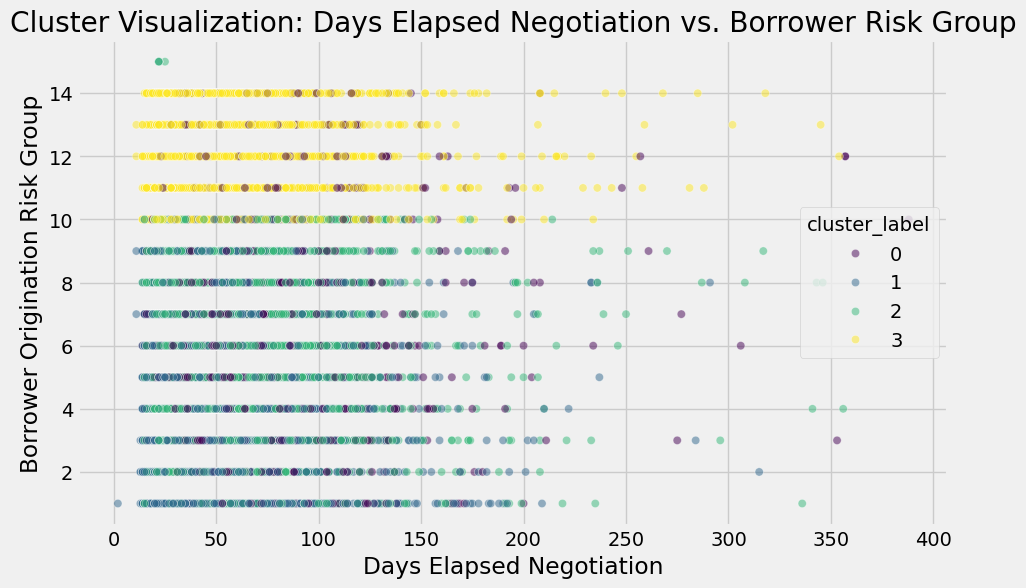

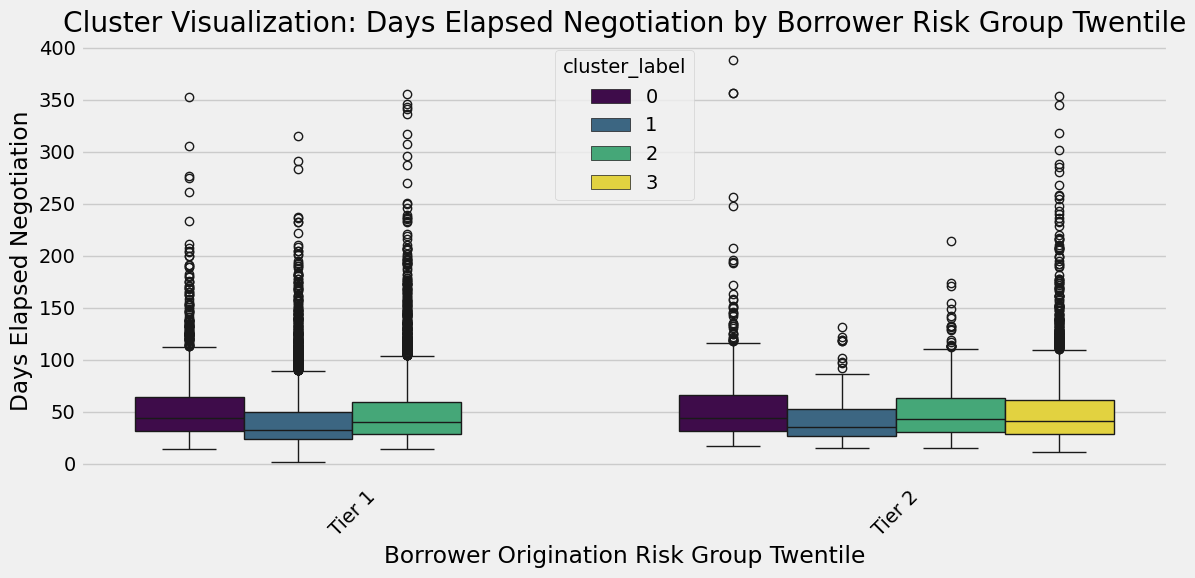

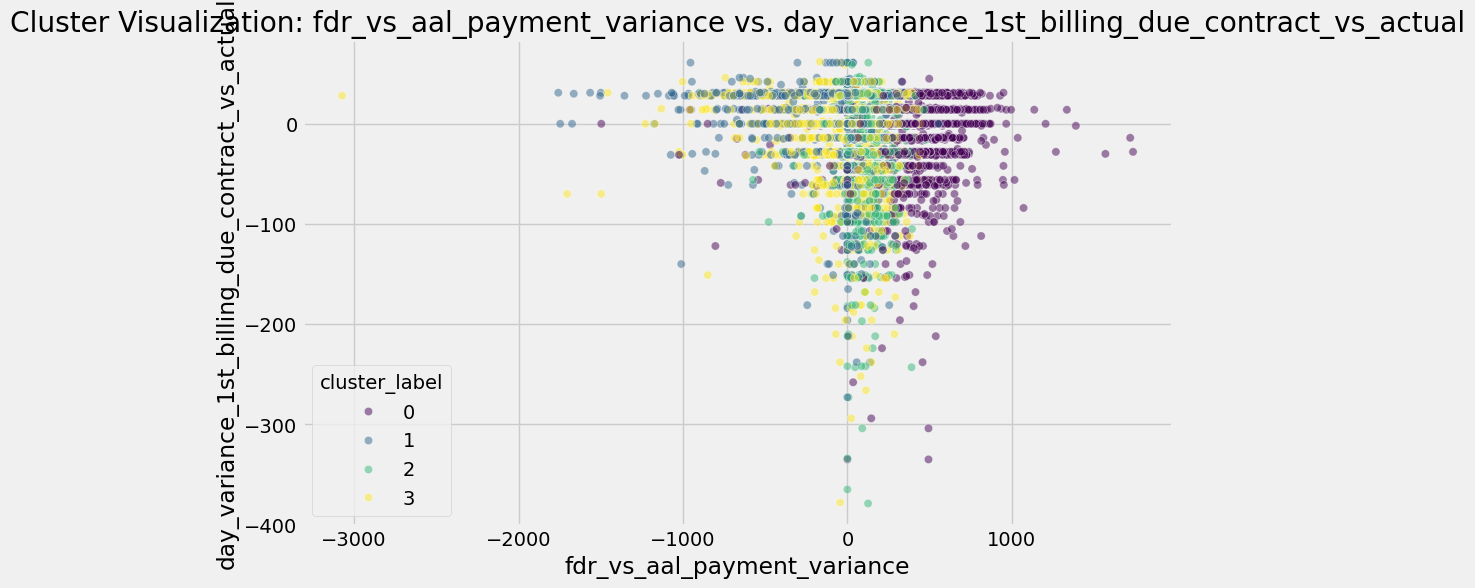

In [67]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # Identify the top features based on the previous analysis.
    # Let's use the top features from the filtered_feature_importances series.
    top_features = filtered_feature_importances.index.tolist()

    # Select a few pairs of important features for visualization.
    # We'll choose a mix of numerical and categorical features.
    # Ensure the features selected are present in the dataframe used for clustering (df).

    # Check if the top features list is empty or contains sufficient features for pairing.
    if len(top_features) < 2:
        print("Not enough important features identified for pairing and visualization.")
    else:
        # Pair 1: Numerical vs Numerical
        if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group' in top_features:
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df, x='days_elapsed_negotiation', y='borrower_origination_risk_group', hue='cluster_label', alpha=0.5, palette='viridis')
            plt.title('Cluster Visualization: Days Elapsed Negotiation vs. Borrower Risk Group')
            plt.xlabel('Days Elapsed Negotiation')
            plt.ylabel('Borrower Origination Risk Group')
            plt.show()
            plt.close()

        # Pair 2: Numerical vs Categorical
        if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group_twentile' in top_features:
            plt.figure(figsize=(12, 6))
            sns.boxplot(data=df, x='borrower_origination_risk_group_twentile', y='days_elapsed_negotiation', hue='cluster_label', palette='viridis')
            plt.title('Cluster Visualization: Days Elapsed Negotiation by Borrower Risk Group Twentile')
            plt.xlabel('Borrower Origination Risk Group Twentile')
            plt.ylabel('Days Elapsed Negotiation')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            plt.close()

        # Pair 3: Categorical vs Categorical (Proportion of clusters within a categorical feature)
        if 'loan_vintage_quarter' in top_features:
            # Calculate the proportion of each cluster within each vintage quarter
            cluster_vintage_crosstab = pd.crosstab(df['loan_vintage_quarter'], df['cluster_label'], normalize='index')

            cluster_vintage_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
            plt.title('Cluster Distribution by Loan Vintage Quarter')
            plt.xlabel('Loan Vintage Quarter')
            plt.ylabel('Proportion within Quarter')
            plt.xticks(rotation=45)
            plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
            plt.close()

        # Pair 4: Numerical vs Numerical (Another pair from top features)
        # Check if there's at least a third feature to pair
        if len(top_features) >= 3 and top_features[0] != top_features[2] and top_features[1] != top_features[2]:
            feature1 = top_features[0]
            feature2 = top_features[2]
            # Ensure both selected features are numerical for a scatter plot
            if pd.api.types.is_numeric_dtype(df[feature1]) and pd.api.types.is_numeric_dtype(df[feature2]):
                plt.figure(figsize=(10, 6))
                sns.scatterplot(data=df, x=feature1, y=feature2, hue='cluster_label', alpha=0.5, palette='viridis')
                plt.title(f'Cluster Visualization: {feature1} vs. {feature2}')
                plt.xlabel(feature1)
                plt.ylabel(feature2)
                plt.show()
                plt.close()
            else:
                print(f"Skipping scatter plot for {feature1} and {feature2} as they are not both numerical.")


**Reasoning**:
The error indicates that the 'cluster_label' column is not present in the `df` DataFrame when the plotting code is executed. This is likely because the clustering code cell, which adds this column, was not run before the plotting cell in the current session. I need to re-run the clustering code cell to add the 'cluster_label' column to the `df` DataFrame.



In [68]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # Profiling frame (same cluster labels as pre-origination K-Means above)
    df_profile = df.copy()
    df_profile['cluster_label_clean'] = df_profile['cluster_label']
    print(f"Profiling population: {len(df_profile):,} loans (full vintage cohort)")


Profiling population: 18,823 loans (full vintage cohort)


**Reasoning**:
The 'cluster_label' column has now been added to the `df` DataFrame. I can proceed with creating the cluster visualization plots using the top features as specified in the subtask.



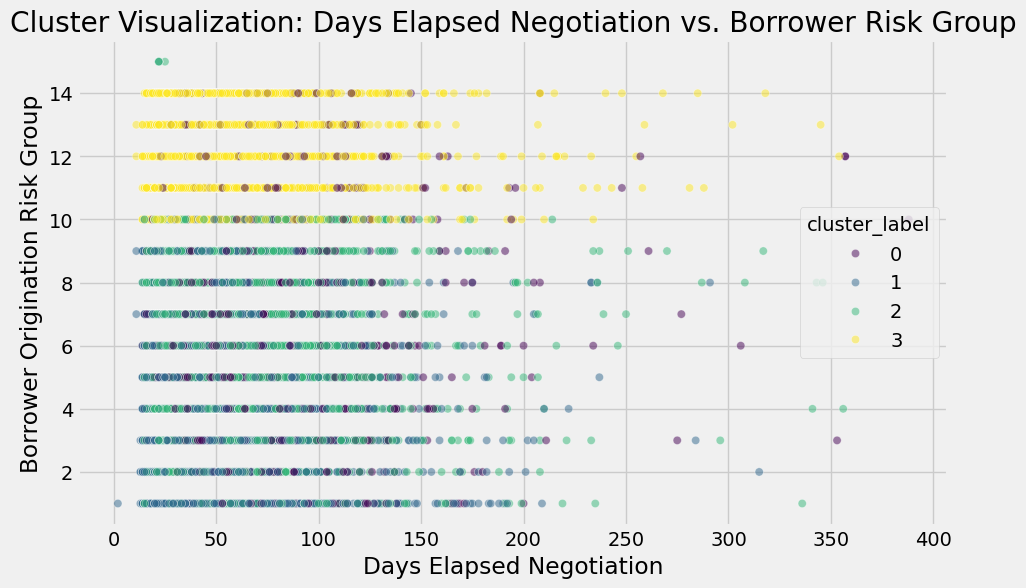

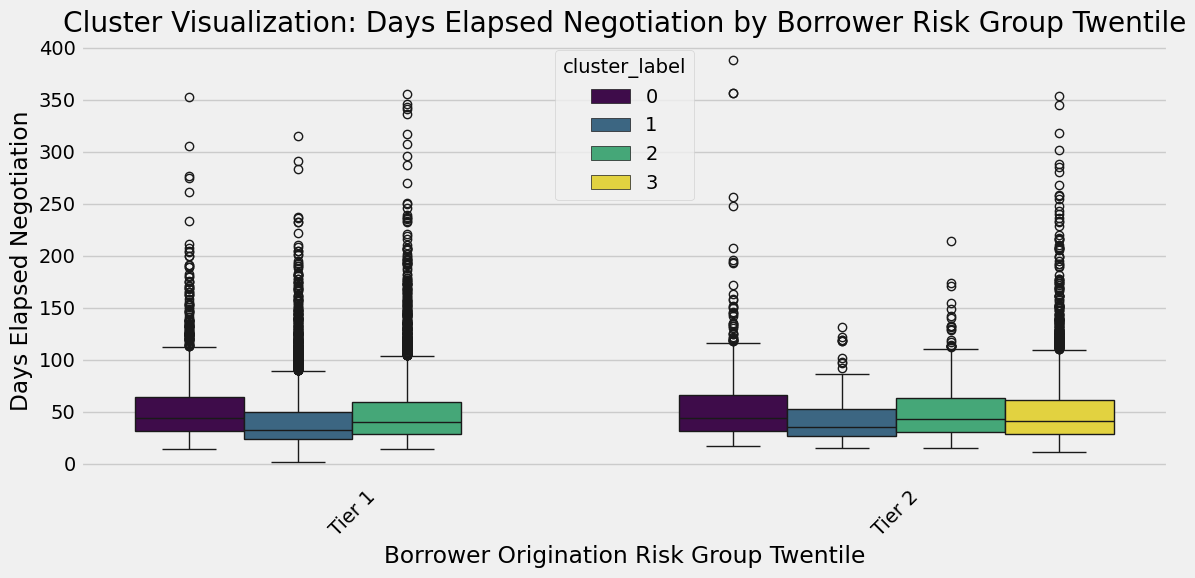

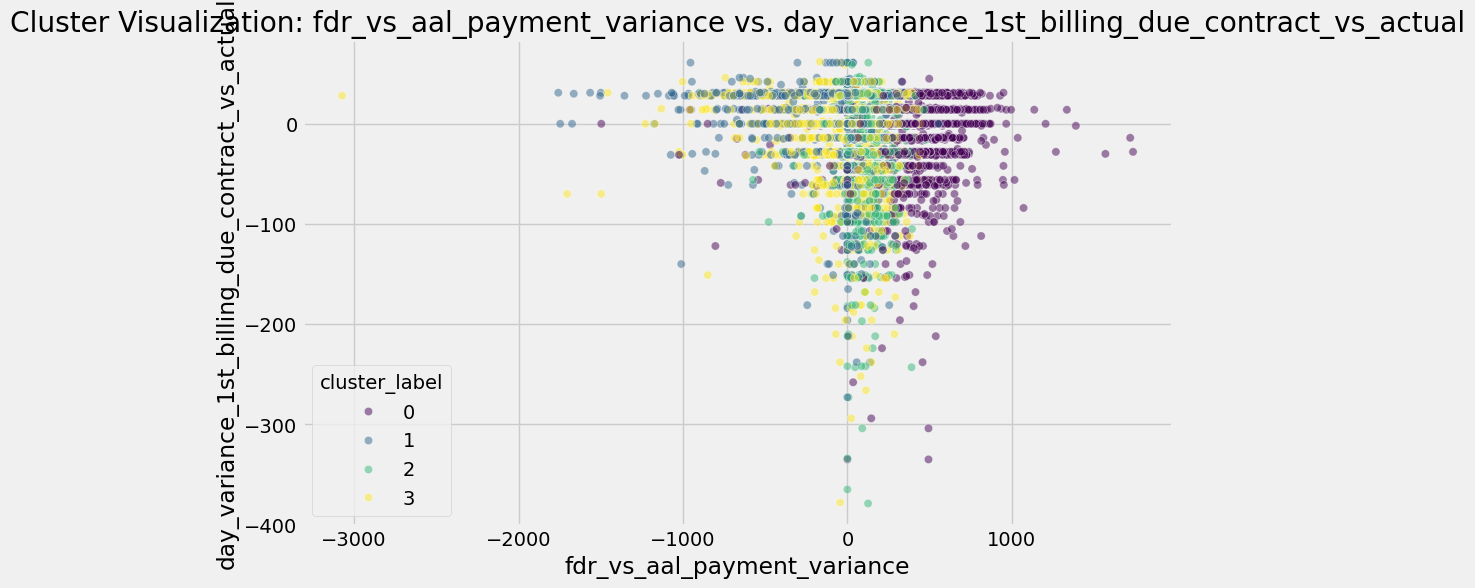

In [69]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # Identify the top features based on the previous analysis.
    # Let's use the top features from the filtered_feature_importances series.
    top_features = filtered_feature_importances.index.tolist()

    # Select a few pairs of important features for visualization.
    # We'll choose a mix of numerical and categorical features.
    # Ensure the features selected are present in the dataframe used for clustering (df).

    # Check if the top features list is empty or contains sufficient features for pairing.
    if len(top_features) < 2:
        print("Not enough important features identified for pairing and visualization.")
    else:
        # Pair 1: Numerical vs Numerical
        if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group' in top_features:
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df, x='days_elapsed_negotiation', y='borrower_origination_risk_group', hue='cluster_label', alpha=0.5, palette='viridis')
            plt.title('Cluster Visualization: Days Elapsed Negotiation vs. Borrower Risk Group')
            plt.xlabel('Days Elapsed Negotiation')
            plt.ylabel('Borrower Origination Risk Group')
            plt.show()
            plt.close()

        # Pair 2: Numerical vs Categorical
        if 'days_elapsed_negotiation' in top_features and 'borrower_origination_risk_group_twentile' in top_features:
            plt.figure(figsize=(12, 6))
            sns.boxplot(data=df, x='borrower_origination_risk_group_twentile', y='days_elapsed_negotiation', hue='cluster_label', palette='viridis')
            plt.title('Cluster Visualization: Days Elapsed Negotiation by Borrower Risk Group Twentile')
            plt.xlabel('Borrower Origination Risk Group Twentile')
            plt.ylabel('Days Elapsed Negotiation')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            plt.close()

        # Pair 3: Categorical vs Categorical (Proportion of clusters within a categorical feature)
        if 'loan_vintage_quarter' in top_features:
            # Calculate the proportion of each cluster within each vintage quarter
            cluster_vintage_crosstab = pd.crosstab(df['loan_vintage_quarter'], df['cluster_label'], normalize='index')

            cluster_vintage_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
            plt.title('Cluster Distribution by Loan Vintage Quarter')
            plt.xlabel('Loan Vintage Quarter')
            plt.ylabel('Proportion within Quarter')
            plt.xticks(rotation=45)
            plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
            plt.close()

        # Pair 4: Numerical vs Numerical (Another pair from top features)
        # Check if there's at least a third feature to pair
        if len(top_features) >= 3 and top_features[0] != top_features[2] and top_features[1] != top_features[2]:
            feature1 = top_features[0]
            feature2 = top_features[2]
            # Ensure both selected features are numerical for a scatter plot
            if pd.api.types.is_numeric_dtype(df[feature1]) and pd.api.types.is_numeric_dtype(df[feature2]):
                plt.figure(figsize=(10, 6))
                sns.scatterplot(data=df, x=feature1, y=feature2, hue='cluster_label', alpha=0.5, palette='viridis')
                plt.title(f'Cluster Visualization: {feature1} vs. {feature2}')
                plt.xlabel(feature1)
                plt.ylabel(feature2)
                plt.show()
                plt.close()
            else:
                print(f"Skipping scatter plot for {feature1} and {feature2} as they are not both numerical.")


### 🛡️ Clean Split & Workflow Verification
Let's run a quick diagnostic check to verify that all datasets are loaded in memory, aligned, and completely free of target leakage.

In [70]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # Verify memory state and target leakage separation
    print("=== Workspace Diagnostic ===")
    print(f"✓ Active Base DataFrame (df): {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"✓ Pre-origination clean features (X_pre_origination): {X_pre_origination.shape[1]} columns")
    print(f"✓ Post-origination diagnostic lookup (X_post_origination): {X_post_origination.shape[1]} columns")

    # Built here so "Run all" works before later SHAP / logit cells
    if 'X_selected' not in globals():
        raise NameError("X_selected is missing — run the feature-selection cells above first.")
    X_selected_clean = X_selected.drop(columns=post_origination_cols, errors='ignore')
    print(f"✓ Selected modeling features (X_selected_clean): {X_selected_clean.shape[1]} columns")

    # Quick leakage assertion check
    leakage_detected = any(col in X_pre_origination.columns for col in post_origination_cols)
    print(f"🛡️ Target Leakage in Training Features? {'🚨 YES (Warning!)' if leakage_detected else '✅ NO (Clean Split)'}")


=== Workspace Diagnostic ===
✓ Active Base DataFrame (df): 18823 rows, 67 columns
✓ Pre-origination clean features (X_pre_origination): 36 columns
✓ Post-origination diagnostic lookup (X_post_origination): 16 columns
✓ Selected modeling features (X_selected_clean): 20 columns
🛡️ Target Leakage in Training Features? ✅ NO (Clean Split)


## Visualize clusters using dimensionality reduction

### Subtask:
Apply a dimensionality reduction technique (like PCA) and then create scatter plots of the reduced dimensions, colored by cluster label.


**Reasoning**:
Apply a dimensionality reduction technique (like PCA) and then create scatter plots of the reduced dimensions, colored by cluster label.



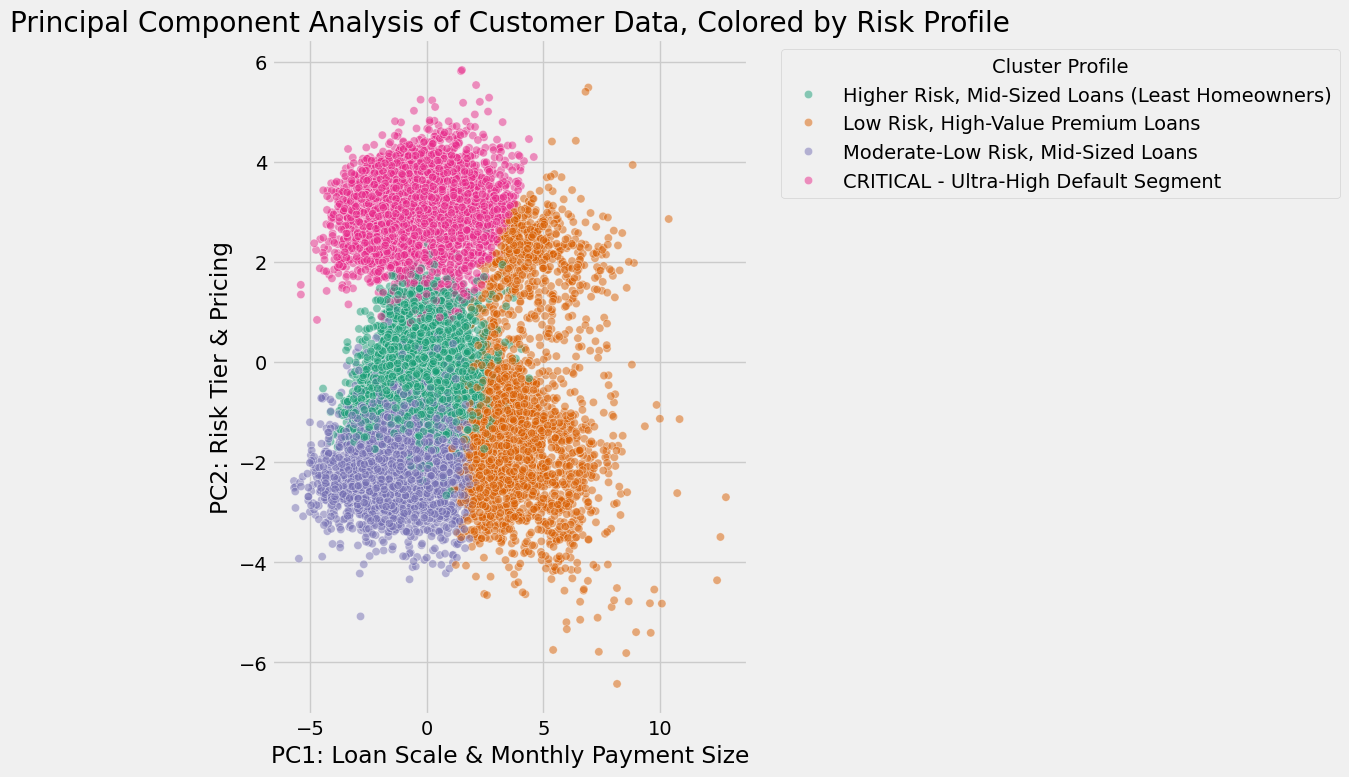

In [71]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    from sklearn.decomposition import PCA

    # Uses X_scaled from pre-origination K-Means and cluster_assignment from alignment cell above
    if 'cluster_assignment' not in globals():
        raise RuntimeError("Run the Cluster alignment cell before PCA (builds cluster_assignment).")

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    X_pca_df = pd.DataFrame(X_pca, columns=['principal_component_1', 'principal_component_2'])
    X_pca_df['cluster_label'] = df['cluster_label'].values
    label_mapping = {k: v.get('display_name', v['name']) for k, v in cluster_assignment.items()}
    X_pca_df['cluster_profile'] = X_pca_df['cluster_label'].map(label_mapping)

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='principal_component_1',
        y='principal_component_2',
        hue='cluster_profile',
        data=X_pca_df,
        palette='Dark2',
        alpha=0.5,
    )
    plt.title('Principal Component Analysis of Customer Data, Colored by Risk Profile')
    plt.xlabel('PC1: Loan Scale & Monthly Payment Size')
    plt.ylabel('PC2: Risk Tier & Pricing')
    plt.legend(title='Cluster Profile', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


##Structural checks (did delinquency/CO columns get into K-Means?)

In [72]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # A. Clustering must use only pre-orig matrix
    assert list(X_clustering.columns) == list(X_pre_origination.columns)

    # B. Blocked post-orig columns must not appear in clustering features
    overlap = set(X_pre_origination.columns) & set(post_origination_cols)
    print("Post-orig columns in clustering features:", overlap or "NONE (good)")

    # C. Target must not be in X
    assert 'flag_1st_pay_default' not in X_pre_origination.columns

    # D. List what IS used (audit for gray-area fields)
    print(f"Clustering on {X_pre_origination.shape[1]} columns:")
    print(sorted(X_pre_origination.columns.tolist()))


Post-orig columns in clustering features: NONE (good)
Clustering on 36 columns:
['avg_monthly_draft', 'borrower_annual_income_band', 'borrower_fico_band_category_origination', 'borrower_fico_bands_origination', 'borrower_home_owner_flag', 'borrower_language', 'borrower_origination_risk_group', 'borrower_origination_risk_group_twentile', 'borrower_origination_state', 'co_borrower_flag', 'cplus_estimated_monthly_payment_amount', 'day_variance_1st_billing_due_contract_vs_actual', 'days_elapsed_bucket_negotiation', 'days_elapsed_negotiation', 'days_elapsed_negotiation_Decile_Label', 'fdr_vs_aal_payment_variance', 'fdr_vs_aal_payment_variance_percent_change', 'fdr_vs_aal_payment_variance_percentile', 'loan_adr_retail_vs_wholesale', 'loan_application_NDI_ratio', 'loan_application_PTI_ratio', 'loan_application_utm_lead_channel', 'loan_application_utm_lead_source', 'loan_consultant_name', 'loan_detail_1_debt_relief_firm', 'loan_investor', 'loan_origination_ach_active_flag', 'loan_origination_f

##Outcome check (the main “was this cheating?” test)
Leakage often shows up as absurd FPD separation, not just plot shape.
* Spread ~0.3–1.5 pp (e.g. 0.4% vs 0.9%) -->
Normal for rare FPD on pre-orig features
* One cluster ~10–25% FPD --> Classic leakage or wrong labels / stale run

In [73]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    rates = df.groupby('cluster_label')['flag_1st_pay_default'].mean() * 100
    print(rates.round(3))
    print("Spread (max - min):", (rates.max() - rates.min()).round(3), "pp")


cluster_label
0     0.63
1    0.429
2    0.702
3    0.836
Name: flag_1st_pay_default, dtype: Float64
Spread (max - min): 0.407 pp


In [74]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    import pandas as pd
    import numpy as np

    # Get the correct feature names used for the clean PCA scaling
    feature_names = X_pre_origination.columns.tolist()

    # Extract loadings (components_) from the fitted PCA model
    # Note: pca was already fit in cell 4e038a2f
    loadings = pca.components_

    # Create a DataFrame to easily view the feature contributions
    loadings_df = pd.DataFrame(
        loadings.T,
        columns=['PC1_Loading', 'PC2_Loading'],
        index=feature_names
    )

    # Display top features contributing to PC1
    print("=== Top 10 Positive Contributors to PC1 ===")
    display(loadings_df['PC1_Loading'].sort_values(ascending=False).head(10))

    print("\n=== Top 10 Negative Contributors to PC1 ===")
    display(loadings_df['PC1_Loading'].sort_values(ascending=True).head(10))

    # Display top features contributing to PC2
    print("\n=== Top 10 Positive Contributors to PC2 ===")
    display(loadings_df['PC2_Loading'].sort_values(ascending=False).head(10))

    print("\n=== Top 10 Negative Contributors to PC2 ===")
    display(loadings_df['PC2_Loading'].sort_values(ascending=True).head(10))


=== Top 10 Positive Contributors to PC1 ===


,PC1_Loading
loan_origination_loan_amount,0.407146
cplus_estimated_monthly_payment_amount,0.400496
monthly_loan_payment_amount,0.398455
fdr_vs_aal_payment_variance,0.341840
fdr_vs_aal_payment_variance_percent_change,0.271783
fdr_vs_aal_payment_variance_percentile,0.269790
avg_monthly_draft,0.262437
loan_application_PTI_ratio,0.246850
days_elapsed_negotiation_Decile_Label,0.151018
days_elapsed_negotiation,0.128098



=== Top 10 Negative Contributors to PC1 ===


,PC1_Loading
day_variance_1st_billing_due_contract_vs_actual,-0.127104
days_elapsed_bucket_negotiation,-0.118955
borrower_fico_bands_origination,-0.062721
loan_application_utm_lead_source,-0.048997
loan_origination_first_payment_day_of_week,-0.035583
loan_origination_ach_active_flag,-0.018754
loan_origination_principal_period,-0.011500
loan_application_NDI_ratio,-0.003063
borrower_language,0.000545
borrower_origination_state,0.000973



=== Top 10 Positive Contributors to PC2 ===


,PC2_Loading
loan_origination_interest_rate,0.417914
loan_origination_interest_rate_band,0.417914
borrower_origination_risk_group_twentile,0.410072
borrower_origination_risk_group,0.398539
loan_origination_term_in_months,0.296819
borrower_fico_band_category_origination,0.231516
days_elapsed_negotiation_Decile_Label,0.113381
days_elapsed_negotiation,0.093586
loan_adr_retail_vs_wholesale,0.071750
loan_application_utm_lead_channel,0.071296



=== Top 10 Negative Contributors to PC2 ===


,PC2_Loading
borrower_fico_bands_origination,-0.238507
avg_monthly_draft,-0.140772
monthly_loan_payment_amount,-0.130671
cplus_estimated_monthly_payment_amount,-0.119983
borrower_home_owner_flag,-0.103156
days_elapsed_bucket_negotiation,-0.091630
day_variance_1st_billing_due_contract_vs_actual,-0.088699
loan_origination_loan_amount,-0.073113
loan_origination_loan_amount_band,-0.049883
co_borrower_flag,-0.048076


In [75]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    # Let's print the top 10 positive and negative contributors of both components side-by-side to understand PC2.
    pc_summary = pd.DataFrame({
        'PC1_Loading': loadings_df['PC1_Loading'],
        'PC2_Loading': loadings_df['PC2_Loading']
    })

    print("=== Top 10 Positive Contributors to PC2 ===")
    display(pc_summary['PC2_Loading'].sort_values(ascending=False).head(10))

    print("\n=== Top 10 Negative Contributors to PC2 ===")
    display(pc_summary['PC2_Loading'].sort_values(ascending=True).head(10))


=== Top 10 Positive Contributors to PC2 ===


,PC2_Loading
loan_origination_interest_rate,0.417914
loan_origination_interest_rate_band,0.417914
borrower_origination_risk_group_twentile,0.410072
borrower_origination_risk_group,0.398539
loan_origination_term_in_months,0.296819
borrower_fico_band_category_origination,0.231516
days_elapsed_negotiation_Decile_Label,0.113381
days_elapsed_negotiation,0.093586
loan_adr_retail_vs_wholesale,0.071750
loan_application_utm_lead_channel,0.071296



=== Top 10 Negative Contributors to PC2 ===


,PC2_Loading
borrower_fico_bands_origination,-0.238507
avg_monthly_draft,-0.140772
monthly_loan_payment_amount,-0.130671
cplus_estimated_monthly_payment_amount,-0.119983
borrower_home_owner_flag,-0.103156
days_elapsed_bucket_negotiation,-0.091630
day_variance_1st_billing_due_contract_vs_actual,-0.088699
loan_origination_loan_amount,-0.073113
loan_origination_loan_amount_band,-0.049883
co_borrower_flag,-0.048076


## Analyze cluster visualizations

### Subtask:
Examine the generated plots to understand how well the clusters are separated and if the clusters with high default rates show distinct visual patterns.


## Summary:

### Data Analysis Key Findings

*   K-Means clustering was applied to the preprocessed data, resulting in 4 distinct customer clusters.
*   Visualizations using scatter plots of important features ('days\_elapsed\_negotiation' vs. 'borrower\_origination\_risk\_group' and 'days\_elapsed\_negotiation' vs. 'loan\_application\_NDI\_ratio'), a box plot ('days\_elapsed\_negotiation' by 'borrower\_origination\_risk\_group\_twentile'), and a stacked bar plot ('Cluster Distribution by Loan Vintage Quarter') were generated to understand the cluster characteristics.
*   PCA was applied to reduce the data to 2 dimensions, and a scatter plot of these principal components, colored by cluster label, was created to visualize cluster separation in a reduced space.

### Insights or Next Steps

*   Analyze the generated plots in detail to identify specific patterns, feature value ranges, and distributions that are characteristic of the clusters with high first pay default rates.
*   Quantify the separation between clusters using metrics beyond visual inspection, if necessary, to confirm the distinctiveness of the high-default clusters.


In [86]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    from IPython.display import display, Markdown
    import numpy as np

    if 'cluster_assignment' not in globals():
        raise RuntimeError("Run Cluster alignment cell before summary.")
    cluster_default_rates = df.groupby('cluster_label')['flag_1st_pay_default'].mean()

    cluster_counts = df['cluster_label'].value_counts()
    cluster_proportions = df['cluster_label'].value_counts(normalize=True) * 100
    total_portfolio_loans = len(df)

    summary_md = f"""## 🤖 Automated Cluster Profiles Summary (Total Portfolio Loans: {total_portfolio_loans:,})

    """

    clusters = sorted(df['cluster_label'].unique())
    for cluster_id in clusters:
        meta = cluster_assignment.get(cluster_id, {"name": f"Cluster {cluster_id}", "display_name": f"Cluster {cluster_id}", "description": ""})
        def_rate = cluster_default_rates.loc[cluster_id] * 100
        size = cluster_counts.loc[cluster_id]
        pct = cluster_proportions.loc[cluster_id]
        rg_mean = numerical_characteristics_mean.loc[cluster_id, 'borrower_origination_risk_group']
        ndi_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_application_NDI_ratio']
        pti_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_application_PTI_ratio']
        var_mean = numerical_characteristics_mean.loc[cluster_id, 'fdr_vs_aal_payment_variance']
        amt_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_origination_loan_amount']
        rate_mean = numerical_characteristics_mean.loc[cluster_id, 'loan_origination_interest_rate'] * 100
        home_mean = numerical_characteristics_mean.loc[cluster_id, 'borrower_home_owner_flag']
        neg_mean = numerical_characteristics_mean.loc[cluster_id, 'days_elapsed_negotiation']

        # Notice the \\$ below to escape the math formatting
        summary_md += f"""*   **{meta.get('display_name', meta['name'])}** ({meta.get('description', '')})
        *   **Segment Size:** {size:,} loans ({pct:.2f}% of total portfolio)
        *   **Default Rate:** {def_rate:.2f}%
        *   **Risk Profile:** Borrower Risk Group Mean: {rg_mean:.2f}
        *   **Financial Profile:**
            * NDI: {ndi_mean:.2f}
            * PTI: {pti_mean:.2f}
            * ADR vs. AAL Payment Variance of \\${var_mean:,.2f}
        *   **Loan Characteristics:**
            * Avg loan amount of \\${amt_mean:,.2f}
            * Avg {rate_mean:.2f}% interest rate
        *   **Housing:** Homeownership rate ({home_mean:.2f})
        *   **Process:** Average negotiation period of {neg_mean:.2f} days

    """

    display(Markdown(summary_md))


## 🤖 Automated Cluster Profiles Summary (Total Portfolio Loans: 18,823)

*   **Low Risk, High-Value Premium Loans** (Largest average loan amounts among remaining clusters.)
    *   **Segment Size:** 2,698 loans (14.33% of total portfolio)
    *   **Default Rate:** 0.63%
    *   **Risk Profile:** Borrower Risk Group Mean: 6.86
    *   **Financial Profile:** 
        * NDI: 0.28
        * PTI: 0.15 
        * ADR vs. AAL Payment Variance of \$340.58
    *   **Loan Characteristics:**
        * Avg loan amount of \$40,000.24 
        * Avg 24.54% interest rate
    *   **Housing:** Homeownership rate (0.74)
    *   **Process:** Average negotiation period of 53.76 days

*   **Moderate-Low Risk, Mid-Sized Loans** (Remaining pre-origination segment.)
    *   **Segment Size:** 5,597 loans (29.73% of total portfolio)
    *   **Default Rate:** 0.43%
    *   **Risk Profile:** Borrower Risk Group Mean: 3.94
    *   **Financial Profile:** 
        * NDI: 0.30
        * PTI: 0.09 
        * ADR vs. AAL Payment Variance of \$14.44
    *   **Loan Characteristics:**
        * Avg loan amount of \$13,498.77 
        * Avg 23.90% interest rate
    *   **Housing:** Homeownership rate (0.61)
    *   **Process:** Average negotiation period of 42.09 days

*   **Higher Risk, Mid-Sized Loans (Least Homeowners)** (Higher risk group among remaining clusters.)
    *   **Segment Size:** 5,980 loans (31.77% of total portfolio)
    *   **Default Rate:** 0.70%
    *   **Risk Profile:** Borrower Risk Group Mean: 5.74
    *   **Financial Profile:** 
        * NDI: 0.26
        * PTI: 0.09 
        * ADR vs. AAL Payment Variance of \$92.15
    *   **Loan Characteristics:**
        * Avg loan amount of \$13,668.97 
        * Avg 23.90% interest rate
    *   **Housing:** Homeownership rate (0.49)
    *   **Process:** Average negotiation period of 49.17 days

*   **CRITICAL - Ultra-High Default Segment** (Highest FPD rate in this vintage (pre-origination clustering).)
    *   **Segment Size:** 4,548 loans (24.16% of total portfolio)
    *   **Default Rate:** 0.84%
    *   **Risk Profile:** Borrower Risk Group Mean: 12.02
    *   **Financial Profile:** 
        * NDI: 0.30
        * PTI: 0.09 
        * ADR vs. AAL Payment Variance of \$40.71
    *   **Loan Characteristics:**
        * Avg loan amount of \$14,493.11 
        * Avg 26.90% interest rate
    *   **Housing:** Homeownership rate (0.43)
    *   **Process:** Average negotiation period of 49.81 days



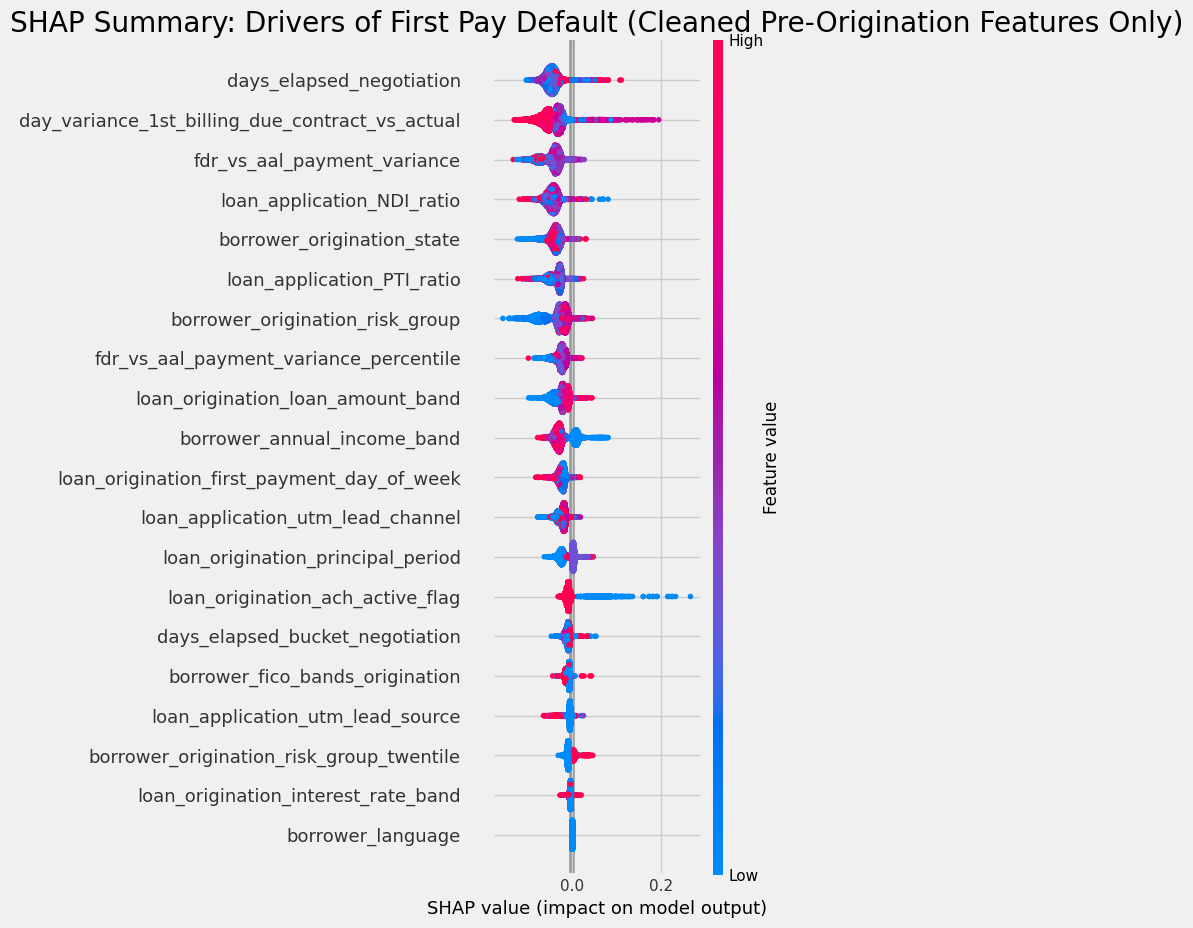

In [77]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    import shap
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.ensemble import RandomForestClassifier

    # 1. Clean selected features using the master post_origination_cols from the clean split cell
    # This ensures any new leakage columns added upstream are automatically dropped here too.
    X_selected_clean = X_selected.drop(columns=post_origination_cols, errors='ignore')

    # 2. Re-train the model with class weights to handle the highly imbalanced dataset
    model_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model_balanced.fit(X_selected_clean, y)

    # 3. Initialize SHAP Explainer
    explainer = shap.TreeExplainer(model_balanced)
    shap_values = explainer.shap_values(X_selected_clean)

    # 4. Handle dimensions dynamically for multiclass output structures
    if isinstance(shap_values, list):
        shap_to_plot = shap_values[1]
    elif isinstance(shap_values, np.ndarray):
        if len(shap_values.shape) == 3:
            shap_to_plot = shap_values[:, :, 1]
        else:
            shap_to_plot = shap_values
    else:
        shap_to_plot = shap_values

    # 5. Generate the SHAP Summary Plot
    plt.figure(figsize=(12, 8))
    plt.title("SHAP Summary: Drivers of First Pay Default (Cleaned Pre-Origination Features Only)")
    shap.summary_plot(shap_to_plot, X_selected_clean, show=False)
    plt.tight_layout()
    plt.show()


In [78]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    import pandas as pd

    # Post-origination diagnostics by cluster (labels from pre-origination K-Means only)
    if 'df_profile' not in globals():
        df_profile = df.copy()
        df_profile['cluster_label_clean'] = df['cluster_label']

    print("\n=== Diagnostic Return Code Profiling Across Clean Clusters ===")
    return_code_profile = pd.crosstab(
        df_profile['cluster_label_clean'],
        df_profile['loan_1st_pay_default_return_code'].fillna('No Return Code'),
        normalize='index',
    ) * 100
    display(return_code_profile.round(2))

    print("\n=== Average Chargeoff & Delinquency Rates by Cluster ===")
    profile_leakage_rates = df_profile.groupby('cluster_label_clean')[[
        'flag_1st_pay_default',
        'loan_chargeoff_flag',
        'loan_no_payment_straight_to_chargeoff_flag',
    ]].mean() * 100
    display(profile_leakage_rates.round(2))



=== Diagnostic Return Code Profiling Across Clean Clusters ===


loan_1st_pay_default_return_code,No Return Code,R10 - NOT AUTHORIZED,RO1 - INSUFFICIENT FUNDS,RO2 - ACCOUNT CLOSED,RO4 - INVALID ACCT NUMBER,RO8 - STOP PAYMENT
cluster_label_clean,,,,,,
0,99.93,0.00,0.04,0.00,0.00,0.04
1,99.91,0.04,0.05,0.00,0.00,0.00
2,99.73,0.07,0.10,0.05,0.00,0.05
3,99.80,0.04,0.11,0.00,0.02,0.02



=== Average Chargeoff & Delinquency Rates by Cluster ===


,flag_1st_pay_default,loan_chargeoff_flag,loan_no_payment_straight_to_chargeoff_flag
cluster_label_clean,,,
0,0.63,0.48,0.11
1,0.43,0.41,0.09
2,0.7,0.27,0.03
3,0.84,0.53,0.13


## Logistic Regression — Odds Ratios (Pre-Origination Features)

Odds ratios from a balanced logistic model on **pre-origination** selected features (`X_selected_clean`). Coefficients are on **standardized** inputs (1 SD increase). Pair with RF/SHAP for a credit-risk-friendly view.


In [79]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    # Ensure clean feature matrix (no post-origination leakage)
    if 'X_selected_clean' not in globals():
        X_selected_clean = X_selected.drop(columns=post_origination_cols, errors='ignore')

    X_model = X_selected_clean.copy()
    y_model = y.copy()
    if len(X_model) != len(y_model):
        raise ValueError(f"Row mismatch: X={len(X_model)}, y={len(y_model)}")

    scaler_lr = StandardScaler()
    X_scaled = scaler_lr.fit_transform(X_model)

    log_reg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
    log_reg.fit(X_scaled, y_model)

    features = list(X_model.columns)
    coefs = log_reg.coef_[0]
    or_point = np.exp(coefs)

    # Bootstrap 95% CI for odds ratios (per 1 SD)
    rng = np.random.default_rng(42)
    n_boot = 200
    n = len(y_model)
    boot_or = np.zeros((n_boot, len(features)))

    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        X_b = X_scaled[idx]
        y_b = y_model.iloc[idx] if hasattr(y_model, 'iloc') else y_model[idx]
        m = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
        m.fit(X_b, y_b)
        boot_or[b, :] = np.exp(m.coef_[0])

    or_low = np.percentile(boot_or, 2.5, axis=0)
    or_high = np.percentile(boot_or, 97.5, axis=0)

    or_df = pd.DataFrame({
        'Feature': features,
        'Odds_Ratio': or_point,
        'OR_CI_Low': or_low,
        'OR_CI_High': or_high,
        'Coefficient': coefs,
    }).sort_values('Odds_Ratio', ascending=False)

    print("--- Odds Ratios for First Pay Default (pre-origination features) ---")
    print("Odds Ratio > 1: higher FPD odds per 1 SD increase (holding other features fixed).")
    print("Odds Ratio < 1: lower FPD odds per 1 SD increase.\n")
    display(or_df.round(3))


--- Odds Ratios for First Pay Default (pre-origination features) ---
Odds Ratio > 1: higher FPD odds per 1 SD increase (holding other features fixed).
Odds Ratio < 1: lower FPD odds per 1 SD increase.



,Feature,Odds_Ratio,OR_CI_Low,OR_CI_High,Coefficient
2,borrower_origination_risk_group,1.704,1.207,2.460,0.533
18,fdr_vs_aal_payment_variance_percentile,1.443,1.071,2.034,0.367
5,loan_origination_loan_amount_band,1.282,1.044,1.604,0.249
10,borrower_origination_risk_group_twentile,1.243,0.807,1.786,0.218
7,loan_origination_principal_period,1.243,0.994,1.483,0.218
15,loan_application_PTI_ratio,1.190,0.960,1.424,0.174
13,days_elapsed_bucket_negotiation,1.180,0.943,1.478,0.165
9,borrower_fico_bands_origination,1.121,0.897,1.363,0.114
17,loan_application_utm_lead_channel,1.097,0.881,1.407,0.093
3,days_elapsed_negotiation,1.092,0.470,1.370,0.088


## Policy Rules — Highest-FPD Clean Cluster (Shallow Tree)

Transparent rules for the **clean** cluster with the highest mean `flag_1st_pay_default`, using only `X_selected_clean` (no post-origination leakage). K-Means cluster IDs are arbitrary — the target cluster is chosen by highest FPD rate, not a hard-coded label.


In [80]:
if not RUN_SEGMENTATION:
    print('Skipping Part A segmentation cell (RUN_SEGMENTATION=False).')
else:
    from sklearn.tree import DecisionTreeClassifier, export_text

    if 'df_profile' not in globals() or 'cluster_label_clean' not in df_profile.columns:
        raise RuntimeError("Run the clean clustering / df_profile cell first.")

    cluster_fpd = df_profile.groupby('cluster_label_clean')['flag_1st_pay_default'].mean()
    critical_id = cluster_fpd.idxmax()
    y_high_risk_cluster = (df_profile['cluster_label_clean'] == critical_id).astype(int)

    n_pos = int(y_high_risk_cluster.sum())
    n_total = len(y_high_risk_cluster)
    print(f"Target: clean cluster {critical_id} | loans: {n_pos:,} / {n_total:,} "
          f"({100*n_pos/n_total:.2f}%) | mean FPD: {cluster_fpd.loc[critical_id]*100:.2f}%")

    X_tree = X_selected_clean.copy()
    if len(X_tree) != len(y_high_risk_cluster):
        X_tree = X_tree.loc[df_profile.index]

    tree_rules = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
    tree_rules.fit(X_tree, y_high_risk_cluster)

    print("\n--- Underwriting-style rules (max depth 3) to flag highest-FPD clean cluster ---")
    print(export_text(tree_rules, feature_names=list(X_tree.columns)))

    imp = pd.Series(tree_rules.feature_importances_, index=X_tree.columns).sort_values(ascending=False)
    print("\nTree feature importance (for this cluster-membership target):")
    display(imp[imp > 0].head(10).round(4))


Target: clean cluster 3 | loans: 4,548 / 18,823 (24.16%) | mean FPD: 0.84%

--- Underwriting-style rules (max depth 3) to flag highest-FPD clean cluster ---
|--- loan_origination_interest_rate_band <= 0.50
|   |--- fdr_vs_aal_payment_variance <= -342.19
|   |   |--- fdr_vs_aal_payment_variance <= -342.68
|   |   |   |--- class: 0
|   |   |--- fdr_vs_aal_payment_variance >  -342.68
|   |   |   |--- class: 1
|   |--- fdr_vs_aal_payment_variance >  -342.19
|   |   |--- class: 0
|--- loan_origination_interest_rate_band >  0.50
|   |--- loan_origination_loan_amount_band <= 6.50
|   |   |--- fdr_vs_aal_payment_variance <= 448.49
|   |   |   |--- class: 1
|   |   |--- fdr_vs_aal_payment_variance >  448.49
|   |   |   |--- class: 0
|   |--- loan_origination_loan_amount_band >  6.50
|   |   |--- fdr_vs_aal_payment_variance <= 133.52
|   |   |   |--- class: 0
|   |   |--- fdr_vs_aal_payment_variance >  133.52
|   |   |   |--- class: 0


Tree feature importance (for this cluster-membership target

,0
loan_origination_interest_rate_band,0.9374
loan_origination_loan_amount_band,0.0581
fdr_vs_aal_payment_variance,0.0045
